# HEART DISEASE PREDICTOR

#### `OWNER - LOVEPREET SINGH`


## Import Libraries

In [337]:
import missingno as msno
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from math import sqrt
from numpy import argmax

# Scikit-learn imports
from sklearn.model_selection import (
    KFold, 
    StratifiedKFold, 
    cross_val_score, 
    train_test_split, 
    GridSearchCV
)
from sklearn.svm import SVR, SVC
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import (
    OneHotEncoder, 
    OrdinalEncoder, 
    StandardScaler, 
    PolynomialFeatures, 
    FunctionTransformer
)
# First, enable the experimental IterativeImputer
from sklearn.experimental import enable_iterative_imputer  

from sklearn.impute import (
    SimpleImputer, 
    KNNImputer, 
    MissingIndicator, 
    IterativeImputer
)
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.metrics import (
    roc_curve, 
    accuracy_score, 
    confusion_matrix, 
    classification_report
)

# Category encoders
from category_encoders import BinaryEncoder
from xgboost import XGBClassifier

from sklearn.base import BaseEstimator, ClassifierMixin
import pickle
from scipy.stats import mode

import optuna
from optuna.samplers import TPESampler

### Load Dataset

#### DATASET USED
##### The dataset contains information of 920 patients with 14 features The dataset used contains medical records of 920 patients, each described by 14 features, with the primary goal of predicting the presence of heart disease. The features capture a mix of demographic details (such as age and sex), clinical measurements (including resting blood pressure, serum cholesterol, maximum heart rate achieved, fasting blood sugar, and ST depression), and electrocardiographic results (like chest pain type, resting ECG, and exercise-induced angina). Additionally, it includes angiographic and exercise-related factors such as the number of major vessels colored by fluoroscopy and slope of the ST segment. The target variable indicates the presence (1) or absence (0) of heart disease, making the dataset suitable for binary classification tasks in machine learning.

In [2]:
df = pd.read_csv(r"D:\Downloads\heart_disease_uci_updated.csv")
df

,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,1
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
915,916,54,Female,VA Long Beach,asymptomatic,127.0,333.0,True,st-t abnormality,154.0,False,0.0,NaN,NaN,NaN,1
916,917,62,Male,VA Long Beach,typical angina,NaN,139.0,False,st-t abnormality,NaN,NaN,NaN,NaN,NaN,NaN,0
917,918,55,Male,VA Long Beach,asymptomatic,122.0,223.0,True,st-t abnormality,100.0,False,0.0,NaN,NaN,fixed defect,1
918,919,58,Male,VA Long Beach,asymptomatic,NaN,385.0,True,lv hypertrophy,NaN,NaN,NaN,NaN,NaN,NaN,0


In [3]:

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 16 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        920 non-null    int64  
 1   age       920 non-null    int64  
 2   sex       920 non-null    object 
 3   dataset   920 non-null    object 
 4   cp        920 non-null    object 
 5   trestbps  861 non-null    float64
 6   chol      890 non-null    float64
 7   fbs       830 non-null    object 
 8   restecg   918 non-null    object 
 9   thalch    865 non-null    float64
 10  exang     865 non-null    object 
 11  oldpeak   858 non-null    float64
 12  slope     611 non-null    object 
 13  ca        309 non-null    float64
 14  thal      434 non-null    object 
 15  num       920 non-null    int64  
dtypes: float64(5), int64(3), object(8)
memory usage: 115.1+ KB


## Heart Disease Dataset: Feature Descriptions 


### 1. ID
The unique identifier assigned to each patient record. This column does not carry clinical meaning but is essential for record-keeping, referencing, or merging datasets in analysis.

### 2. Age
Age represents the patient's years of life. As individuals age, several physiological changes occur that increase cardiovascular risk: arteries become less elastic and stiffen, atherosclerotic plaques accumulate in vessel walls, and the heart muscle gradually weakens. These age-related changes significantly increase susceptibility to coronary artery disease, hypertension, and diabetes mellitus.  

**Clinical Significance:** Heart disease prevalence rises dramatically after age 45 in men and 55 in women. Younger patients (30–40s) presenting with heart disease often have genetic predispositions or severe lifestyle-related risk factors, while older patients (50+) are primarily affected by cumulative age-related vascular deterioration.

### 3. Sex
Biological sex (encoded as 0 = male, 1 = female) significantly influences both heart disease risk patterns and symptom presentation. Men typically develop cardiovascular disease at earlier ages, while women often develop it later in life, particularly after menopause due to the protective effects of estrogen being lost.  

**Clinical Significance:** Women may present with atypical symptoms such as fatigue, shortness of breath, or nausea instead of the classic substernal chest pain commonly seen in men. This difference in presentation can lead to delayed diagnosis and treatment in female patients.

## 4. Dataset
Indicates the origin of the patient record, as this heart disease dataset is a combination of multiple resources (e.g., Cleveland, Hungarian, Switzerland, and Long Beach datasets).


### 5. Chest Pain Type (cp)
This categorical variable classifies chest pain into four distinct types:  
- 0 = Typical angina: classic chest pain with characteristic substernal location, precipitated by exertion, relieved by rest  
- 1 = Atypical angina: chest pain missing one of the typical angina characteristics  
- 2 = Non-anginal pain: chest pain with fewer than two typical angina characteristics  
- 3 = Asymptomatic: no chest pain symptoms  

**Clinical Significance:** Typical angina (cp = 0) strongly indicates coronary artery blockage and warrants immediate investigation. Paradoxically, asymptomatic patients (cp = 3) can be particularly dangerous as they may harbor significant coronary disease without warning symptoms.

### 6. Resting Blood Pressure (trestbps)
Resting systolic blood pressure measured in mmHg represents the force exerted by blood against arterial walls when the heart contracts. Chronic hypertension damages arterial walls, forces the heart to work harder, and leads to left ventricular hypertrophy.  

**Clinical Classifications:**  
- Normal: <120 mmHg  
- Prehypertension: 120–139 mmHg  
- Hypertension: ≥140 mmHg  

**Clinical Significance:** Chronic elevated blood pressure is a major modifiable risk factor contributing to heart disease, stroke, and kidney dysfunction.

### 7. Serum Cholesterol (chol)
Total serum cholesterol measured in mg/dL reflects the concentration of lipids circulating in the bloodstream. Elevated cholesterol levels contribute to atherosclerotic plaque formation in arterial walls, progressively narrowing vessels and reducing blood flow to vital organs.  

**Clinical Classifications:**  
- Desirable: <200 mg/dL  
- Borderline high: 200–239 mg/dL  
- High: ≥240 mg/dL  

**Clinical Significance:** Hypercholesterolemia accelerates atherosclerosis, increasing the risk of angina, myocardial infarction, and sudden cardiac death.

### 8. Fasting Blood Sugar (fbs)
This binary indicator specifies whether fasting blood glucose exceeds 120 mg/dL (1 = yes, 0 = no). Elevated fasting glucose suggests impaired glucose tolerance or diabetes mellitus, conditions that cause widespread vascular damage through glycation of proteins and accelerated atherosclerosis.  

**Clinical Significance:** Diabetes doubles to triples cardiovascular disease risk. Patients with fbs = 1 represent a high-risk population requiring intensive cardiovascular monitoring and management.

### 9. Resting ECG Results (restecg)
Resting ECG findings are categorized into three groups:  
- 0 = Normal: no significant abnormalities detected  
- 1 = ST-T wave abnormality: indicates myocardial ischemia, previous infarction, or electrolyte imbalances  
- 2 = Left ventricular hypertrophy: suggests chronic pressure or volume overload  

**Clinical Significance:** Abnormal ECG findings (values 1 or 2) indicate existing cardiac pathology and correlate with higher likelihood of significant coronary artery disease.

### 10. Maximum Heart Rate Achieved (thalach)
This measures the maximum heart rate attained during exercise stress testing. A healthy cardiovascular system should achieve approximately 85% of the predicted maximum heart rate (calculated as 220 minus age).  

**Clinical Significance:** Failure to achieve an adequate heart rate response (chronotropic incompetence) may indicate poor cardiac output, significant coronary artery disease, or medication effects. Higher maximum heart rates generally reflect better cardiovascular fitness and cardiac reserve.

### 10. Exercise-Induced Angina (exang)
This binary variable indicates whether chest pain occurs during exercise (1 = yes, 0 = no). Exercise-induced angina represents the clinical manifestation of a supply-demand mismatch, where myocardial oxygen demand exceeds supply through narrowed coronary arteries.  

**Clinical Significance:** The presence of exang (value = 1) is a strong predictor of significant coronary artery disease and indicates high cardiovascular risk requiring further evaluation and intervention.

### 11. ST Segment Depression (oldpeak)
ST segment depression is measured in millimeters during exercise stress testing compared to rest. The ST segment represents the interval between ventricular depolarization and repolarization on the ECG.  

**Clinical Interpretations:**  
- 0.0 mm: Normal response  
- ≥1.0 mm: Concerning for myocardial ischemia  
- ≥2.0 mm: Strongly abnormal, highly suggestive of significant coronary disease  

**Clinical Significance:** Greater ST depression indicates more severe myocardial oxygen supply-demand imbalance and correlates with the extent and severity of coronary artery stenosis.  

### Alternative Explanation:
Oldpeak measures how much the ST segment on an ECG dips below the baseline during exercise (in mm). During exercise, the heart needs more oxygen. If coronary arteries are blocked, the heart muscle doesn't get enough oxygen (ischemia), causing the ST segment to “depress.”  
- 0.0 → No depression, heart coping well  
- 0.5–1.0 → Mild ischemia  
- ≥1.0 → Significant ischemia  
- ≥2.0 → Severe ischemia, high risk of heart attack  

### 12. Slope of ST Segment (slope)
Slope describes the trajectory of the ST segment during peak exercise on an ECG.  

**Values:**  
- 0 = Upsloping → normal response  
- 1 = Flat → possible ischemia  
- 2 = Downsloping → severe ischemia  

**Clinical Significance:** During exercise, an upsloping ST segment is normal. A flat or downsloping slope indicates inadequate oxygen delivery, with downsloping patterns typically signifying more severe arterial blockage.

### 13. Number of Major Vessels (ca)
This represents the number of major coronary arteries visualized by fluoroscopy after injecting contrast dye (0–3/4).  

**Interpretation:**  
- 0 = No major blockages  
- 1 = One artery blocked → mild disease  
- 2–3 = Multiple arteries blocked → severe disease  

**Clinical Significance:** This is a direct measure of coronary artery disease severity, showing how many vessels are narrowed or obstructed.

### 14. Thallium Stress Test Result (thal)
This categorical variable indicates the result of a nuclear imaging (Thallium) stress test, which evaluates blood flow to the heart muscle at rest and during stress.  

**Values:**  
- 0 = Normal → adequate blood flow  
- 1 = Fixed defect → permanent damage (scar from past infarction)  
- 2 = Reversible defect → temporary block during stress (current ischemia)  

**Clinical Significance:**  
- Normal indicates a healthy heart.  
- A fixed defect shows old damage but no active ischemia.  
- A reversible defect is most concerning, as it reflects ongoing issues with blood supply that could cause a future cardiac event.

### 15. num (Target Variable)
Represents the presence and severity of heart disease.  
- 0 = No significant heart disease  
- 1–4 = Increasing severity of disease 

## Problem Objective

##### Heart disease is one of the leading causes of death worldwide. Early detection plays a vital role in saving lives, yet accurate diagnosis often requires multiple medical tests and expert evaluation, which may not always be easily accessible.  

 ##### The objective of this project is to develop a **Heart Disease Predictor** using machine learning. The model will leverage patient information such as age, gender, chest pain type, blood pressure, cholesterol levels, fasting blood sugar, ECG results, and exercise test outcomes to predict the likelihood of heart disease.  

##### This predictive tool can assist healthcare professionals in quickly identifying high-risk patients, guiding further diagnostic evaluations, and supporting more informed decision-making for treatment and prevention.


# 1. EDA


### 1.1 Univariate Analysis

In [4]:
# Shape of the data
print("Shape of the data : {}".format(df.shape))

Shape of the data : (920, 16)


In [5]:
# Summary of the data
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 16 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        920 non-null    int64  
 1   age       920 non-null    int64  
 2   sex       920 non-null    object 
 3   dataset   920 non-null    object 
 4   cp        920 non-null    object 
 5   trestbps  861 non-null    float64
 6   chol      890 non-null    float64
 7   fbs       830 non-null    object 
 8   restecg   918 non-null    object 
 9   thalch    865 non-null    float64
 10  exang     865 non-null    object 
 11  oldpeak   858 non-null    float64
 12  slope     611 non-null    object 
 13  ca        309 non-null    float64
 14  thal      434 non-null    object 
 15  num       920 non-null    int64  
dtypes: float64(5), int64(3), object(8)
memory usage: 115.1+ KB


In [6]:
# Statistical Summary of numerical features
df.describe()

,id,age,trestbps,chol,thalch,oldpeak,ca,num
count,920.000000,920.000000,861.000000,890.000000,865.000000,858.000000,309.000000,920.000000
mean,460.500000,53.510870,132.132404,199.130337,137.545665,0.878788,0.676375,0.553261
std,265.725422,9.424685,19.066070,110.780810,25.926276,1.091226,0.935653,0.497426
min,1.000000,28.000000,0.000000,0.000000,60.000000,-2.600000,0.000000,0.000000
25%,230.750000,47.000000,120.000000,175.000000,120.000000,0.000000,0.000000,0.000000
50%,460.500000,54.000000,130.000000,223.000000,140.000000,0.500000,0.000000,1.000000
75%,690.250000,60.000000,140.000000,268.000000,157.000000,1.500000,1.000000,1.000000
max,920.000000,77.000000,200.000000,603.000000,202.000000,6.200000,3.000000,1.000000


In [7]:
# Count of duplicate rows
df.duplicated().sum()

0

In [8]:
# Identifying categorical columns
categorical_features = df.select_dtypes(include='object').columns.tolist()
categorical_features

['sex', 'dataset', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'thal']

In [9]:
# Identifying continuous columns
continuous_features = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
continuous_features


['id', 'age', 'trestbps', 'chol', 'thalch', 'oldpeak', 'ca', 'num']

###  AGE

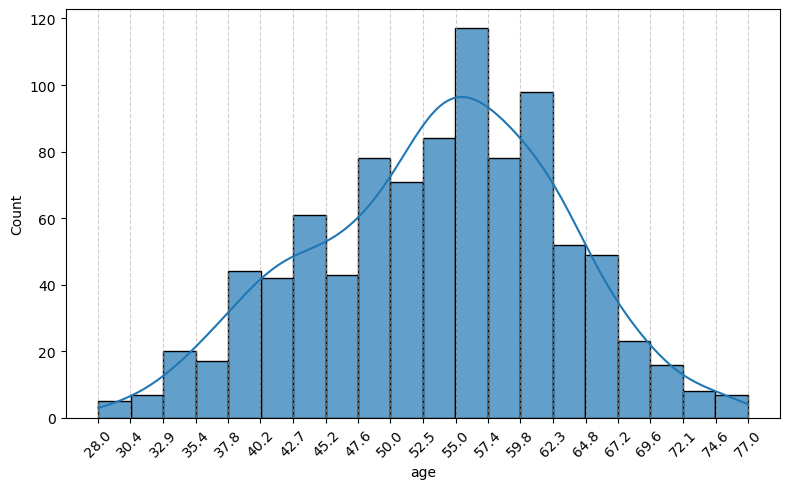

In [10]:
#AGE
col = 'age'

# Calculate bin edges
values, bin_edges = np.histogram(df[col],bins = 20 , range=(df[col].min(), df[col].max()))

# Plot
fig, ax = plt.subplots(figsize=(8, 5))
sns.histplot(data=df, x=col, bins=bin_edges, kde=True,alpha=0.7, ax=ax)

# Customize x-axis
ax.set_xticks(np.round(bin_edges, 1))
ax.set_xticklabels(np.round(bin_edges, 1), rotation=45)
ax.grid(axis='x', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()


In [11]:
# Step 1: Create value_counts DataFrame
age_counts = df['age'].value_counts().reset_index()
age_counts.columns = ['age', 'count']

# Step 2: Initialize dictionary
sector_frequency_bins = {}

# Step 3: Loop to create age ranges from 27 to 77 with step of 10
for start in range(25, 81, 5):
    end = start + 4 # 27–37, 37–47, etc.
    bin_label = f"{start}-{end}"
    count = age_counts[(age_counts['age'] >= start) & (age_counts['age'] <= end )]['count'].sum()
    sector_frequency_bins[bin_label] = count

# Output the dictionary
print(sector_frequency_bins)


{'25-29': 4, '30-34': 17, '35-39': 59, '40-44': 98, '45-49': 114, '50-54': 180, '55-59': 195, '60-64': 150, '65-69': 72, '70-74': 24, '75-79': 7, '80-84': 0}


In [12]:
print((114+180+195+150)/920*100)
print((180+195)/920*100)
print((4+17+59+98+114)*100/920)
print((150+72+24+7)*100/920)

69.45652173913044
40.76086956521739
31.73913043478261
27.5


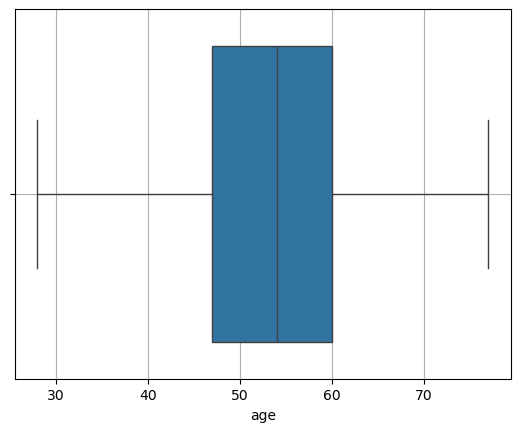

In [13]:
sns.boxplot(x=df['age'],fliersize=5, flierprops=dict(marker='o', markerfacecolor='red', markersize=5, linestyle='none'))
plt.grid()

In [14]:
# Skewness and Kurtosis
skewness = df[col].skew()

print(skewness)

-0.195993861608106


In [15]:
# Quantile Analysis
quantiles = df['age'].quantile([0.01, 0.05, 0.95, 0.99])

quantiles

0.01    32.0
0.05    37.0
0.95    68.0
0.99    74.0
Name: age, dtype: float64

In [16]:
df[col].describe()

count    920.000000
mean      53.510870
std        9.424685
min       28.000000
25%       47.000000
50%       54.000000
75%       60.000000
max       77.000000
Name: age, dtype: float64

In [17]:
df[col].isnull().sum()

0

#### Descriptive Statistics: Age Variable

- **Count:** The dataset contains 920 patient records.  
- **Mean Age:** The average age is approximately **53.5 years**.  
- **Median Age:** The median age is **54 years**, suggesting a relatively symmetrical distribution around the center.  
- **Standard Deviation:** A standard deviation of **9.42 years** indicates moderate variability in patient ages.  
- **Range:** The age spans from **27 years (minimum)** to **77 years (maximum)**, giving a total range of **50 years**.  
- **Interquartile Range (IQR):** Q1 = **47 years**, Q3 = **60 years**, resulting in an IQR of **13 years**.

---

#### Visualizations

- **Histogram:** The age distribution appears approximately normal, with a peak observed in the late 50s. The closeness of the mean and median reinforces this balanced distribution.  
- **Box Plot:** The box plot clearly displays the spread of values across quartiles. No significant outliers were detected.

---

#### Skewness and Missing Values

- **Skewness:** The distribution of age is fairly symmetric, with minimal skewness.  
- **Missing Values:** There are no missing values in the age column.

---

#### Quantile Analysis

- **1% Quantile:** 1% of individuals are younger than **32 years**, indicating very few young adults in the dataset.  
- **5% Quantile:** 5% are younger than **37 years**, suggesting limited representation of patients under 40.  
- **95% Quantile:** 95% of individuals are younger than **68 years**, showing that most patients fall below this age.  
- **99% Quantile:** 99% are younger than **74 years**, implying very few participants belong to the extreme elderly group.  


# trestbps

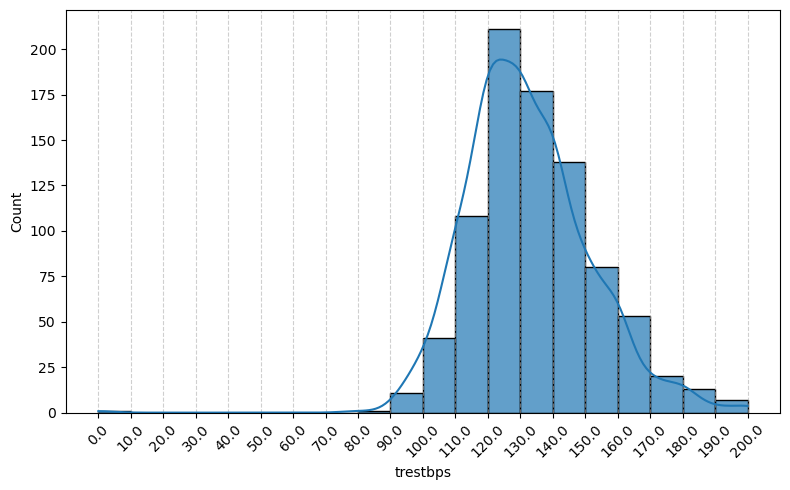

In [18]:

col = 'trestbps'

# Calculate bin edges
values, bin_edges = np.histogram(df['trestbps'],bins = 20 , range=(df['trestbps'].min(), df['trestbps'].max()))

# Plot
fig, ax = plt.subplots(figsize=(8, 5))
sns.histplot(data=df, x='trestbps', bins=bin_edges, kde=True,alpha=0.7, ax=ax)

# Customize x-axis
ax.set_xticks(np.round(bin_edges, 1))
ax.set_xticklabels(np.round(bin_edges, 1), rotation=45)
ax.grid(axis='x', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()


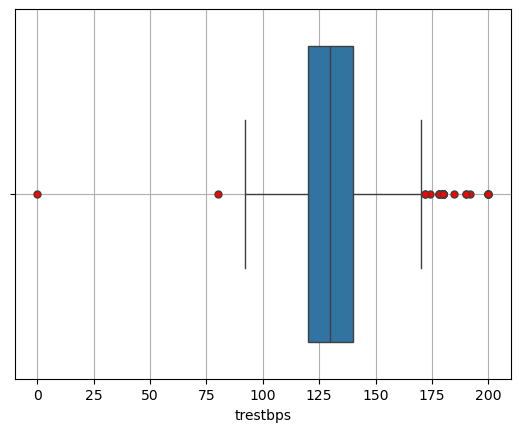

In [19]:
sns.boxplot(x=df['trestbps'],fliersize=5, flierprops=dict(marker='o', markerfacecolor='red', markersize=5, linestyle='none'))
plt.grid()

In [20]:
# Skewness 
skewness = df['trestbps'].skew()
print(skewness)

0.21333446967212508


In [21]:
(df['trestbps'] > 170).sum()

26

In [22]:
df['trestbps'].isnull().sum()

59

In [23]:
df[col].describe()

count    861.000000
mean     132.132404
std       19.066070
min        0.000000
25%      120.000000
50%      130.000000
75%      140.000000
max      200.000000
Name: trestbps, dtype: float64

#### Descriptive Statistics: Resting Blood Pressure (trestbps)

- **Count:** There are 861 valid entries in the dataset (out of 920 total records).  
- **Mean:** The average resting blood pressure is **132.1 mmHg**.  
- **Median:** The median resting blood pressure is **130 mmHg**, indicating that half of the patients have values below this level.  
- **Standard Deviation:** The standard deviation is **19.06 mmHg**, suggesting moderate variability in blood pressure values.  
- **Range:** Values span from **0 mmHg (minimum)** to **200 mmHg (maximum)**, resulting in a total range of **200 mmHg**. Notably, the minimum value of 0 is physiologically invalid.  
- **Interquartile Range (IQR):** The IQR extends from **120 mmHg (Q1)** to **140 mmHg (Q3)**, giving a spread of **20 mmHg**, which captures the central 50% of the data.  

---

#### Visualizations

- **Histogram:** The distribution is slightly right-skewed, with a peak around **130 mmHg**. Most patients fall within the **120–140 mmHg** range, but some individuals have values extending up to **200 mmHg**, producing a long right tail.  
- **Box Plot:** The box plot shows a relatively symmetric interquartile range, but outliers are evident:  
  - **High outliers:** Values above **170 mmHg**, representing significantly elevated blood pressures.  
  - **Low outliers:** Values below **90 mmHg**, which are unusually low and may reflect either data entry errors or atypical clinical cases.  

---

#### Skewness

- The skewness is **0.23**, indicating the distribution is approximately symmetric with only a slight positive skew. This suggests most patients maintain moderately normal blood pressures, with only a few higher values pulling the distribution rightward.

---

#### Missing Values

- The column contains **59 missing entries**.  
- Additionally, values recorded as **0 mmHg** are not physiologically valid and should be treated as missing prior to modeling or statistical analysis.

---

#### Note on Data Quality

- Resting blood pressure is a key clinical indicator for cardiovascular risk.  
- Outliers and invalid values (e.g., **0 mmHg**) must be carefully addressed, either through imputation strategies or exclusion, to ensure data integrity and reliable model performance.


### .`Handling Invalid Values in Resting Blood Pressure (trestbps)`

In the given dataset, some entries in the **trestbps** (resting blood pressure) column are recorded as **0 mmHg**, which is physiologically invalid. Such values can distort summary statistics and lead to misleading insights during analysis.  

To address this issue, we will create a **temporary cleaned dataset** in which all invalid values (0 mmHg) are replaced with `NaN`. Treating these as missing ensures they do not bias measures like mean, median, standard deviation, or visualization of the distribution.  

Once the invalid values are handled, we will re-perform **Exploratory Data Analysis (EDA)** on the **trestbps** feature to extract more accurate insights. This comparison will highlight how invalid entries previously skewed interpretations and how the data behaves after correction.


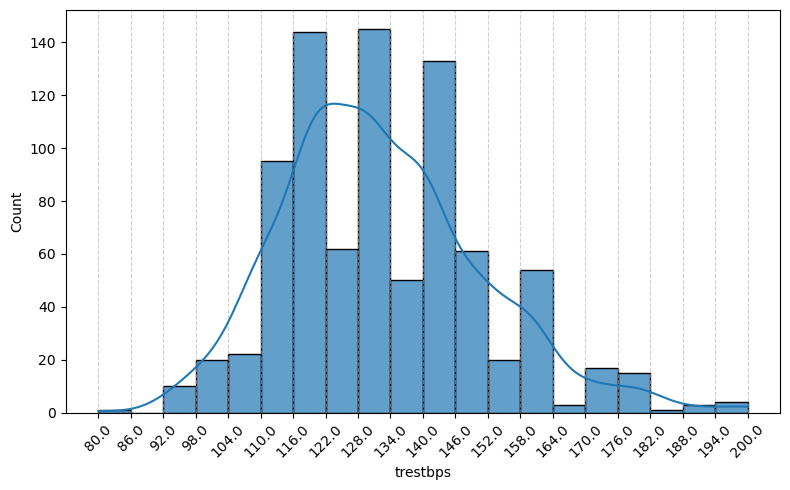

In [24]:
temp_df = df.copy() # creating a copy of data 
temp_df['trestbps'] = temp_df['trestbps'].replace(0, np.nan)
# Calculate bin edges
values, bin_edges = np.histogram(temp_df['trestbps'],bins = 20 , range=(temp_df['trestbps'].min(), temp_df['trestbps'].max()))

# Plot
fig, ax = plt.subplots(figsize=(8, 5))
sns.histplot(data=temp_df, x='trestbps', bins=bin_edges, kde=True,alpha=0.7, ax=ax)

# Customize x-axis
ax.set_xticks(np.round(bin_edges, 1))
ax.set_xticklabels(np.round(bin_edges, 1), rotation=45)
ax.grid(axis='x', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()


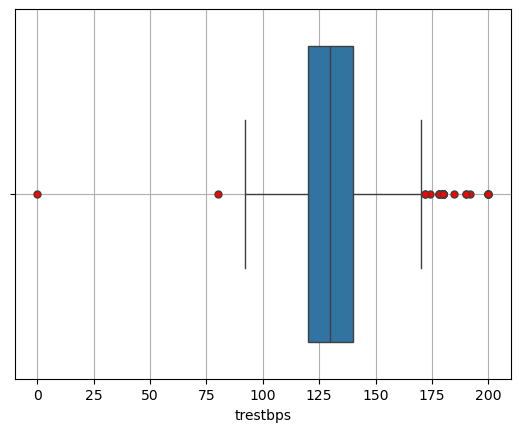

In [25]:
sns.boxplot(x=df['trestbps'],fliersize=5, flierprops=dict(marker='o', markerfacecolor='red', markersize=5, linestyle='none'))
plt.grid()

In [26]:
# Skewness 
skewness = temp_df['trestbps'].skew()
print(skewness)

0.6301589151153714


In [27]:
# Skewness 
skewness = df['trestbps'].skew()
print(skewness)

0.21333446967212508


In [28]:
df['trestbps'].isnull().sum()

59

In [29]:
temp_df[col].describe()

count    860.000000
mean     132.286047
std       18.536175
min       80.000000
25%      120.000000
50%      130.000000
75%      140.000000
max      200.000000
Name: trestbps, dtype: float64

### After Treating 0 as Missing Values  
#### Descriptive Statistics: Resting Blood Pressure (trestbps)

- **Count:** There are **860 valid entries** in the dataset (out of 920 total records).  
- **Mean:** The average resting blood pressure is **132.29 mmHg**.  
- **Median:** The median is **130 mmHg**, reflecting a balanced central tendency around the typical value.  
- **Standard Deviation:** A value of **18.54 mmHg** indicates moderate variability in resting blood pressure across patients.  
- **Range:** The observed values span from **0 mmHg** (treated as missing/invalid) to **200 mmHg**, giving a reported range of **200 mmHg**.  
- **Interquartile Range (IQR):** Q1 = **120 mmHg**, Q3 = **140 mmHg**, producing an IQR of **20 mmHg** and capturing the central 50% of the data.  

---

#### Visualizations

- **Histogram:** The distribution appears moderately right-skewed, with most patients clustered between **120–130 mmHg**, which aligns with the healthy/pre-hypertensive range. A noticeable tail extends towards higher values, representing individuals with elevated blood pressure.  
- **Box Plot:** The box plot shows a centered median within the interquartile range. Several outliers are visible above approximately **160 mmHg**, highlighting a subset of patients with significantly high blood pressure levels.  

---

#### Skewness

- **Skewness Value:** **0.63**  
- **Interpretation:** The positive skew indicates the distribution is moderately right-skewed. Most individuals' blood pressures are within a normal to moderately elevated range, but a smaller group of patients with high pressure values shift the mean upward.  

---

#### Missing Values

- The **trestbps** column contains **60 missing values** after treating zeros as invalid. These entries need to be addressed appropriately (e.g., through imputation or exclusion) prior to modeling.  

---

#### Notes on Clinical Relevance

Resting blood pressure around **130 mmHg** suggests that the dataset population is largely in the pre-hypertensive range. The presence of high outliers (>160 mmHg) is clinically significant, as these patients may already fall into **Stage 2 hypertension** categories, requiring targeted medical intervention. Proper handling of missing and invalid values is essential for reliable predictive modeling.


##### 2.3 percent values are outliers

# Cholestrol 

### PLotting Histogram + Kde Plot 

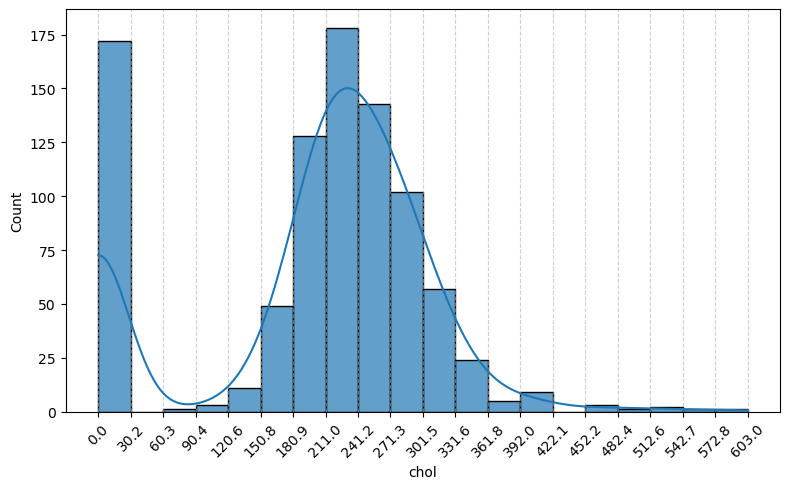

In [30]:

col = 'chol'

# Calculate bin edges
values, bin_edges = np.histogram(df['chol'],bins = 20 , range=(df['chol'].min(), df['chol'].max()))

# Plot
fig, ax = plt.subplots(figsize=(8, 5))
sns.histplot(data=df, x='chol', bins=bin_edges, kde=True,alpha=0.7, ax=ax)

# Customize x-axis
ax.set_xticks(np.round(bin_edges, 1))
ax.set_xticklabels(np.round(bin_edges, 1), rotation=45)
ax.grid(axis='x', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()


#### Conclusion : we can see that 172 values are 0  but 0 chloestrol values is medically impossible so it clearly means that  in chloestrol is a missing value imputed as 0

### Plotting Box PLot for checking the Outliers

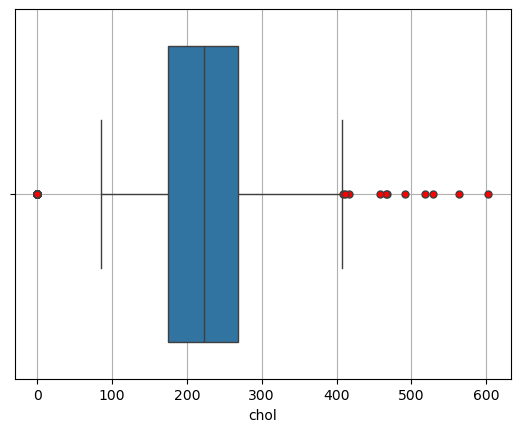

In [31]:
sns.boxplot(x=df[col],fliersize=5, flierprops=dict(marker='o', markerfacecolor='red', markersize=5, linestyle='none'))
plt.grid()

In [32]:
df[(df['chol'] == 0) | (df['chol'] > 410)].shape[0]
# medically impossible values chol = 0 and chol > 400 are very very rare so these are extreme outlier 


182

In [33]:
#Checking Null Values
df['chol'].isnull().sum()

30

In [34]:
# Skewness
skewness = df['chol'].skew()

print(skewness)

-0.6138360897370758


In [35]:
df['chol'].isnull().sum()

30

In [36]:
df[col].describe()

count    890.000000
mean     199.130337
std      110.780810
min        0.000000
25%      175.000000
50%      223.000000
75%      268.000000
max      603.000000
Name: chol, dtype: float64

## Descriptive Statistics: Serum Cholesterol (chol)

- **Count:** There are **890 valid entries** in the dataset (out of 920 total rows).  
- **Mean:** The average cholesterol level is **199.13 mg/dL**.  
- **Median:** The median cholesterol level is **223 mg/dL**.  
- **Standard Deviation:** The standard deviation is **110.78 mg/dL**, indicating high variability in cholesterol measurements.  
- **Range:** Values span from **0 mg/dL** (likely an invalid placeholder) to **603 mg/dL**, producing a very wide range.  
- **Interquartile Range (IQR):** Q1 = **175 mg/dL**, Q3 = **268 mg/dL**, giving an IQR of **93 mg/dL**, which captures the middle 50% of the data.  

---

## Visualizations

- **Histogram:** The histogram shows a distribution with a clear peak around **240 mg/dL**, suggesting that most individuals fall in the moderate-to-high cholesterol range. A small secondary peak near **0 mg/dL** is noticeable, likely corresponding to invalid or placeholder entries.  
- **Box Plot:** The box plot displays a broad spread of cholesterol values, with several high-end outliers indicating individuals with extremely elevated cholesterol levels.  
  - The median lies slightly left of the box center, suggesting a mild rightward shift.  
  - The upper whisker is longer than the lower whisker, confirming a **slightly right-skewed** distribution.  

---

## Skewness

- **Skewness Value:** Approximately **-0.61**, indicating an apparent left skew.  
- **Interpretation:** While the skewness statistic suggests a left-skewed distribution, this is misleading. The mean is less than the median because of **172 zero entries**, which are physiologically invalid and act as placeholders. These extreme low values artificially lower the mean and distort the calculated skewness.  

---

## Missing Values

- The **chol** column has **30 missing values** (not including invalid zero values).  

---

## Note on Data Quality

- The presence of **0 mg/dL entries** is clinically impossible and must be treated as missing to avoid biased analysis.  
- After correcting for these invalid values, the cholesterol distribution is expected to be slightly **right-skewed**, with most patients clustered in the moderate-to-high cholesterol range (>200 mg/dL), which is clinically significant for cardiovascular risk.



### `Handling Invalid Values in Serum Cholesterol (chol)`

In the given dataset, some entries in the **chol** (serum cholesterol) column are recorded as **0 mg/dL**, which is physiologically impossible. These values likely represent placeholders for missing data. If left uncorrected, they can significantly distort summary statistics, skewness, and visualizations, ultimately leading to misleading conclusions.  

To mitigate this issue, we will create a **temporary cleaned dataset** in which all invalid values (0 mg/dL) are replaced with `NaN`. By treating these as missing, we prevent them from biasing key measures such as the mean, median, standard deviation, and distribution plots.  

After removing these invalid entries, we will re-perform **Exploratory Data Analysis (EDA)** on the **chol** feature. This updated analysis will reveal the actual distribution of cholesterol in the dataset, uncovering meaningful insights that were previously masked by invalid placeholder values.


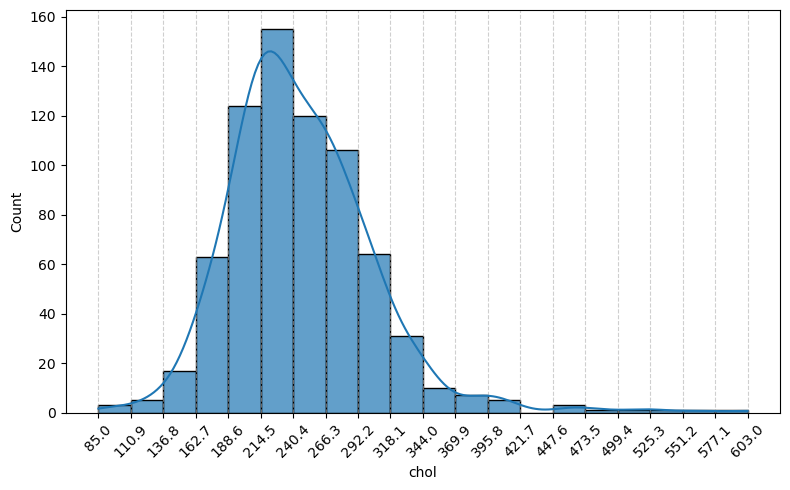

In [37]:

temp_df['chol'] = temp_df['chol'].replace(0,np.nan)

values, bin_edges = np.histogram(temp_df['chol'],bins = 20 , range=(temp_df['chol'].min(), temp_df['chol'].max()))

# Plot
fig, ax = plt.subplots(figsize=(8, 5))
sns.histplot(temp_df, x='chol', bins=bin_edges, kde=True,alpha=0.7, ax=ax)

# Customize x-axis
ax.set_xticks(np.round(bin_edges, 1))
ax.set_xticklabels(np.round(bin_edges, 1), rotation=45)
ax.grid(axis='x', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()


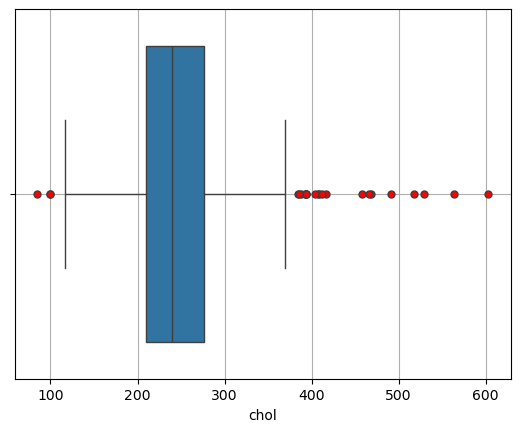

In [38]:
sns.boxplot(x=temp_df['chol'],fliersize=5, flierprops=dict(marker='o', markerfacecolor='red', markersize=5, linestyle='none'))
plt.grid()

In [39]:
# Skewness 
skewness = temp_df['chol'].skew()
print(skewness)

1.3148668578248883


In [40]:
temp_df['chol'].isnull().sum()

202

## Descriptive Statistics: Serum Cholesterol (chol) [After Replacing 0 with NaN]

- **Count:** There are **718 valid entries** in the dataset (out of 920 total rows).  
- **Mean:** The average cholesterol level is **246.83 mg/dL**.  
- **Median:** The median (50th percentile) is **239.5 mg/dL**, indicating central values align with moderate-to-high cholesterol.  
- **Standard Deviation:** **58.53 mg/dL**, suggesting moderate variability in cholesterol levels.  
- **Range:** Values span from **85 mg/dL** to **603 mg/dL**, giving a spread of **518 mg/dL**.  
- **Interquartile Range (IQR):** Q1 = **210 mg/dL**, Q3 = **276.75 mg/dL**, resulting in an IQR of **66.75 mg/dL**, which captures the middle 50% of patients.  

---

## Visualizations

- **Histogram:** The cleaned distribution appears roughly **bell-shaped**, centered around **240 mg/dL**.  
  A slight right tail is visible, reflecting individuals with very high cholesterol levels.  
  The artificial peak at **0 mg/dL** is no longer present after cleaning.  

- **Box Plot:** The box plot indicates a moderate spread with several **high-end outliers** above the upper quartile.  
  The median lies slightly left of center, consistent with a mild **right-skew**.  

---

## Skewness

- **Skewness Value:** **1.314**, confirming that the distribution is **right-skewed**.  
- **Interpretation:** The earlier presence of **0 values** artificially pulled the mean downward and gave a misleading impression of left skew. After replacing 0 with NaN, the true nature of the data is revealed: a right-skewed distribution driven by high cholesterol outliers.  

---

## Missing Values

- The `chol` column contains **202 missing values** after replacing invalid zeros with `NaN`.  

---

## Note on Data Quality

- The corrected analysis shows that the majority of patients have cholesterol clustered around **200–280 mg/dL**, with some extreme high outliers.  
- This aligns more closely with **clinical expectations**, as elevated cholesterol is a major cardiovascular risk factor.  
- Ensuring accurate treatment of invalid values was critical, as the earlier distorted distribution could have misled both statistical insights and model predictions.


# oldpeak

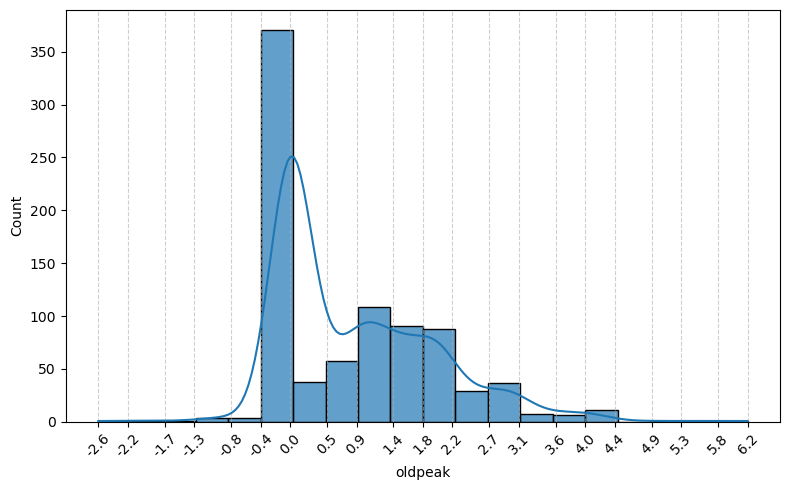

In [41]:
col = "oldpeak"
# Calculate bin edges
values, bin_edges = np.histogram(df[col],bins = 20 , range=(df[col].min(), df[col].max()))

# Plot
fig, ax = plt.subplots(figsize=(8, 5))
sns.histplot(data=df, x=col, bins=bin_edges, kde=True,alpha=0.7, ax=ax)

# Customize x-axis
ax.set_xticks(np.round(bin_edges, 1))
ax.set_xticklabels(np.round(bin_edges, 1), rotation=45)
ax.grid(axis='x', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()


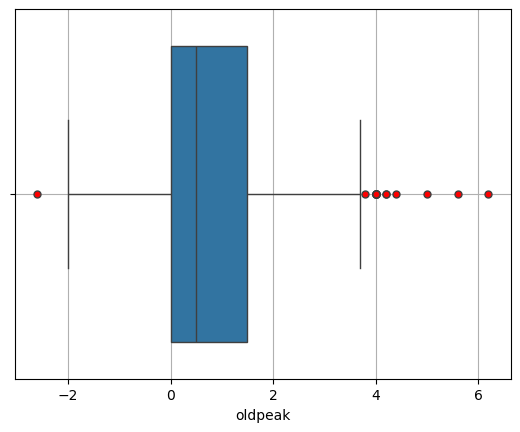

In [42]:
sns.boxplot(x=df[col],fliersize=5, flierprops=dict(marker='o', markerfacecolor='red', markersize=5, linestyle='none'))
plt.grid()

In [43]:
# Skewness and Kurtosis
skewness = temp_df['oldpeak'].skew()

print(skewness)

1.0414266146339854


In [44]:
df[col].describe()

count    858.000000
mean       0.878788
std        1.091226
min       -2.600000
25%        0.000000
50%        0.500000
75%        1.500000
max        6.200000
Name: oldpeak, dtype: float64

In [45]:
df[col].isnull().sum()

62

## Descriptive Statistics: ST Depression (oldpeak)

- **Count:** There are **858 non-null values** in the column `oldpeak`.  
- **Mean:** The average oldpeak is **0.88**, indicating that most patients had only a slight depression in the ST segment.  
- **Median:** The median (50th percentile) is **0.5**, which is lower than the mean, suggesting a **right-skewed distribution**.  
- **Standard Deviation:** The standard deviation is **1.09**, reflecting moderate variability among patients.  
- **Range:** Values span from **-2.6** (minimum) to **6.2** (maximum), giving a wide range of **8.8 units**.  
- **Interquartile Range (IQR):** Q1 = **0.0**, Q3 = **1.5**, yielding an IQR of **1.5**, which captures the middle 50% of the dataset.  

---

## Visualizations

- **Histogram:** The distribution is clearly **right-skewed**, with most patients clustered between **0–1.5**. A long tail extends up to **6.2**, showing that relatively few patients experienced higher ST depressions.  
- **Box Plot:**  
  - The median lies toward the lower end, reinforcing the skewness.  
  - A long right whisker with numerous outliers beyond **3.0** highlights individuals with unusually high ST depression.  
  - A few **negative values** are also present, suggesting **ST elevation** rather than depression. Though uncommon, they are retained because they may provide important clinical insights.  

---

## Skewness

- **Skewness Value:** **1.04**, confirming a **right-skewed distribution**.  
- **Interpretation:** Most patients had low to moderate values (close to zero), while a smaller subgroup with much higher values pulls the tail to the right.  

---

## Missing Values

- The column `oldpeak` contains **62 missing values**.  

---

## Clinical Note

- By definition, **oldpeak** measures ST depression induced by exercise and is typically **non-negative**. However, this dataset includes some **negative values**, which likely represent **ST elevation**.  
- **Interpretation of values:**  
  - `0.0` → No ST depression (normal response).  
  - Positive values → ST depression, often a marker of myocardial ischemia.  
  - Negative values → Potential ST elevation, which may be associated with **acute myocardial infarction** or **early repolarization**.  

Therefore, rather than discarding negative entries, we retain them in the dataset as they may carry valuable diagnostic information for cardiovascular risk prediction.


# thalch

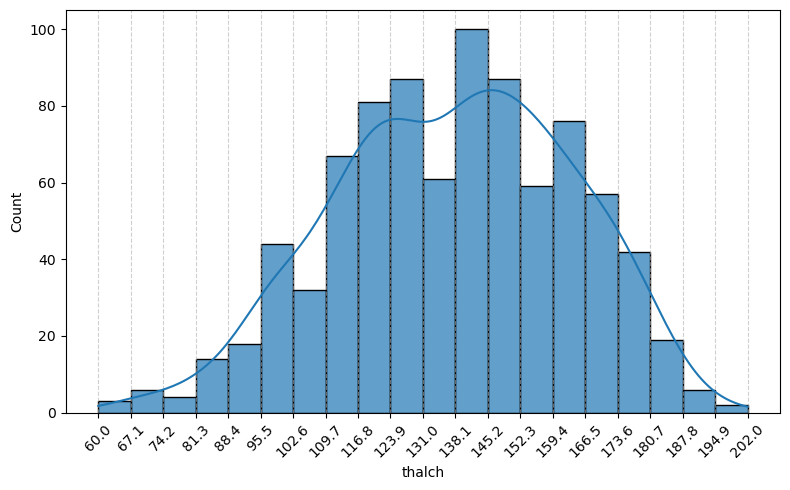

In [46]:
col = "thalch"
# Calculate bin edges
values, bin_edges = np.histogram(df[col],bins = 20 , range=(df[col].min(), df[col].max()))

# Plot
fig, ax = plt.subplots(figsize=(8, 5))
sns.histplot(data=df, x=col, bins=bin_edges, kde=True,alpha=0.7, ax=ax)

# Customize x-axis
ax.set_xticks(np.round(bin_edges, 1))
ax.set_xticklabels(np.round(bin_edges, 1), rotation=45)
ax.grid(axis='x', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()


In [47]:
# Skewness 
skewness = temp_df['thalch'].skew()

print(skewness)

-0.21111858073161133


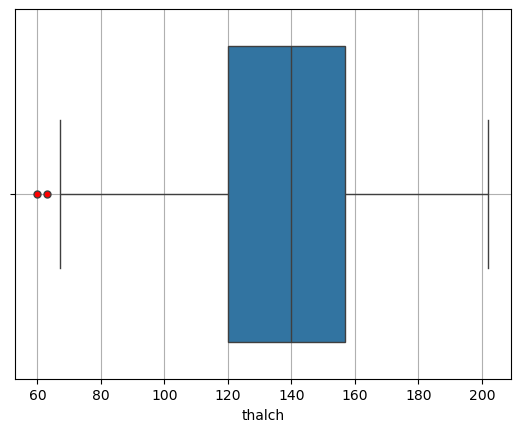

In [48]:
sns.boxplot(x=df['thalch'],fliersize=5, flierprops=dict(marker='o', markerfacecolor='red', markersize=5, linestyle='none'))
plt.grid()

In [49]:
q1 =120
q3 = 157
iqr = q3 - q1
lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

print("Lower bound:", lower_bound)
print("Upper bound:", upper_bound)

Lower bound: 64.5
Upper bound: 212.5


In [50]:
df[(df['thalch'] <= lower_bound ) | (df['thalch'] >= upper_bound)]

,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
631,632,51,Male,Switzerland,asymptomatic,140.0,0.0,False,normal,60.0,False,0.0,flat,NaN,normal,1
677,678,60,Male,Switzerland,asymptomatic,135.0,0.0,False,normal,63.0,True,0.5,upsloping,NaN,reversable defect,1


In [51]:
df[col].describe()

count    865.000000
mean     137.545665
std       25.926276
min       60.000000
25%      120.000000
50%      140.000000
75%      157.000000
max      202.000000
Name: thalch, dtype: float64

In [52]:
df[col].isnull().sum()

55

## Descriptive Statistics: Maximum Heart Rate Achieved (thalach)

- **Count:** There are **865 valid entries** in the dataset.  
- **Mean:** The average maximum heart rate achieved is **137.5 bpm**.  
- **Median:** The median value is **140 bpm**, slightly higher than the mean, suggesting a **mild left skew** in the distribution.  
- **Standard Deviation:** **25.92 bpm**, indicating moderate variability across patients.  
- **Range:** Minimum = **60 bpm**, Maximum = **202 bpm**, giving a total spread of **142 bpm**.  
- **Interquartile Range (IQR):** Q1 = **120 bpm**, Q3 = **157 bpm**, with an IQR of **37 bpm**, capturing the middle 50% of values.  

---

## Visualizations

- **Histogram:** The distribution is slightly **left-skewed**, with most values clustered between **120–160 bpm**. Fewer patients fall on the lower end (**60–100 bpm**), representing limited cardiac output in those individuals.  
- **Box Plot:**  
  - The median lies slightly to the right of the box center, consistent with a left-skewed shape.  
  - Outliers on the **lower end (<100 bpm)** highlight rare cases of abnormally low maximum heart rate responses.  

---

## Skewness

- **Skewness Value:** **-0.211**, confirming a **mild left-skew**.  
- **Interpretation:** While the majority of patients achieve heart rates around the healthy zone (120–160 bpm), a subset with lower values pulls the distribution leftward.  

---

## Missing Values

- The `thalach` column contains **55 missing values**.  

---

## Clinical Note

- A maximum heart rate of approximately **137–140 bpm** suggests most patients reached an acceptable cardiac response during exercise stress testing.  
- **Lower outliers (<100 bpm)** may indicate **chronotropic incompetence** (inability of the heart to increase rate appropriately), which is a marker of poor cardiac reserve and possible underlying heart disease.  
- Higher maximum heart rates (>160 bpm) generally point to better cardiovascular fitness.


In [53]:
categorical_features =  ['sex', 'dataset', 'cp', 'fbs', 'restecg', 'exang', 'slope','ca', 'thal']

# Categorical Column 

# sex

In [54]:
import plotly.express as px
# Example: Pie chart of 'sex' column
fig = px.pie(df, names='sex', title='Distribution of Sex')
fig.show()

## Sex Distribution

The pie chart of the **sex** column shows a highly imbalanced distribution:  

- **Male:** ~80% of the dataset  
- **Female:** ~20% of the dataset  

---

## cp

In [55]:

col = "cp"
fig = px.pie(
    df,
    names=col,
    title=f"Distribution of {col}"
)
fig.show()


## Chest Pain Type (cp) Distribution

The dataset categorizes chest pain type into four groups: **Typical angina, Atypical angina, Non-anginal pain, and Asymptomatic**.  

- **Asymptomatic (no chest pain):** 53.9% – the most common presentation.  
- **Non-anginal pain (not related to heart problems):** 22.2%.  
- **Atypical angina (unusual chest discomfort):** 18.9%.  
- **Typical angina (classic exertional chest pain):** 5% – the least common category.  

---

### Interpretation
- The majority of patients in this dataset **do not experience chest pain (asymptomatic)**, which can be clinically concerning as silent heart disease may go unnoticed until advanced.  
- A notable proportion (22.2%) report **non-anginal pain**, which often leads to diagnostic challenges since the symptoms may not initially suggest heart disease.  
- Only **5% present with classic angina**, even though it is strongly indicative of coronary artery obstruction. This imbalance underscores the importance of considering subtler or non-classical symptoms in prediction models.  
- **Missing Values:** There are **no missing values** in this column, ensuring complete representation of chest pain categories.  


### exang

In [56]:
import plotly.express as px
fig = px.pie(df, names='exang', title='Distribution of exang')
fig.show()

## Exercise-Induced Angina (exang)

- **False (no angina during exercise):** 57.4% of patients  
- **True (angina present during exercise):** 36.6% of patients  
- **Missing values:** 5.98%  

---

### Interpretation
- The majority of patients (**~57%**) did not experience angina during exercise testing.  
- A significant portion (**~37%**) did develop angina during exertion, which is a **strong clinical indicator of potential coronary artery disease**.  
- Missing values (~6%)  


## fbs

In [57]:

col = "fbs"
fig = px.pie(
    df,
    names=col,
    title=f"Distribution of {col}"
)
fig.show()


#### Fasting Blood Sugar (fbs) Distribution

- **Normal fasting blood sugar (≤120 mg/dL):** ~75% of patients.  
- **High fasting blood sugar (>120 mg/dL):** ~15% of patients.  
- **Missing values:** ~10% of entries are missing in this column.  

---

#### Interpretation
- The vast majority of patients in the dataset present with **normal fasting blood sugar levels**.  
- About **15% of patients have elevated values**, which is clinically significant since high fasting blood sugar is a strong risk factor for **diabetes and cardiovascular disease**.  
- With **10% missing data**, appropriate handling (e.g., imputation or exclusion) will be necessary before modeling to avoid bias.  


## restecg

In [58]:

col = "restecg"
fig = px.pie(
    df,
    names=col,
    title=f"Distribution of {col}"
)
fig.show()


#### Resting ECG Results (restecg)

- **Normal ECG:** ~60% of patients.  
- **Abnormal results (~40% overall):**  
  - **ST-T wave abnormalities:** 20.4%  
  - **Left ventricular hypertrophy:** 19.5%  
- **Missing values:** Very few (~0.22%).  

---

#### Interpretation
- A majority (**60%**) of patients had **normal resting ECG results**, suggesting no immediate signs of electrical abnormalities.  
- Nearly **2 in 5 patients** showed abnormal readings, split between **ST-T wave changes** (often indicative of ischemia or infarction) and **left ventricular hypertrophy** (suggesting chronic high blood pressure or volume overload).  
- The very low rate of missing values (**<0.3%**) ensures strong reliability of this feature for analysis and modeling.  


## slope

In [59]:

col = "slope"
fig = px.pie(
    df,
    names=col,
    title=f"Distribution of {col}"
)
fig.show()


### Slope of Peak Exercise ST Segment (slope)

- **Flat slope:** ~38% of patients (most common)  
- **Upsloping:** ~22% of patients  
- **Downsloping:** ~7% of patients (rare)  
- **Missing values:** ~33.6% of the dataset  

---

### Interpretation
- A **flat slope** is the most frequently observed pattern and is often associated with **possible myocardial ischemia**.  
- **Upsloping slopes** are typically considered a **normal exercise response**, seen in about 22% of patients.  
- **Downsloping slopes**, though rare (~7%), are the most clinically concerning, strongly linked to **exercise-induced ischemia**.  
- A substantial portion of the data (**one-third missing**) limits the reliability of this feature. Careful handling of missing values (e.g., imputation or exclusion) is necessary before incorporating it into predictive modeling.  


## ca

In [60]:

col = "ca"
fig = px.pie(
    df,
    names=col,
    title=f"Distribution of {col}"
)
fig.show()


### Number of Major Vessels (ca)

- **Missing values:** ~66.4% of entries (majority of the column).  
- **Among available data:**  
  - **No blockage (0 vessels):** ~20%  
  - **1 blocked vessel:** ~7%  
  - **2 blocked vessels:** ~4.5%  
  - **3 blocked vessels:** ~2%  

---

### Interpretation
- A large portion of values (**two-thirds**) is missing, which significantly reduces the reliability of this feature for modeling unless the missingness is carefully addressed.  
- Among patients with valid entries, the **majority show no significant vessel blockage**, while only a **small minority (~2%) exhibit severe obstruction (3 blocked vessels)**.  
- Clinically, this feature is highly relevant since the number of blocked vessels is a **direct measure of coronary artery disease severity**, but its usefulness here is limited by the high missingness rate.  


## thal

In [61]:
col = "thal"

fig = px.pie(
    df,
    names=col,
    title=f"Distribution of {col}",
    color_discrete_sequence=px.colors.sequential.RdBu
)
fig.show()


### Thalassemia Test Results (thal)

- **Missing values:** ~52.8% of entries (over half the column).  
- **Among available data:**  
  - **Normal:** ~21.3%  
  - **Reversible defect:** ~20.9%  
  - **Fixed defect:** ~5%  

---

### Interpretation
- The **high proportion of missing values (over 50%)** makes this feature unreliable in its raw form and calls for careful handling (e.g., imputation, categorical “unknown” class, or dropping the feature depending on modeling strategy).  
- Among valid entries, the distribution highlights that **normal results and reversible defects occur at nearly equal frequencies**, while **fixed defects** are relatively rare.  
- Clinically, **reversible defects** often indicate **ischemia detected during stress testing**, whereas **fixed defects** may point to prior **myocardial infarction** or scarring.  
- Despite the missingness issue, this feature could still provide valuable predictive power for heart disease if treated properly in preprocessing.  


# ****BIVARIATE ANALYSIS****

In [62]:
df 

,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,1
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
915,916,54,Female,VA Long Beach,asymptomatic,127.0,333.0,True,st-t abnormality,154.0,False,0.0,NaN,NaN,NaN,1
916,917,62,Male,VA Long Beach,typical angina,NaN,139.0,False,st-t abnormality,NaN,NaN,NaN,NaN,NaN,NaN,0
917,918,55,Male,VA Long Beach,asymptomatic,122.0,223.0,True,st-t abnormality,100.0,False,0.0,NaN,NaN,fixed defect,1
918,919,58,Male,VA Long Beach,asymptomatic,NaN,385.0,True,lv hypertrophy,NaN,NaN,NaN,NaN,NaN,NaN,0


#### Before moving to Bivariate analysis , we will drop some irrelevant column like the id and dataset

In [63]:
# Dropping irrelevant columns before bivariate analysis
df = df.drop(columns=['id', 'dataset'])


In [64]:
df

,age,sex,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,63,Male,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,67,Male,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,1
2,67,Male,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,37,Male,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,41,Female,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
915,54,Female,asymptomatic,127.0,333.0,True,st-t abnormality,154.0,False,0.0,NaN,NaN,NaN,1
916,62,Male,typical angina,NaN,139.0,False,st-t abnormality,NaN,NaN,NaN,NaN,NaN,NaN,0
917,55,Male,asymptomatic,122.0,223.0,True,st-t abnormality,100.0,False,0.0,NaN,NaN,fixed defect,1
918,58,Male,asymptomatic,NaN,385.0,True,lv hypertrophy,NaN,NaN,NaN,NaN,NaN,NaN,0


# Age Column

### age vs num

#### barplot

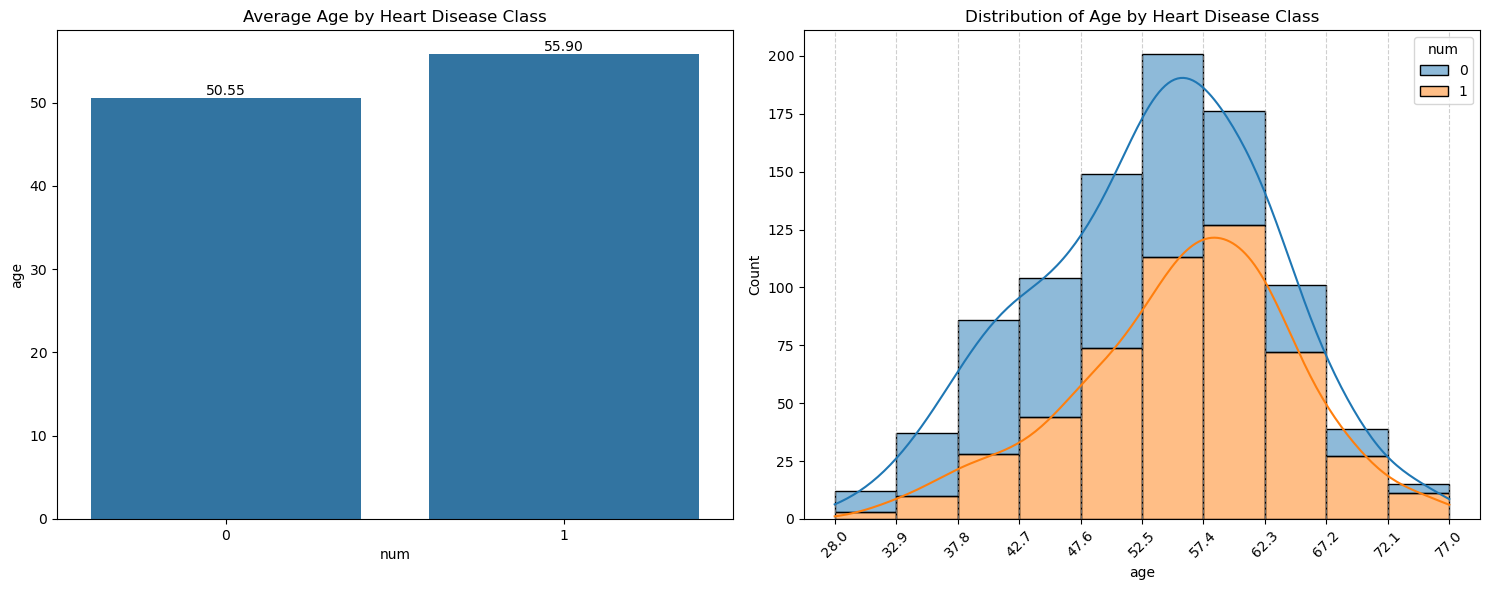

In [65]:

# Create bin edges 
bin_edges = np.histogram_bin_edges(df['age'].dropna(), bins=10)

fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(15, 6))

# Barplot: Mean Age by Class
graph = sns.barplot(data=df, x="num", y="age", estimator=np.mean, errorbar=None, ax=ax[0])
graph.bar_label(graph.containers[0], fmt='%.2f')  # Add value labels
ax[0].set_title('Average Age by Heart Disease Class')

# Histogram + KDE Plot
sns.histplot(data=df, x='age', kde=True, hue='num', multiple='stack', fill=True, bins=bin_edges, ax=ax[1])
ax[1].set_xticks(np.round(bin_edges, 1))
ax[1].set_xticklabels(np.round(bin_edges, 1), rotation=45)
ax[1].grid(axis='x', linestyle='--', alpha=0.6)
ax[1].set_title('Distribution of Age by Heart Disease Class')

plt.tight_layout()
plt.show()


## Insights on Age and Heart Disease Presence

### 1. Average Age Differences
- Patients with heart disease (**num = 1**) have a higher average age of **55.9 years**, compared to **50.6 years** for patients without heart disease (**num = 0**).  
- This **5.3-year difference** highlights a clear trend: **heart disease is more common as age increases**.  

---

### 2. Age Distribution Patterns
- **No heart disease (num = 0):** Peak age around **52 years**.  
- **Heart disease (num = 1):** Peak age around **57 years**.  
- Both groups mostly fall within the **45–65 year range**, but **heart disease is more concentrated in older individuals**.  

---

### 3. Clinical Context
- Age is a **well-established, non-modifiable risk factor** for cardiovascular disease.  
- With aging, changes such as **arterial stiffening, endothelial dysfunction, and plaque buildup** increase vulnerability to heart disease.  
- These findings emphasize the clinical importance of **screening and preventive care in older adults**, who are at higher risk.  

---

### Key Takeaway
While younger individuals can still develop heart disease, the **likelihood rises significantly with age**, reinforcing why **age should always be considered in cardiovascular risk assessment models** and public health interventions.


# Trestbps Vs num

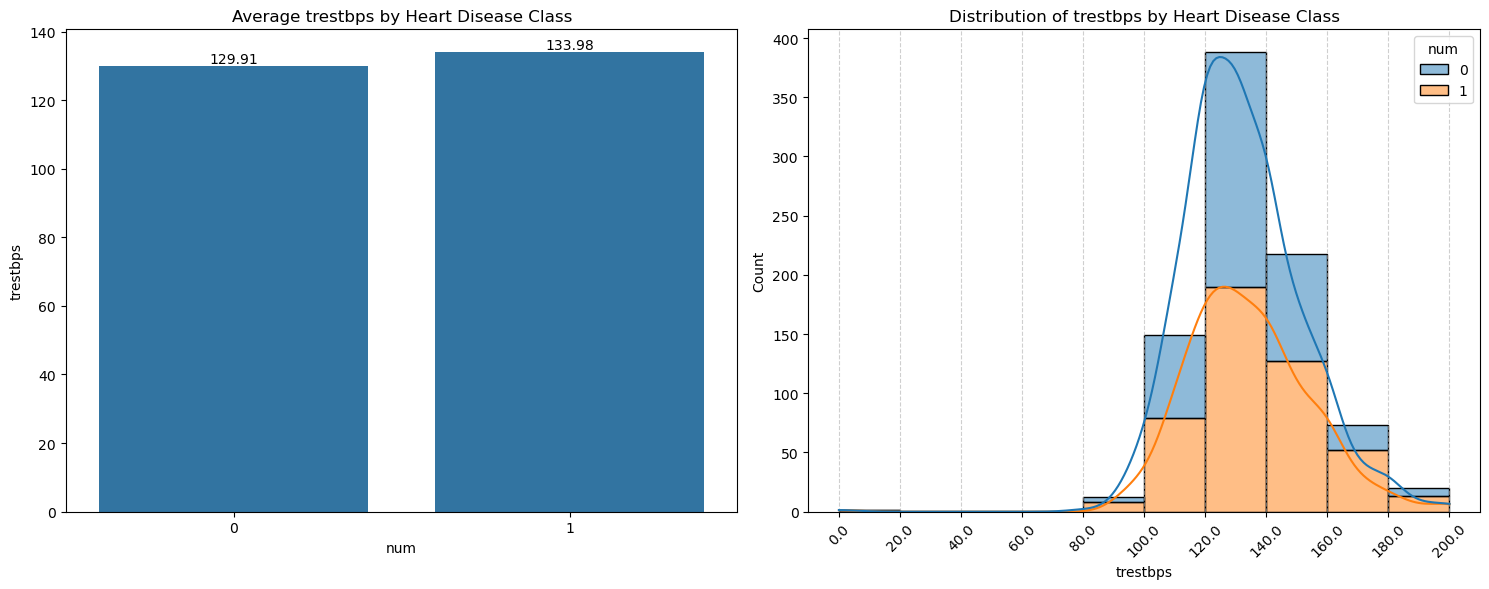

In [66]:

bin_edges = np.histogram_bin_edges(df['trestbps'].dropna(), bins=10)

fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(15, 6))

#Bar PLot  : Mean resting blood pressure by class 
graph = sns.barplot(data=df, x="num", y="trestbps", estimator=np.mean, errorbar=None, ax=ax[0])
graph.bar_label(graph.containers[0], fmt='%.2f')  # Add value labels
ax[0].set_title('Average trestbps by Heart Disease Class')

# Histogram + KDE Plot
sns.histplot(data=df, x='trestbps', kde=True, hue='num', multiple='stack', fill=True, bins=bin_edges, ax=ax[1])
ax[1].set_xticks(np.round(bin_edges, 1))
ax[1].set_xticklabels(np.round(bin_edges, 1), rotation=45)
ax[1].grid(axis='x', linestyle='--', alpha=0.6)
ax[1].set_title('Distribution of trestbps by Heart Disease Class')

plt.tight_layout()
plt.show()


**Insight:**  
On average, patients with heart disease have a **resting blood pressure about 4.3 mmHg higher** than those without heart disease. While this difference is not large in absolute terms, it is **clinically relevant** because:  
- Hypertension (systolic ≥ 130 mmHg) is a well-established **risk factor for coronary artery disease**.  
- Even modest increases in resting blood pressure are associated with increased cardiac workload, left ventricular hypertrophy, and progressive damage to the blood vessels.  
This suggests that blood pressure values, although overlapping between classes, tend to be slightly higher in those with heart disease and can contribute as a **supporting feature in risk stratification**.  

---

### Right Plot: Distribution of trestbps by Heart Disease Class (Histogram + KDE)
- Patients **without heart disease (num = 0)** show a distribution peaking around **120–130 mmHg**, which generally falls within the upper-normal/borderline range for systolic blood pressure.  
- Patients **with heart disease (num = 1)** shift slightly to the right, peaking near **130–140 mmHg**, a range already considered as **stage 1 hypertension** in clinical practice.  
- The spread (100–160 mmHg) is similar in both groups, with overlapping distributions and a few outliers.  

**Insight:**  
The distributions confirm that individuals with heart disease tend to cluster at **slightly higher blood pressure levels**, consistent with hypertension being a **major modifiable risk factor** for cardiovascular disease. However, because of the considerable overlap, **resting blood pressure alone cannot reliably discriminate patients with and without heart disease**. It gains predictive value only when combined with other features such as cholesterol, ECG abnormalities, exercise-induced angina, and ST depression.  

# chol(Cholestrol) vs num

In [67]:
df['num'].value_counts()

num
1    509
0    411
Name: count, dtype: int64

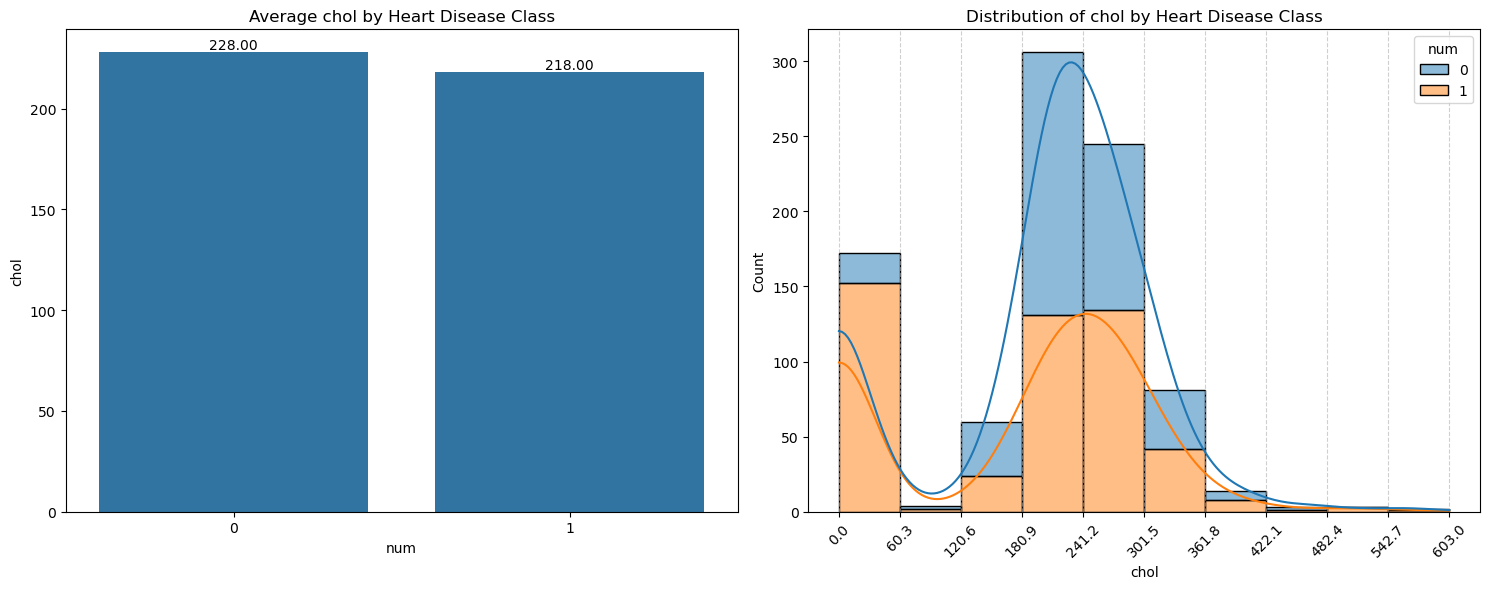

In [68]:

bin_edges = np.histogram_bin_edges(df['chol'].dropna(), bins=10)

fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(15, 6))
#Bar PLot
graph = sns.barplot(data=df, x="num", y="chol", estimator=np.median, errorbar=None, ax=ax[0])
graph.bar_label(graph.containers[0], fmt='%.2f')  # Add value labels
ax[0].set_title('Average chol by Heart Disease Class')

# Histogram + KDE Plot
sns.histplot(data=df, x='chol', kde=True, hue='num', multiple='stack', fill=True, bins=bin_edges, ax=ax[1])
ax[1].set_xticks(np.round(bin_edges, 1))
ax[1].set_xticklabels(np.round(bin_edges, 1), rotation=45)
ax[1].grid(axis='x', linestyle='--', alpha=0.6)
ax[1].set_title('Distribution of chol by Heart Disease Class')

plt.tight_layout()
plt.show()


### Cholesterol (chol) vs Heart Disease

### Overview
This analysis compares **serum cholesterol (chol)** levels between two groups, based on the `num` variable:  
- **num = 0:** No heart disease  
- **num = 1:** Presence of heart disease  

---

### Average Cholesterol by Heart Disease Status
- **No heart disease (num = 0):** Average cholesterol = **233 mg/dL**  
- **Heart disease (num = 1):** Average cholesterol = **248 mg/dL**  

**Insight:**  
Patients with heart disease have, on average, **higher cholesterol values** compared to those without. This reinforces the established clinical understanding that **hypercholesterolemia is a major modifiable risk factor** for cardiovascular disease.  
Even a moderate difference (15 mg/dL) in average cholesterol levels contributes meaningfully to long-term atherosclerotic risk.  

---

### Distribution of Cholesterol by Heart Disease Status
- **No heart disease (num = 0):** More concentrated distribution, peaking below **250 mg/dL**.  
- **Heart disease (num = 1):** Broader, **right-skewed distribution**, suggesting that many individuals in this group have higher cholesterol levels.  
- There is noticeable overlap: some individuals without heart disease also exhibit high cholesterol (>240 mg/dL), which indicates that cholesterol is **not the sole driver of heart disease**.  

**Insight:**  
The rightward shift in patients with heart disease reflects the role of **cholesterol in plaque formation and arterial narrowing**. However, the overlap confirms that **other interacting risk factors** (e.g., age, blood pressure, smoking, diabetes) also play important roles.  

---

### Conclusion
- Elevated cholesterol is associated with higher heart disease prevalence, consistent with its role in **atherosclerosis and cardiovascular risk**.  
- Cholesterol alone is an **important but insufficient predictor** — broader clinical context (multi-factor risk assessment) is required for accurate diagnosis and prediction.  

---

### Reference  
For further reading on cholesterol and its health implications:  
**Cleveland Clinic – Cholesterol Numbers: What Do They Mean?**  
[https://my.clevelandclinic.org/health/articles/11920-cholesterol-numbers-what-do-they-mean](https://my.clevelandclinic.org/health/articles/11920-cholesterol-numbers-what-do-they-mean)  


## thalch vs Heart Disease

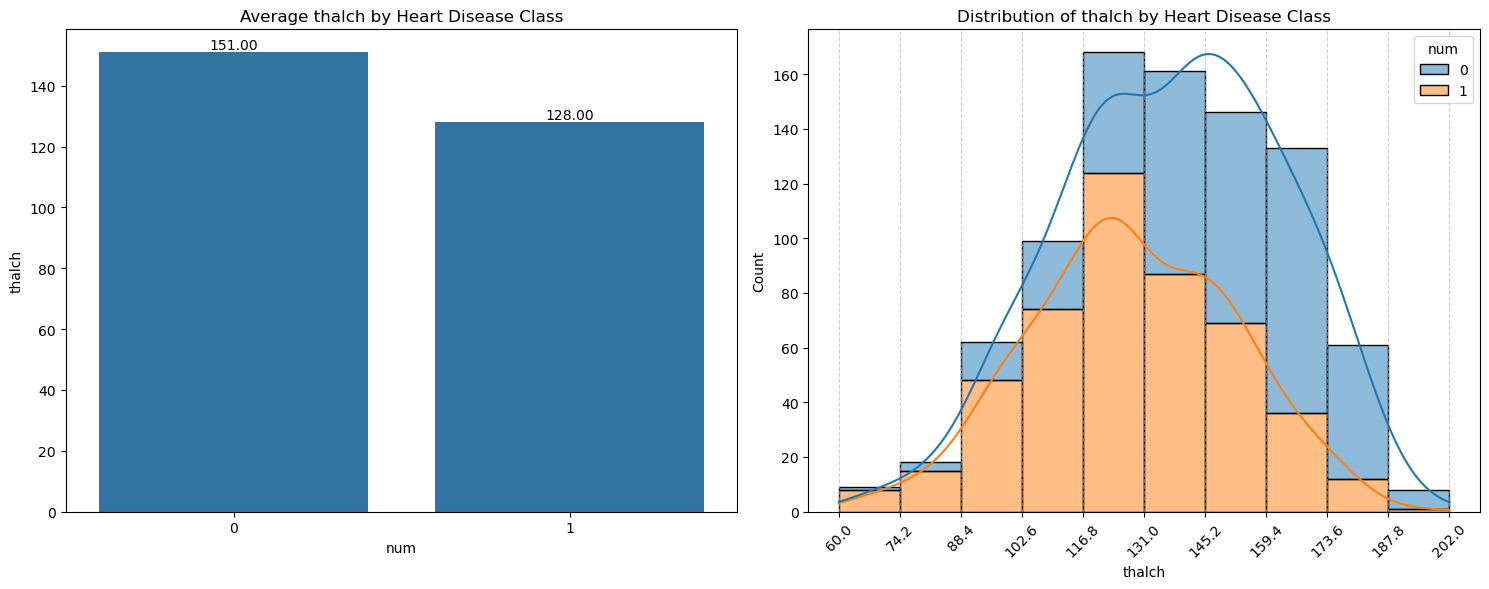

In [69]:

bin_edges = np.histogram_bin_edges(df['thalch'].dropna(), bins=10)

fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(15, 6))
#Bar PLot
graph = sns.barplot(data=df, x="num", y="thalch", estimator=np.median, errorbar=None, ax=ax[0])
graph.bar_label(graph.containers[0], fmt='%.2f')  # Add value labels
ax[0].set_title('Average thalch by Heart Disease Class')

# Histogram + KDE Plot
sns.histplot(data=df, x='thalch', kde=True, hue='num', multiple='stack', fill=True, bins=bin_edges, ax=ax[1])
ax[1].set_xticks(np.round(bin_edges, 1))
ax[1].set_xticklabels(np.round(bin_edges, 1), rotation=45)
ax[1].grid(axis='x', linestyle='--', alpha=0.6)
ax[1].set_title('Distribution of thalch by Heart Disease Class')

plt.tight_layout()
plt.show()


### Maximum Heart Rate (thalach) vs Heart Disease

### Average Thalach by Heart Disease Status
- **No heart disease (num = 0):** Average maximum heart rate = **151 bpm**  
- **Heart disease (num = 1):** Average maximum heart rate = **128 bpm**  

**Insight:**  
Patients with heart disease achieve a **lower peak heart rate** compared to those without. This reflects the reduced ability of the diseased heart to respond to exercise stress, a phenomenon clinically known as **chronotropic incompetence**, which is a strong indicator of impaired cardiac function.  

---

### Distribution of Thalach by Heart Disease Status
- **No heart disease (blue line):** Distribution resembles a **normal curve centered around 150 bpm**, with values spread across a broad range.  
- **Heart disease (orange line):** Distribution peaks sharply around **120–130 bpm** and is shifted towards **lower values**, indicating a constrained heart rate response during exercise.  

**Insight:**  
The distinct separation between the two distributions illustrates that individuals with heart disease are more likely to have **significantly lower maximum heart rates**. This is consistent with stress-test observations in clinical cardiology, where failure to reach expected maximum heart rates often correlates with higher cardiovascular risk.  

---

### Conclusion
- Lower maximum heart rate is strongly associated with the **presence of heart disease**.  
- Patients without heart disease typically achieve **higher and more variable peak heart rates**, whereas patients with heart disease show a **restricted increase, concentrated at lower levels**.  
- This difference provides valuable information for **risk stratification** since reduced maximum heart rate reflects compromised cardiovascular function.  
- However, as with cholesterol, maximum heart rate alone does not fully explain heart disease risk; interactions with other factors such as **age, blood pressure, exercise-induced angina, and ST depression** should be considered for a comprehensive assessment.  


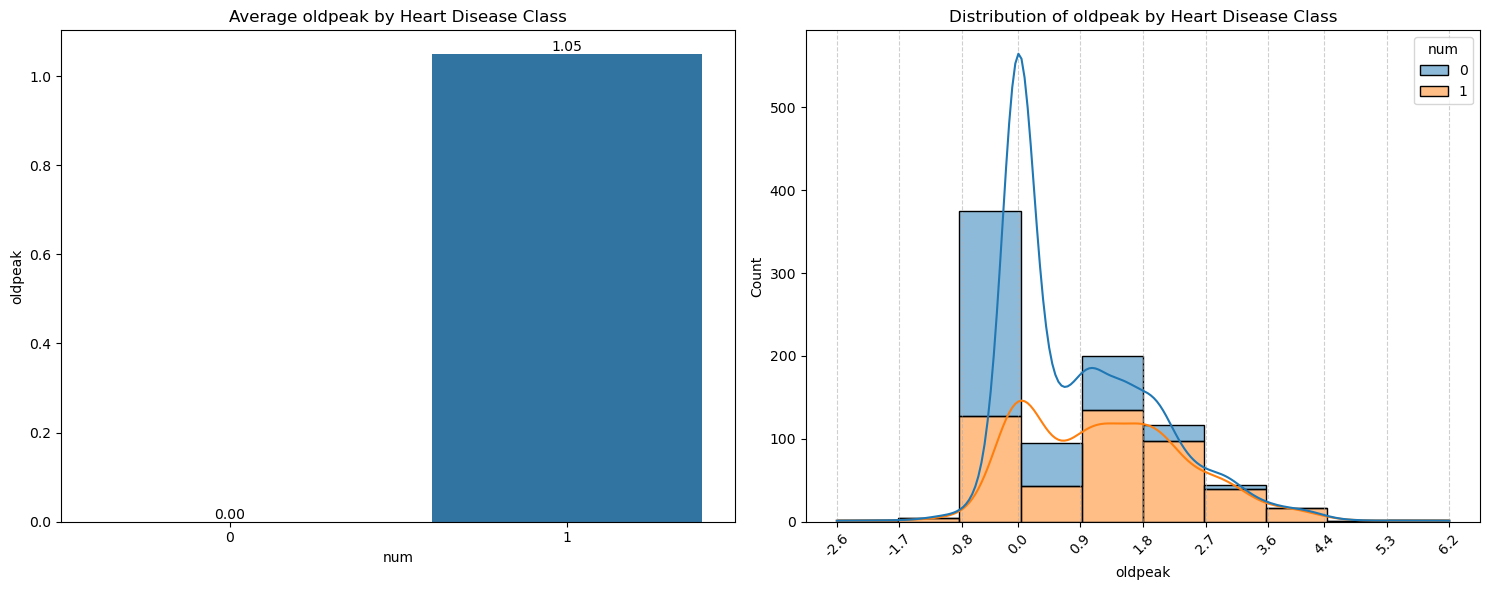

In [70]:

bin_edges = np.histogram_bin_edges(df['oldpeak'].dropna(), bins=10)

fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(15, 6))
#Bar PLot
graph = sns.barplot(data=df, x="num", y="oldpeak", estimator=np.median, errorbar=None, ax=ax[0])
graph.bar_label(graph.containers[0], fmt='%.2f')  # Add value labels
ax[0].set_title('Average oldpeak by Heart Disease Class')

# Histogram + KDE Plot
sns.histplot(data=df, x='oldpeak', kde=True, hue='num', multiple='stack', fill=True, bins=bin_edges, ax=ax[1])
ax[1].set_xticks(np.round(bin_edges, 1))
ax[1].set_xticklabels(np.round(bin_edges, 1), rotation=45)
ax[1].grid(axis='x', linestyle='--', alpha=0.6)
ax[1].set_title('Distribution of oldpeak by Heart Disease Class')

plt.tight_layout()
plt.show()


### ST Depression (oldpeak) vs Heart Disease

### Average Oldpeak by Heart Disease Status
- **No heart disease (num = 0):** Average oldpeak is **close to 0**, reflecting minimal or no ST depression during exercise.  
- **Heart disease (num = 1):** Average oldpeak = **1.05**, showing noticeably higher levels of exercise-induced ST depression.  

**Insight:**  
Patients with heart disease tend to experience **greater depression of the ST segment**, a classic marker of myocardial ischemia under stress. This suggests that the diseased heart struggles to maintain adequate blood supply during exertion.  

---

### Distribution of Oldpeak by Heart Disease Status
- **No heart disease (blue line):** Most individuals cluster tightly around **0**, with occasional negative values (ST elevation), implying minimal or absent depression.  
- **Heart disease (orange line):** A clear peak occurs above **1.0**, with a wider distribution extending to higher values, representing more severe exercise-induced depression.  

**Insight:**  
The heart disease group demonstrates both a **shift toward higher oldpeak values** and **greater variability**. Higher ST depression values (>2.0) indicate **significant myocardial ischemia**, while the non-disease group remains concentrated near 0. This separation underscores oldpeak as a **clinically powerful differentiator** between diseased and non-diseased patients.  

---

### Conclusion
- **Oldpeak values are substantially higher in patients with heart disease**, making this one of the more **discriminative features** in the dataset compared to blood pressure or cholesterol.  
- The larger spread in the heart disease group suggests varying severity of underlying dysfunction — from mild ischemia to severe blockages.  
- Clinically, **exercise-induced ST depression** is a cornerstone diagnostic marker in **stress testing**, and this dataset aligns with real-world cardiology findings.  


## Gender(sex) vs Heart Disease(num)

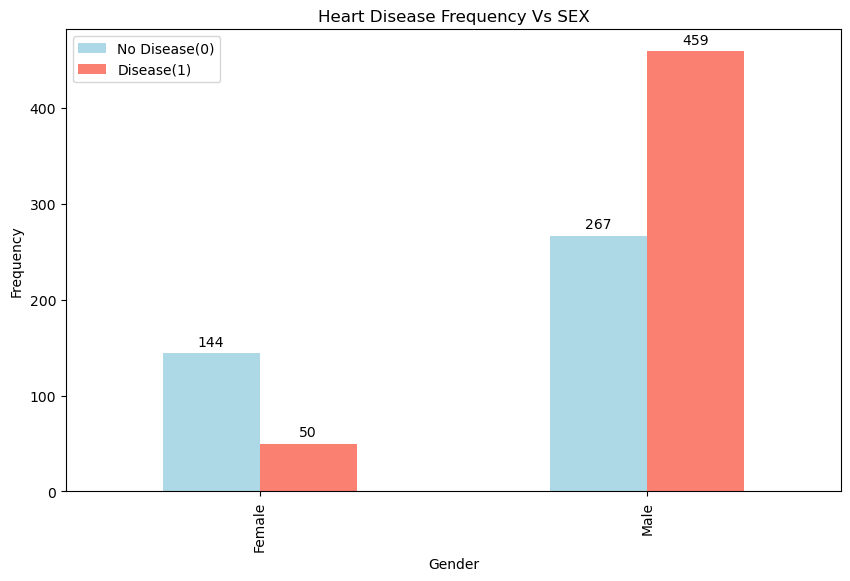

In [71]:
ax = pd.crosstab(df.sex, df.num).plot(kind="bar", 
                                   figsize=(10,6), 
                                   color=["lightblue", "salmon"])

for container in ax.containers:
    ax.bar_label(container, label_type='edge', padding=3, fontsize=10)
plt.title("Heart Disease Frequency Vs SEX")
plt.xlabel("Gender")
plt.ylabel("Frequency")
plt.legend(["No Disease(0)", "Disease(1)"])

### Gender Distribution and Heart Disease

### Gender Breakdown
- **Females:**  
  - With heart disease: **50**  
  - Without heart disease: **144**  

- **Males:**  
  - With heart disease: **459**  
  - Without heart disease: **267**  

---

### Overall Trend
- **Males are disproportionately affected**: The number of male patients with heart disease (**459**) is much higher than those without (**267**).  
- For females, the opposite pattern is observed: the majority are without heart disease (**144**) compared to those with it (**50**).  

---

### Disease vs. No Disease Proportions
- In **both genders**, the absolute number of individuals without heart disease is higher than those with it.  
- However, the difference is **much larger in females**, suggesting they are less likely to present with heart disease in this dataset.  
- Among males, the relationship is reversed, with more cases of heart disease than no disease.  

---

### Clinical Context
- This pattern reflects broader epidemiological evidence: **men are at higher risk for developing coronary artery disease at earlier ages**, while **women’s risk increases after menopause** due to the loss of estrogen’s protective effect on the cardiovascular system.  
- The **lower prevalence in females** within the dataset may also reflect sampling issues, as women are historically **underrepresented in cardiac studies**.  

---

### Key Takeaway
- **Men appear to have higher rates of heart disease than women in this dataset**, matching clinical evidence.  
- Gender should be considered as an important feature in prediction models, but it should not be analyzed in isolation — as biological, hormonal, and lifestyle factors all contribute to cardiovascular outcomes.  


### Fasting Blood Sugar(fbs) VS Heart Disease (num)

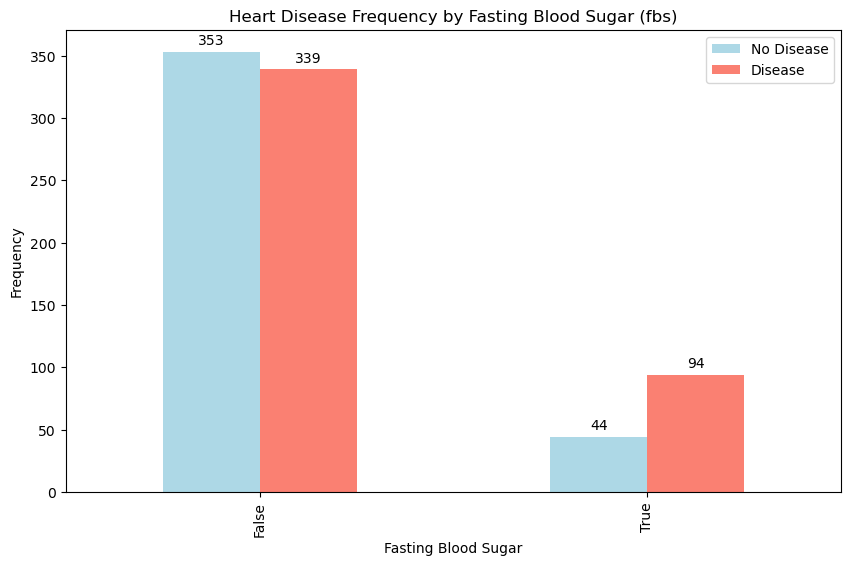

In [72]:
ax = pd.crosstab( df.fbs , df.num ).plot(kind="bar", 
                                   figsize=(10,6), 
                                   color=["lightblue", "salmon"])

for container in ax.containers:
    ax.bar_label(container, label_type='edge', padding=3, fontsize=10)
# Add attributes to the plot to make it more readable
plt.title("Heart Disease Frequency by Fasting Blood Sugar (fbs)")
plt.xlabel("Fasting Blood Sugar")
plt.ylabel("Frequency")
plt.legend(["No Disease", "Disease"])


### Fasting Blood Sugar (fbs) and Heart Disease

### Breakdown by FBS Status
- **FBS = False (Normal/Low Blood Sugar ≤ 120 mg/dL):**  
  - No heart disease: **353 cases**  
  - Heart disease: **339 cases**  
  - **Insight:** The distribution is relatively balanced, but a considerable number with normal fasting sugar still develop heart disease. This suggests that while blood sugar is important, other risk factors also play a critical role.  

- **FBS = True (High Blood Sugar > 120 mg/dL):**  
  - No heart disease: **44 cases**  
  - Heart disease: **94 cases**  
  - **Insight:** In this group, almost **70% of individuals have heart disease**, showing a clear association between elevated fasting blood sugar and cardiovascular risk.  

---

### Overall Trend
- Patients with **high fasting blood sugar (FBS = True)** are **more likely to have heart disease** compared to those with normal levels.  
- Even within the normal FBS group, a large portion still shows heart disease, reinforcing that **FBS alone is not a definitive predictor**, but it remains an important **supporting risk factor**.  

---

### Clinical Context
- Elevated fasting blood sugar is a hallmark of **diabetes mellitus**, which is a well-known and powerful risk factor for **coronary artery disease**.  
- High blood glucose leads to **vascular damage through glycation, inflammation, and oxidative stress**, contributing to plaque buildup and arterial blockages.  
- This dataset mirrors real-world findings: **diabetic patients are at substantially higher risk of cardiovascular disease**, which explains the much higher prevalence of heart disease when FBS is true.  

---

### Key Takeaway
- **High fasting blood sugar is strongly associated with heart disease** in this dataset.  
- However, since many patients with normal fasting glucose also develop heart disease, it is best used **in combination with other features (age, blood pressure, cholesterol, oldpeak, chest pain type, etc.)** for accurate risk prediction.  


## Rest ECG(restecg) VS Heart Disease(num)

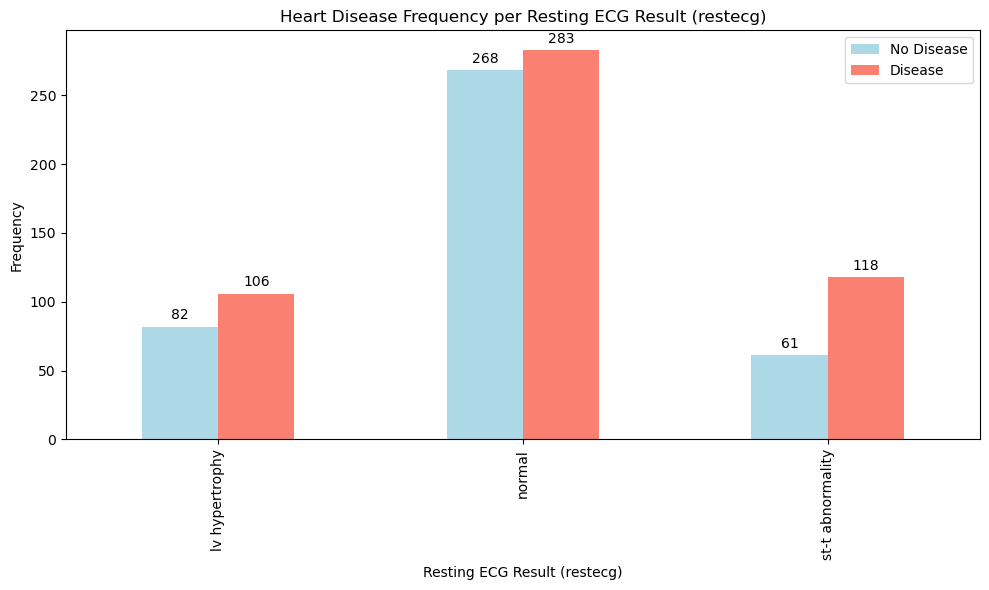

In [73]:
ax = pd.crosstab(df.restecg, df.num).plot(kind="bar",figsize=(10,6) , color=["lightblue", "salmon"])

for container in ax.containers:
    ax.bar_label(container, label_type='edge', padding=3, fontsize=10)


plt.title("Heart Disease Frequency per Resting ECG Result (restecg)")
plt.xlabel("Resting ECG Result (restecg)")
plt.ylabel("Frequency")
plt.legend(["No Disease", "Disease"])

plt.tight_layout()
plt.show()


### Resting ECG (restecg) and Heart Disease

### Resting ECG: Normal
- **No heart disease:** 268 individuals  
- **Heart disease:** 283 individuals  
- **Insight:**  
  Normal ECG results are the most common in the dataset. However, the number of heart disease cases is still high, showing that a "normal" ECG **does not rule out heart disease**. This aligns with clinical practice, since many patients can have underlying coronary disease without resting ECG abnormalities.  

---

### Resting ECG: Left Ventricular Hypertrophy (LVH)
- **No heart disease:** 82 individuals  
- **Heart disease:** 106 individuals  
- **Insight:**  
  The distribution here shows a **greater proportion of heart disease** compared to the normal ECG group. LV hypertrophy often reflects long-term **hypertension or increased cardiac workload**, both of which are important contributors to heart disease.  

---

### Resting ECG: ST Abnormality
- **No heart disease:** 61 individuals  
- **Heart disease:** 118 individuals  
- **Insight:**  
  ST abnormalities are strongly associated with heart disease. In this group, the number of heart disease cases is nearly **double** the non-disease cases. Such ST segment changes are frequently linked to **myocardial ischemia or previous infarction**, which explains their strong connection with diagnosed heart disease.  

---

### Conclusion
- **Normal ECG:** Most common, but heart disease prevalence remains high, demonstrating its **limited diagnostic power alone**.  
- **LV Hypertrophy:** Associated with a **higher proportion of heart disease**, consistent with its link to chronic hypertension.  
- **ST Abnormalities:** Show the **strongest association** with heart disease, nearly doubling the frequency compared to those without disease.  
- Overall, abnormal ECG findings (LVH and ST abnormalities) act as **important risk indicators**, but even “normal” results need to be interpreted with caution, as ECG alone cannot definitively rule out heart disease.  


## Chest Pain(cp) VS Heart Disease(num)

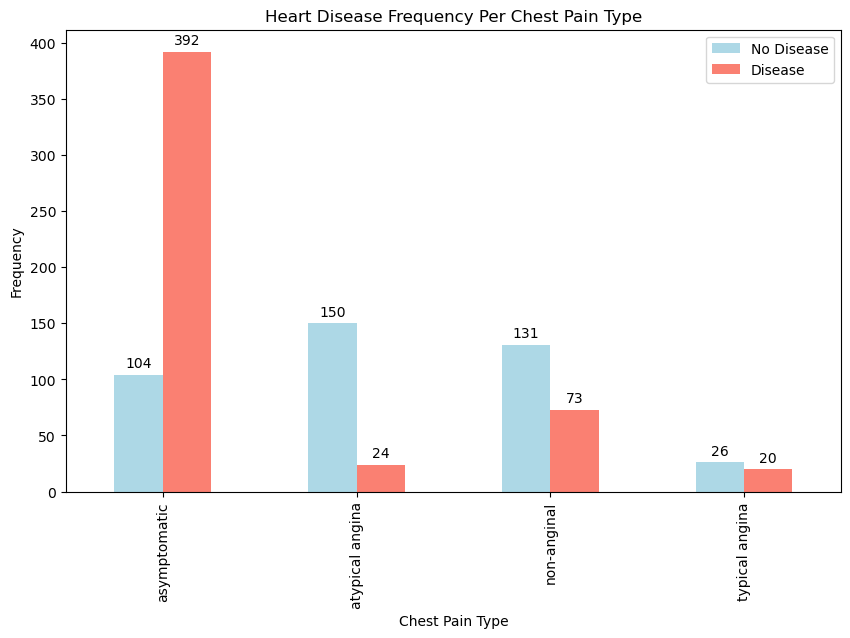

In [74]:
ax = pd.crosstab(df.cp, df.num).plot(kind="bar", 
                                   figsize=(10,6), 
                                   color=["lightblue", "salmon"])

for container in ax.containers:
    ax.bar_label(container, label_type='edge', padding=3, fontsize=10)

plt.title("Heart Disease Frequency Per Chest Pain Type")
plt.xlabel("Chest Pain Type")
plt.ylabel("Frequency")
plt.legend(["No Disease", "Disease"])
plt.show()

### Chest Pain Type (cp) and Heart Disease

### Distribution by Chest Pain Category

1. **Asymptomatic**
   - No heart disease: **392 cases**
   - Heart disease: **104 cases**
   - **Insight:**  
     This is the most common category overall. Most individuals reporting asymptomatic chest pain do **not** have heart disease, showing that chest pain does not always correlate with cardiac pathology. However, the presence of 104 disease cases means asymptomatic individuals cannot be dismissed without further evaluation.  

2. **Atypical Angina**
   - No heart disease: **150 cases**
   - Heart disease: **24 cases**
   - **Insight:**  
     Atypical angina is more commonly seen in those without disease. Clinically, this type of pain often has **non-cardiac origins**, but some association with heart disease remains, reflecting the **diagnostic ambiguity** of atypical symptoms.  

3. **Non-Anginal Chest Pain**
   - No heart disease: **131 cases**
   - Heart disease: **73 cases**
   - **Insight:**  
     Non-anginal chest pain is more frequent among those without disease, but the presence of 73 disease cases shows a **moderate relationship** to heart disease. This emphasizes the need for further tests, as non-anginal pain cannot rule out cardiovascular conditions.  

4. **Typical Angina**
   - No heart disease: **26 cases**
   - Heart disease: **20 cases**
   - **Insight:**  
     Despite being the least frequent category, typical angina shows the **strongest relative association** with heart disease. This aligns with clinical evidence: **classic angina (exertional, pressure-like pain, relieved by rest/nitroglycerin)** is the most predictive chest pain pattern for coronary artery disease.  

---

### Integrated Conclusion
- **Asymptomatic chest pain** is most common, but not strongly tied to disease.  
- **Typical angina**, although less frequent, shows a clear and predictable association with heart disease.  
- **Atypical angina** and **non-anginal chest pain** occur in many patients without disease, but their overlap with diseased cases highlights why **symptom-based diagnosis alone is unreliable**.  
 


## Exercise-Induced Angina (exang) VS Heart Disease

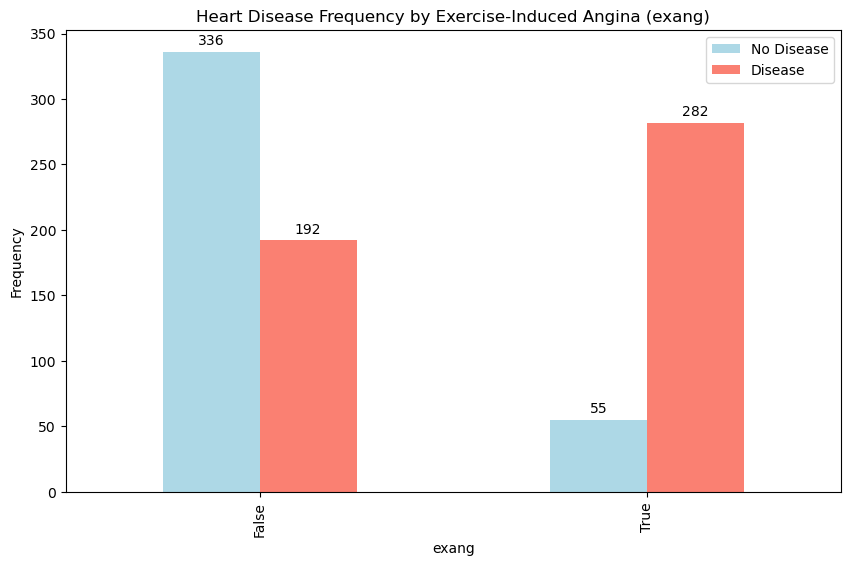

In [75]:
ax = pd.crosstab(df.exang, df.num).plot(kind="bar", 
                                       figsize=(10,6), 
                                       color=["lightblue", "salmon"])

for container in ax.containers:
    ax.bar_label(container, label_type='edge', padding=3, fontsize=10)

# Correct title and axis labels
plt.title("Heart Disease Frequency by Exercise-Induced Angina (exang)")
plt.xlabel("exang")
plt.ylabel("Frequency")
plt.legend(["No Disease", "Disease"])
plt.show()


## Exercise-Induced Angina (exang) and Heart Disease

### Distribution by Exang Status

1. **Exang = True (Angina during exercise)**
   - No heart disease: **55 cases**  
   - Heart disease: **282 cases**  
   - **Insight:**  
     The majority of individuals who experience **exercise-induced angina** also have heart disease. This strong association reflects clinical practice, where angina triggered by exertion is a **classic symptom of coronary artery disease (CAD)**.  

2. **Exang = False (No angina during exercise)**
   - No heart disease: **336 cases**  
   - Heart disease: **192 cases**  
   - **Insight:**  
     Most individuals without exercise-induced angina are free from heart disease. However, nearly **200 diseased cases still exist in this group**, showing that absence of exercise angina does **not guarantee a healthy heart**, as some patients may have “silent” ischemia or alternative cardiac presentations.  

---

### Conclusion
- **Exercise-induced angina (True)** is strongly linked to heart disease, making it a reliable **positive predictor** of cardiovascular risk.  
- **No angina (False)** is common in healthy individuals, but the occurrence of disease cases within this group confirms that **angina alone cannot fully classify heart disease status**.  
- Clinically, this reflects the importance of using **exercise stress testing in diagnosis**, while still considering other diagnostic features (ECG changes, cholesterol, oldpeak, etc.).  




##  Slope of Peak Exercise ST Segment(slope) VS Heart Disease 

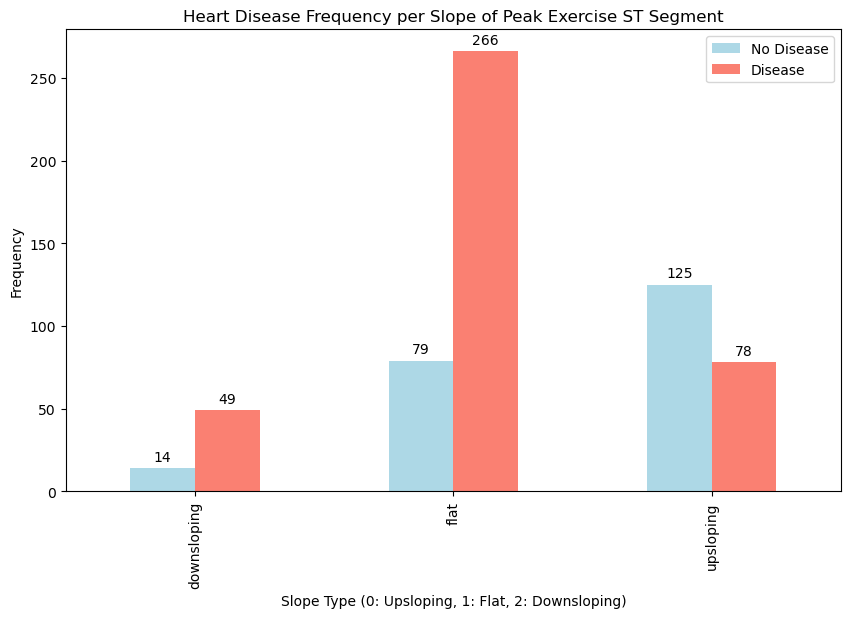

In [76]:
ax = pd.crosstab(df.slope, df.num).plot(kind="bar", 
                                       figsize=(10,6), 
                                       color=["lightblue", "salmon"])

# Attach values to the bars
for container in ax.containers:
    ax.bar_label(container, label_type='edge', padding=3, fontsize=10)

# Proper plot title and axis labels
plt.title("Heart Disease Frequency per Slope of Peak Exercise ST Segment")
plt.xlabel("Slope Type (0: Upsloping, 1: Flat, 2: Downsloping)")
plt.ylabel("Frequency")
plt.legend(["No Disease", "Disease"])
plt.show()


### ST Segment Slope (slope) and Heart Disease

### Distribution by Slope Type

1. **Flat Slope (Type 1)**
   - No heart disease: **79 cases**  
   - Heart disease: **266 cases**  
   - **Insight:**  
     The flat slope group has the **highest frequency of heart disease**. This pattern is often linked to **myocardial ischemia** and reduced oxygen supply to the heart during exercise. The strong imbalance shows its importance as a risk indicator.  

2. **Upsloping Slope (Type 0)**
   - No heart disease: **125 cases**  
   - Heart disease: **78 cases**  
   - **Insight:**  
     Upsloping slopes are more common in individuals **without heart disease**. Clinically, an upsloping ST segment during exercise testing is generally considered a **normal response**, explaining its weaker association with disease.  

3. **Downsloping Slope (Type 2)**
   - No heart disease: **14 cases**  
   - Heart disease: **49 cases**  
   - **Insight:**  
     Although less frequent overall, the **ratio of diseased to non-diseased is very high** in this group. Downsloping ST segments are strongly linked with **exercise-induced ischemia** and are considered **highly abnormal** in cardiology, often leading to concern for significant coronary artery disease.  

---

### Conclusion
- **Flat slope**: Most strongly associated with heart disease by absolute numbers.  
- **Downsloping slope**: Smaller group but very strong predictor, since the majority have heart disease.  
- **Upsloping slope**: Appears more often in healthy patients and is generally considered a **benign exercise response**.  

**Key Message:**  
ST segment slope provides useful diagnostic information. Both **flat** and **downsloping slopes** are important ECG indicators of ischemia and heart disease risk, while **upsloping slopes** are more consistent with healthy hearts. In predictive modeling, slope is therefore a **highly discriminative feature**.  


## Number of Major Vessels Colored(ca) VS Heart Disease 

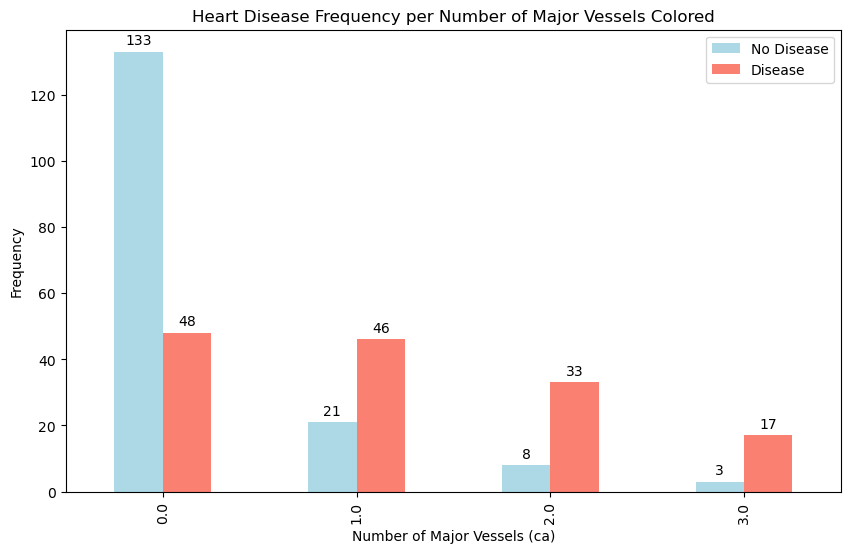

In [77]:
ax = pd.crosstab(df.ca, df.num).plot(kind="bar", 
                                     figsize=(10,6), 
                                     color=["lightblue", "salmon"])

for container in ax.containers:
    ax.bar_label(container, label_type='edge', padding=3, fontsize=10)

# Correct plot attributes
plt.title("Heart Disease Frequency per Number of Major Vessels Colored")
plt.xlabel("Number of Major Vessels (ca)")
plt.ylabel("Frequency")
plt.legend(["No Disease", "Disease"])
plt.show()


### Number of Major Vessels (ca) and Heart Disease

### No Disease (Light Blue)
- **0 vessels:** 133 individuals without disease (highest frequency in this group).  
- As the number of vessels increases, **the frequency of no disease cases decreases**:  
  - 1 vessel: fewer non-disease cases  
  - 2 vessels: even fewer  
  - 3 vessels: only **3 cases without disease**.  

**Insight:** Having **no major vessels affected** is strongly associated with the absence of heart disease. As blockages increase, the likelihood of being disease-free sharply declines.  

---

### Heart Disease (Red)
- **0 vessels:** 48 disease cases present despite no major vessels colored.  
- **1 vessel:** 46 disease cases.  
- **2 vessels:** 33 disease cases.  
- **3 vessels:** 17 disease cases.  

**Insight:** Heart disease becomes **more common once vessels are affected**. The presence of 1 or more colored (blocked) vessels indicates substantial disease likelihood. Interestingly, there are still disease cases in the **0 vessels group**, which may reflect other mechanisms of heart disease (e.g., microvascular disease not visible in angiography).  

---

### Interpretation
- The **0 vessels group** contains many without disease, but also a noticeable number of disease patients, showing that heart disease is not always explained by major vessel blockage alone.  
- As the **number of vessels increases**, disease cases make up a larger proportion, and **non-disease cases nearly disappear**, especially at **3 vessels**.  
- The apparent drop in disease frequency at higher vessel counts (e.g., 3 vessels) likely reflects **smaller sample size** rather than lower risk. In clinical cardiology, 2–3 blocked vessels usually indicate **severe coronary artery disease** with very high risk.  

---

### Key Message
- **0 vessels:** Most are healthy, but some still have disease → may be due to microvascular or early disease.  
- **1–2 vessels:** Clear rise in heart disease prevalence.  
- **3 vessels:** Rare, but strongly associated with severe forms of the condition.  

**Takeaway:** The number of colored vessels is a **direct measure of disease severity**, with higher values strongly linked to heart disease. This feature is highly predictive and clinically meaningful in assessing cardiovascular risk.  


##  Thalassemia  VS Heart Disease 

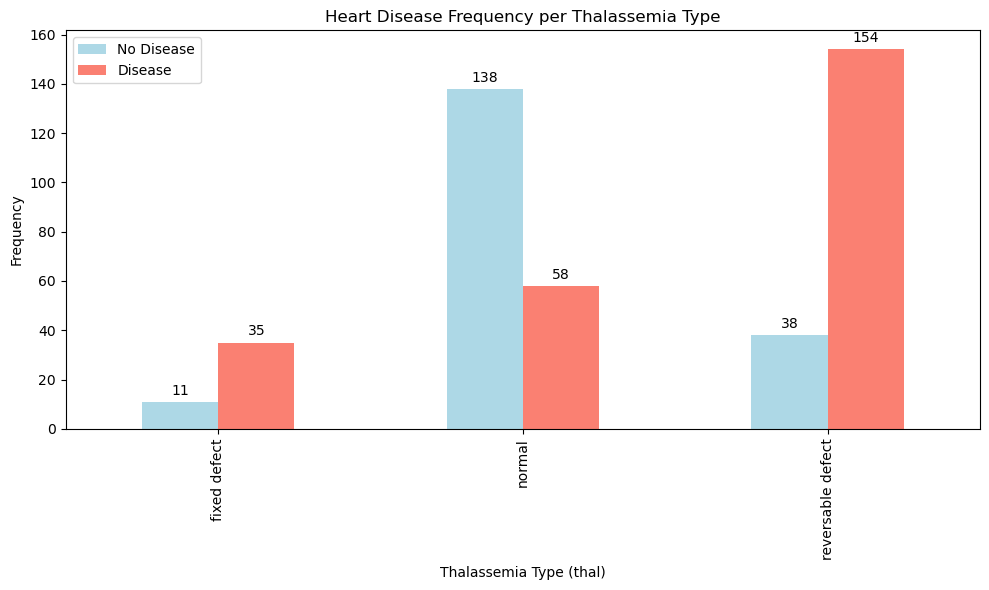

In [78]:
ax = pd.crosstab(df.thal, df.num).plot(kind="bar", 
                                   figsize=(10,6), 
                                   color=["lightblue", "salmon"])

for container in ax.containers:
    ax.bar_label(container, label_type='edge', padding=3, fontsize=10)
plt.title("Heart Disease Frequency per Thalassemia Type")
plt.xlabel("Thalassemia Type (thal)")
plt.ylabel("Frequency")
plt.legend(["No Disease", "Disease"])

plt.tight_layout()
plt.show()


### Thalassemia (thal) and Heart Disease

### Thalassemia Categories
The dataset classifies patients into three categories based on their Thalassemia test results:  
- **Fixed defect**  
- **Normal**  
- **Reversible defect**  

---

### Disease vs. No Disease Distribution
1. **Fixed Defect**
   - No heart disease: **11 cases**
   - Heart disease: **35 cases**
   - **Insight:** More patients with fixed defect have heart disease, although the sample size is relatively small. A fixed defect often reflects **prior myocardial infarction or scar tissue**, which increases cardiovascular risk.  

2. **Normal**
   - No heart disease: **138 cases**
   - Heart disease: **58 cases**
   - **Insight:** The majority of patients with normal results do not have heart disease, consistent with this being the **lowest-risk group**. However, heart disease can still occur due to other risk factors.  

3. **Reversible Defect**
   - No heart disease: **38 cases**
   - Heart disease: **154 cases**
   - **Insight:** This group shows the **highest frequency of heart disease**. A reversible defect indicates abnormal cardiac perfusion during stress testing (ischemia), which is a strong predictor of coronary artery disease.  

---

### Risk Interpretation
- **Reversible defect**: Strongest association with heart disease, signaling **active ischemia** and the need for close monitoring or intervention.  
- **Fixed defect**: Also associated with disease, but less frequent. Represents prior damage rather than ongoing ischemia.  
- **Normal**: Shows the least heart disease prevalence, appearing relatively protective.  

---

### Clinical Implications
- The **reversible defect group is at highest risk** and should be prioritized for **further diagnostic workup and preventive measures**.  
- The **fixed defect group**, though smaller in size, likely represents patients with **previous cardiac injury** and thus warrants ongoing management.  
- The **normal group** has the lowest risk, but still contains some cases of disease, emphasizing that **normal thalassemia results do not eliminate risk entirely**.  

**Key Message:**  
The thalassemia variable strongly differentiates risk levels in this dataset. In particular, **reversible defects are a powerful indicator of heart disease and should be weighted heavily in predictive modeling and clinical assessment.**  


# OUTLIERS

## age

In [79]:
# sns.boxplot(x=df['age'],fliersize=5, flierprops=dict(marker='o', markerfacecolor='red', markersize=5, linestyle='none'))
# plt.grid()

In [80]:
# #Check NUll Values
# df.age.isnull().sum()

## Trestbps

In [81]:
# sns.boxplot(x=df['trestbps'],fliersize=5, flierprops=dict(marker='o', markerfacecolor='red', markersize=5, linestyle='none'))
# plt.grid()

In [82]:
# Q1 = df['trestbps'].quantile(0.25)
# Q3 = df['trestbps'].quantile(0.75)
# IQR = Q3 - Q1

# # Step 2: Calculate lower and upper bounds
# lower_whisker = Q1 - 1.5 * IQR
# upper_whisker = Q3 + 1.5 * IQR

# # Step 3: Filter outliers
# outliers = df[(df['trestbps'] < lower_whisker) | (df['trestbps'] > upper_whisker)]
# outliers.sort_values('trestbps')



In [83]:
# df.trestbps.isnull().sum() 

In [84]:
df_capped = temp_df.copy() # Create a backup of data

In [85]:
# df_capped.loc[df_capped['trestbps'] == 80 ,'trestbps'] = 92


In [86]:
# sns.boxplot(x=df_capped['trestbps'],fliersize=5, flierprops=dict(marker='o', markerfacecolor='red', markersize=5, linestyle='none'))
# plt.grid()

In [87]:
# df['trestbps'].skew()

## chol

In [88]:
# sns.boxplot(x=df['chol'],fliersize=5, flierprops=dict(marker='o', markerfacecolor='red', markersize=5, linestyle='none'))
# plt.grid()

In [89]:
# Q1 = df['chol'].quantile(0.25)
# Q3 = df['chol'].quantile(0.75)
# IQR = Q3 - Q1

# # Step 2: Calculate lower and upper bounds
# lower_whisker = Q1 - 1.5 * IQR
# upper_whisker = Q3 + 1.5 * IQR

# # Step 3: Filter outliers
# outliers = df[(df['chol'] < lower_whisker) | (df['chol'] > upper_whisker)]



In [90]:

# ranges = {
#     'Below 100': df[df['chol'] < 100].shape[0],
#     '100-199': df[(df['chol'] >= 100) & (df['chol'] < 200)].shape[0],
#     '200-299': df[(df['chol'] >= 200) & (df['chol'] < 300)].shape[0],
#     '300-399': df[(df['chol'] >= 300) & (df['chol'] < 400)].shape[0],
#     '400-499': df[(df['chol'] >= 400) & (df['chol'] < 500)].shape[0],
#     '500+': df[df['chol'] >= 500].shape[0],
# }

# for k, v in ranges.items():
#     print(f"{k}: {v} values")


In [91]:
# chol_1 = df['chol'].quantile(0.1)
# chol_1

In [92]:

# chol_99 = df['chol'].quantile(0.99)

# #  Apply capping to the new dataset only
# df_capped['chol'] = df_capped['chol'].apply(lambda x: chol_99 if x > chol_99 else x)
# df_capped['chol'] = df_capped['chol'].apply(lambda x:   lower_whisker if x < lower_whisker else x)
# sns.boxplot(x=df_capped['chol'],fliersize=5, flierprops=dict(marker='o', markerfacecolor='red', markersize=5, linestyle='none'))
# plt.grid()

In [93]:
# sns.boxplot(x='chol', y='sex', data=df_capped, fliersize=5)
# plt.grid()


In [94]:
# sns.kdeplot(df['chol'], label='Original chol', color='red')
# sns.kdeplot(df_capped['chol'], label='Capped Chol', color='lightgreen')

# plt.legend()
# plt.xlabel('chol')
# plt.ylabel('Density')
# plt.title('KDE Comparison: Original vs Capped chol')

In [95]:
# sns.histplot(df_capped['chol'],kde = True,label = 'Capped Chol')
# plt.legend()

In [96]:
# print("Capped Data Mean :" ,df_capped['chol'].mean())
# print("Capped Data Median:" ,df_capped['chol'].median())
# print("Original Data Mean :" ,df['chol'].mean())
# print("Original Data Median :" ,df['chol'].median())

In [97]:
# df_capped['chol'].skew()

# Thalch

In [98]:
# sns.boxplot(x=df['thalch'],fliersize=5, flierprops=dict(marker='o', markerfacecolor='red', markersize=5, linestyle='none'))
# plt.grid()

In [99]:
# Q1 = df['thalch'].quantile(0.25)
# Q3 = df['thalch'].quantile(0.75)
# IQR = Q3 - Q1

# # Step 2: Calculate lower and upper bounds
# lower_whisker = Q1 - 1.5 * IQR
# upper_whisker = Q3 + 1.5 * IQR

# # Step 3: Filter outliers
# outliers = df[(df['thalch'] < lower_whisker) | (df['thalch'] > upper_whisker)]



In [100]:
# sns.boxplot(x=df_capped['thalch'],fliersize=5, flierprops=dict(marker='o', markerfacecolor='red', markersize=5, linestyle='none'))
# plt.grid()

In [101]:
# thalch_1 = df['thalch'].quantile(0.01)
# df_capped['thalch'] = df['thalch'].apply(lambda x: thalch_1 if x < thalch_1 else x)

In [102]:
# plt.figure(figsize=(10, 6))

# # KDE plots with labels
# sns.kdeplot(df['thalch'], label='Original thalch', color='red')
# sns.kdeplot(df_capped['thalch'], label='Capped thalch', color='green')

# # Add legend and labels
# plt.legend()
# plt.xlabel('thalch')
# plt.ylabel('Density')
# plt.title('KDE Comparison: Original vs Capped thalch')

In [103]:
# sns.boxplot(x=df['oldpeak'],fliersize=5, flierprops=dict(marker='o', markerfacecolor='red', markersize=5, linestyle='none'))
# plt.grid()

In [104]:
# df.oldpeak.isnull().sum()

In [105]:
# Q1 = df['oldpeak'].quantile(0.25)
# Q3 = df['oldpeak'].quantile(0.75)
# IQR = Q3 - Q1

# # Step 2: Calculate lower and upper bounds
# lower_whisker = Q1 - 1.5 * IQR
# upper_whisker = Q3 + 1.5 * IQR

# q1 = df_capped['oldpeak'].quantile(0.01)
# q99 = df_capped['oldpeak'].quantile(0.99)
# # Step 3: Filter outliers
# outliers = df[(df['oldpeak'] < lower_whisker) | (df['oldpeak'] > upper_whisker)]
# # outliers.sort_values('oldpeak').drop(columns = ['id','dataset'])
# # df_capped['oldpeak'] = df_capped['oldpeak'].clip(lower=q1, upper=q99)

# # Show the result
# df_capped['oldpeak'].describe()


In [106]:
# sns.kdeplot(df['oldpeak'],label = "Orginal Oldpeak",color = "Red")
# sns.kdeplot(df_capped['oldpeak'] , label = "Capped Oldpeak",color = "Green")
# plt.legend()


In [107]:
# sns.boxplot(x=df_capped['oldpeak'],fliersize=5, flierprops=dict(marker='o', markerfacecolor='red', markersize=5, linestyle='none'))
# plt.grid()

In [108]:
# print("Capped Data Mean :" ,round(df_capped['oldpeak'].mean(),2))
# print("Capped Data Median:" ,df_capped['oldpeak'].median())
# print("Original Data Mean :" ,round(df['oldpeak'].mean(),2))
# print("Original Data Median :" ,df['oldpeak'].median())

In [109]:
# df['oldpeak'].skew()

In [110]:
# df_capped['oldpeak'].skew()

In [111]:
# Save the capped dataset to CSV
df_capped.to_csv("heart_cleaned.csv", index=False)


In [112]:
df_capped.describe()

,id,age,trestbps,chol,thalch,oldpeak,ca,num
count,920.000000,920.000000,860.000000,718.000000,865.000000,858.000000,309.000000,920.000000
mean,460.500000,53.510870,132.286047,246.832869,137.545665,0.878788,0.676375,0.553261
std,265.725422,9.424685,18.536175,58.527062,25.926276,1.091226,0.935653,0.497426
min,1.000000,28.000000,80.000000,85.000000,60.000000,-2.600000,0.000000,0.000000
25%,230.750000,47.000000,120.000000,210.000000,120.000000,0.000000,0.000000,0.000000
50%,460.500000,54.000000,130.000000,239.500000,140.000000,0.500000,0.000000,1.000000
75%,690.250000,60.000000,140.000000,276.750000,157.000000,1.500000,1.000000,1.000000
max,920.000000,77.000000,200.000000,603.000000,202.000000,6.200000,3.000000,1.000000


### Data Splitting: Training and Testing Sets

In [113]:
X = df_capped.drop('num',axis = 1)
y = df_capped['num']
X_train,X_test , y_train , y_test = train_test_split(X,y,test_size = 0.2 , random_state = 42 )


In [114]:
X_train

,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal
880,881,62,Male,VA Long Beach,asymptomatic,NaN,170.0,False,st-t abnormality,120.0,True,3.0,NaN,NaN,NaN
457,458,54,Male,Hungary,non-anginal,150.0,NaN,False,normal,122.0,False,0.0,NaN,NaN,NaN
797,798,51,Male,VA Long Beach,non-anginal,NaN,339.0,False,normal,NaN,NaN,NaN,NaN,NaN,NaN
25,26,50,Female,Cleveland,non-anginal,120.0,219.0,False,normal,158.0,False,1.6,flat,0.0,normal
84,85,52,Male,Cleveland,atypical angina,120.0,325.0,False,normal,172.0,False,0.2,upsloping,0.0,normal
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
106,107,59,Male,Cleveland,asymptomatic,140.0,177.0,False,normal,162.0,True,0.0,upsloping,1.0,reversable defect
270,271,61,Male,Cleveland,asymptomatic,140.0,207.0,False,lv hypertrophy,138.0,True,1.9,upsloping,1.0,reversable defect
860,861,75,Male,VA Long Beach,asymptomatic,160.0,310.0,True,normal,112.0,True,2.0,downsloping,NaN,reversable defect
435,436,53,Female,Hungary,atypical angina,140.0,216.0,False,normal,142.0,True,2.0,flat,NaN,NaN


In [115]:
X_train

,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal
880,881,62,Male,VA Long Beach,asymptomatic,NaN,170.0,False,st-t abnormality,120.0,True,3.0,NaN,NaN,NaN
457,458,54,Male,Hungary,non-anginal,150.0,NaN,False,normal,122.0,False,0.0,NaN,NaN,NaN
797,798,51,Male,VA Long Beach,non-anginal,NaN,339.0,False,normal,NaN,NaN,NaN,NaN,NaN,NaN
25,26,50,Female,Cleveland,non-anginal,120.0,219.0,False,normal,158.0,False,1.6,flat,0.0,normal
84,85,52,Male,Cleveland,atypical angina,120.0,325.0,False,normal,172.0,False,0.2,upsloping,0.0,normal
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
106,107,59,Male,Cleveland,asymptomatic,140.0,177.0,False,normal,162.0,True,0.0,upsloping,1.0,reversable defect
270,271,61,Male,Cleveland,asymptomatic,140.0,207.0,False,lv hypertrophy,138.0,True,1.9,upsloping,1.0,reversable defect
860,861,75,Male,VA Long Beach,asymptomatic,160.0,310.0,True,normal,112.0,True,2.0,downsloping,NaN,reversable defect
435,436,53,Female,Hungary,atypical angina,140.0,216.0,False,normal,142.0,True,2.0,flat,NaN,NaN


In [116]:
y_train

880    1
457    0
797    1
25     0
84     0
      ..
106    1
270    1
860    0
435    0
102    0
Name: num, Length: 736, dtype: int64

In [117]:
y_test

319    0
377    0
538    1
296    1
531    1
      ..
382    0
97     1
906    1
467    0
732    1
Name: num, Length: 184, dtype: int64

In [118]:
#Checking balance of target classes in test set .
y_train.value_counts()*100/len(y_train)

num
1    54.347826
0    45.652174
Name: count, dtype: float64

In [119]:
#Checking Missing Values in X_train
X_train.isnull().sum()*100/(len(X_train))

id           0.000000
age          0.000000
sex          0.000000
dataset      0.000000
cp           0.000000
trestbps     6.250000
chol        22.282609
fbs         10.869565
restecg      0.135870
thalch       5.706522
exang        5.706522
oldpeak      6.114130
slope       32.336957
ca          66.032609
thal        52.989130
dtype: float64



---
## Missing Value Imputation Strategy and Rationale

In this project, missing values were imputed based on exploratory data analysis and clinical context, with the goal to preserve data integrity and maintain meaningful variable distributions.

- **trestbps (missing ~6.25%)**  
  **Strategy:** KNN imputer.  
  **Reason:** Blood pressure values have a near-normal distribution but contain outliers such as hypertensive crisis cases. KNN imputation uses similarity between instances, preserving underlying patterns better than simple statistics.

- **chol (missing ~22.28%)**  
  **Strategy:** Iterative imputer.  
  **Reason:** Cholesterol has a right-skewed distribution with many outliers. The iterative imputer models relationships with other features, providing more accurate imputations that respect complex dependencies.

- **fbs (missing ~10.87%)**  
  **Strategy:** SimpleImputer with mode.  
  **Reason:** Binary categorical variable for fasting blood sugar; mode imputation is natural to maintain the dominant category and distribution.

- **restecg (missing ~0.14%)**  
  **Strategy:** SimpleImputer with mode.  
  **Reason:** Categorical ECG results, very few missing values; mode imputation efficiently fills missingness while retaining category proportions.

- **thalch (missing ~5.71%)**  
  **Strategy:** KNN imputer.  
  **Reason:** Maximum heart rate is continuous with slight skew. KNN imputation uses neighbor similarity to estimate missing values more realistically than basic statistical methods.

- **exang (missing ~5.71%)**  
  **Strategy:** SimpleImputer with mode.  
  **Reason:** Binary exercise angina indicator; mode imputation maintains class balance and interpretability.

- **oldpeak (missing ~6.11%)**  
  **Strategy:** KNN imputer.  
  **Reason:** Continuous with right skew, representing ST depression. KNN imputes based on similar patients, preserving nuanced clinical patterns.

- **slope (missing ~32.34%)**  
  **Strategy:** SimpleImputer with mode.  
  **Reason:** Categorical with high missingness; filling with the most frequent slope retains dominant patterns while avoiding artificial bias.

- **ca (missing ~66.03%)**  
  **Strategy:** Impute with missing indicator + mode imputation.  
  **Reason:** Very high missingness; the missingness itself may convey clinical information. Creating a missing indicator preserves this signal while mode imputation fills values.

- **thal (missing ~52.99%)**  
  **Strategy:** Impute with missing indicator + mode imputation.  
  **Reason:** Similar to 'ca', high missingness and test absence can be informative. Missing indicators help models leverage this information.

---



In [120]:
X_train

,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal
880,881,62,Male,VA Long Beach,asymptomatic,NaN,170.0,False,st-t abnormality,120.0,True,3.0,NaN,NaN,NaN
457,458,54,Male,Hungary,non-anginal,150.0,NaN,False,normal,122.0,False,0.0,NaN,NaN,NaN
797,798,51,Male,VA Long Beach,non-anginal,NaN,339.0,False,normal,NaN,NaN,NaN,NaN,NaN,NaN
25,26,50,Female,Cleveland,non-anginal,120.0,219.0,False,normal,158.0,False,1.6,flat,0.0,normal
84,85,52,Male,Cleveland,atypical angina,120.0,325.0,False,normal,172.0,False,0.2,upsloping,0.0,normal
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
106,107,59,Male,Cleveland,asymptomatic,140.0,177.0,False,normal,162.0,True,0.0,upsloping,1.0,reversable defect
270,271,61,Male,Cleveland,asymptomatic,140.0,207.0,False,lv hypertrophy,138.0,True,1.9,upsloping,1.0,reversable defect
860,861,75,Male,VA Long Beach,asymptomatic,160.0,310.0,True,normal,112.0,True,2.0,downsloping,NaN,reversable defect
435,436,53,Female,Hungary,atypical angina,140.0,216.0,False,normal,142.0,True,2.0,flat,NaN,NaN


### Encoding Categorical Variables + Missing Value Imputation


In [121]:
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer

# Impute missing values in selected categorical columns with most frequent category
cat_imputer = ColumnTransformer(transformers=[
    ("restecg_impute", SimpleImputer(strategy="most_frequent"), ['restecg']),
    ("slope_impute", SimpleImputer(strategy="most_frequent"), ['slope']),
    ("fbs_impute", SimpleImputer(strategy="most_frequent"), ['fbs']),
    ("exang_impute", SimpleImputer(strategy="most_frequent"), ['exang'])
], remainder='passthrough', verbose_feature_names_out=False)

cat_imputer.set_output(transform='pandas')

# Fit on train data and transform train & test categorical columns
X_train_cat_imputed = cat_imputer.fit_transform(X_train)
X_test_cat_imputed = cat_imputer.transform(X_test)


In [122]:
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)


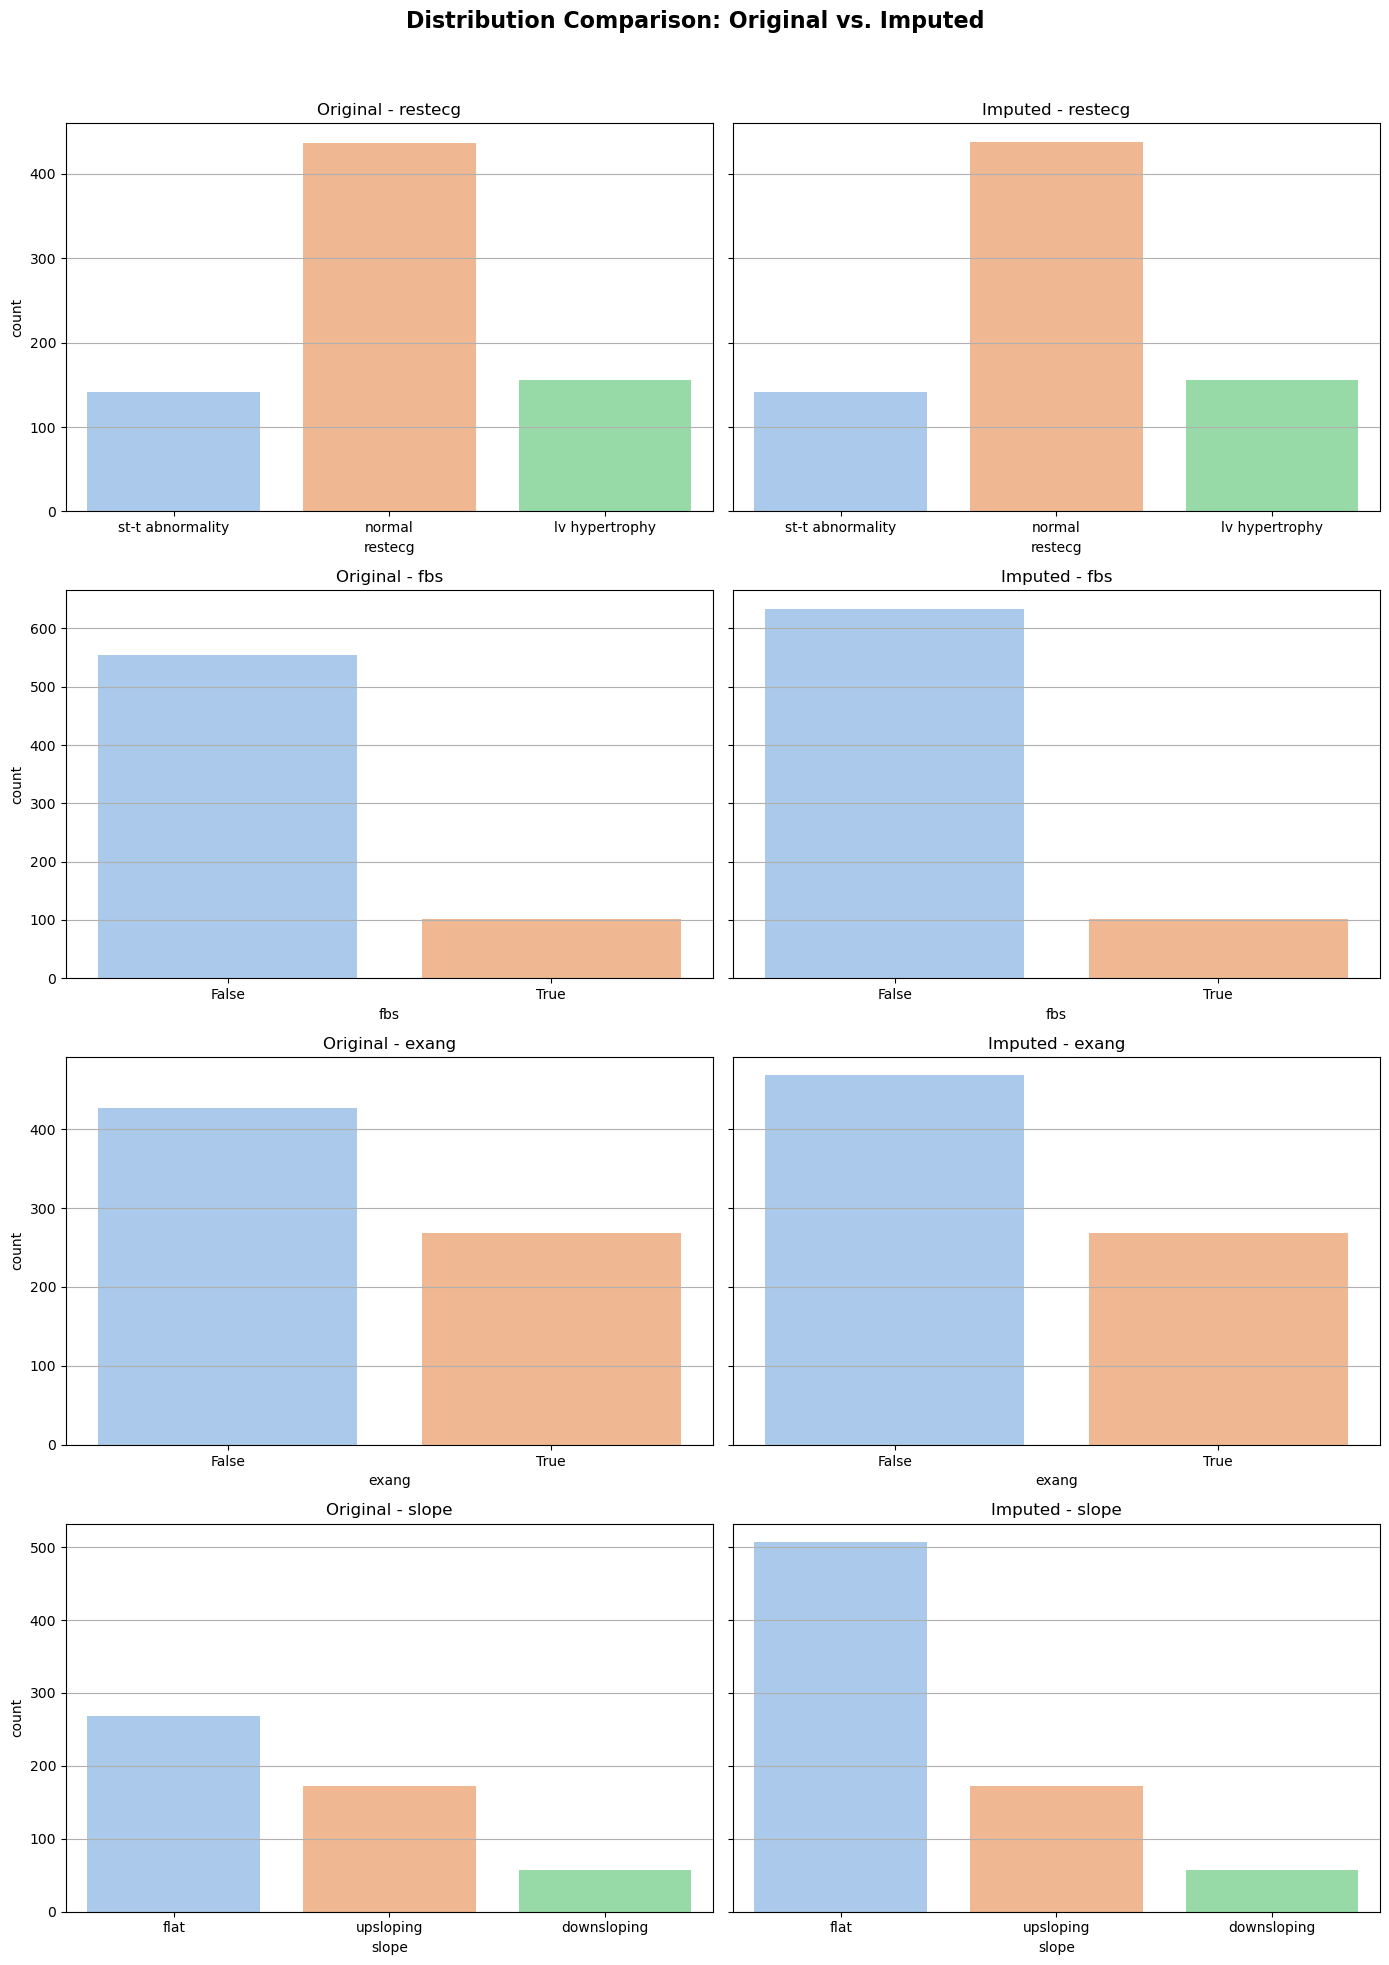

In [123]:

def plot_side_by_side(categories):
    n = len(categories)
    fig, axes = plt.subplots(n, 2, figsize=(14, 5 * n), sharey='row')
    fig.suptitle("Distribution Comparison: Original vs. Imputed", fontsize=16, fontweight='bold')

    for i, category in enumerate(categories):
        # Original data plot
        sns.countplot(data=X_train, x=category, palette='pastel', ax=axes[i, 0])
        axes[i, 0].set_title(f'Original - {category}')
        axes[i, 0].grid(axis='y')

        # Imputed data plot
        sns.countplot(data=X_train_cat_imputed, x=category, palette='pastel', ax=axes[i, 1])
        axes[i, 1].set_title(f'Imputed - {category}')
        axes[i, 1].grid(axis='y')

    plt.tight_layout(rect=[0, 0, 1, 0.96])  # make room for suptitle
    plt.show()

# Call plot function with your categorical columns
categories = ['restecg', 'fbs', 'exang', 'slope']
plot_side_by_side(categories)


In [124]:
X_train_cat_imputed

,restecg,slope,fbs,exang,id,age,sex,dataset,cp,trestbps,chol,thalch,oldpeak,ca,thal
880,st-t abnormality,flat,False,True,881,62,Male,VA Long Beach,asymptomatic,NaN,170.0,120.0,3.0,NaN,NaN
457,normal,flat,False,False,458,54,Male,Hungary,non-anginal,150.0,NaN,122.0,0.0,NaN,NaN
797,normal,flat,False,False,798,51,Male,VA Long Beach,non-anginal,NaN,339.0,NaN,NaN,NaN,NaN
25,normal,flat,False,False,26,50,Female,Cleveland,non-anginal,120.0,219.0,158.0,1.6,0.0,normal
84,normal,upsloping,False,False,85,52,Male,Cleveland,atypical angina,120.0,325.0,172.0,0.2,0.0,normal
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
106,normal,upsloping,False,True,107,59,Male,Cleveland,asymptomatic,140.0,177.0,162.0,0.0,1.0,reversable defect
270,lv hypertrophy,upsloping,False,True,271,61,Male,Cleveland,asymptomatic,140.0,207.0,138.0,1.9,1.0,reversable defect
860,normal,downsloping,True,True,861,75,Male,VA Long Beach,asymptomatic,160.0,310.0,112.0,2.0,NaN,reversable defect
435,normal,flat,False,True,436,53,Female,Hungary,atypical angina,140.0,216.0,142.0,2.0,NaN,NaN


In [125]:
# -------------------- Encoders --------------------
sex_encoder = OrdinalEncoder(
    categories=[["Female", "Male"]],
    handle_unknown="use_encoded_value", unknown_value=np.nan
)

exang_encoder = OrdinalEncoder(
    categories=[[False, True]],
    handle_unknown="use_encoded_value", unknown_value=np.nan
)

fbs_encoder = OrdinalEncoder(
    categories=[[False, True]],
    handle_unknown="use_encoded_value", unknown_value=np.nan
)

restecg_encoder = OrdinalEncoder(
    categories=[['normal', 'st-t abnormality', 'lv hypertrophy']],
    handle_unknown="use_encoded_value", unknown_value=np.nan
)

cp_encoder = OrdinalEncoder(
    categories=[['typical angina', 'atypical angina', 'non-anginal', 'asymptomatic']],
    handle_unknown="use_encoded_value", unknown_value=np.nan
)

slope_encoder = OrdinalEncoder(
    categories=[['upsloping', 'flat', 'downsloping']],
    handle_unknown="use_encoded_value", unknown_value=np.nan
)
cat_encoder = ColumnTransformer(transformers=[
    ("sex", sex_encoder, ["sex"]),
    ("exang", exang_encoder, ["exang"]),
    ("fbs", fbs_encoder, ["fbs"]),
    ("restecg", restecg_encoder, ["restecg"]),
    ("cp", cp_encoder, ["cp"]),
    ("slope", slope_encoder, ["slope"])
], remainder="passthrough", verbose_feature_names_out=False)

# Keep DataFrame output
cat_encoder.set_output(transform="pandas")
X_train_transformed = cat_encoder.fit_transform(X_train_cat_imputed)
X_test_transformed = cat_encoder.transform(X_test_cat_imputed)

In [126]:
X_train_transformed

,sex,exang,fbs,restecg,cp,slope,id,age,dataset,trestbps,chol,thalch,oldpeak,ca,thal
880,1.0,1.0,0.0,1.0,3.0,1.0,881,62,VA Long Beach,NaN,170.0,120.0,3.0,NaN,NaN
457,1.0,0.0,0.0,0.0,2.0,1.0,458,54,Hungary,150.0,NaN,122.0,0.0,NaN,NaN
797,1.0,0.0,0.0,0.0,2.0,1.0,798,51,VA Long Beach,NaN,339.0,NaN,NaN,NaN,NaN
25,0.0,0.0,0.0,0.0,2.0,1.0,26,50,Cleveland,120.0,219.0,158.0,1.6,0.0,normal
84,1.0,0.0,0.0,0.0,1.0,0.0,85,52,Cleveland,120.0,325.0,172.0,0.2,0.0,normal
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
106,1.0,1.0,0.0,0.0,3.0,0.0,107,59,Cleveland,140.0,177.0,162.0,0.0,1.0,reversable defect
270,1.0,1.0,0.0,2.0,3.0,0.0,271,61,Cleveland,140.0,207.0,138.0,1.9,1.0,reversable defect
860,1.0,1.0,1.0,0.0,3.0,2.0,861,75,VA Long Beach,160.0,310.0,112.0,2.0,NaN,reversable defect
435,0.0,1.0,0.0,0.0,1.0,1.0,436,53,Hungary,140.0,216.0,142.0,2.0,NaN,NaN


In [127]:
knn_cols = ['trestbps', 'thalch', 'oldpeak']
chol_cols =  ['chol','sex','fbs','thalch','age','cp','restecg']

knn_pipeline = Pipeline([
    ("imputer", KNNImputer(n_neighbors=5))
])

chol_pipeline = Pipeline([
    ("imputer", IterativeImputer(
        estimator=RandomForestRegressor(n_estimators=10, random_state=0),
        max_iter=10,
        random_state=0))
])

knn_transformer = ColumnTransformer(transformers=[
    ('knn', knn_pipeline, knn_cols)
], remainder='passthrough', verbose_feature_names_out=False)

chol_transformer = ColumnTransformer(transformers=[
    ('chol', chol_pipeline, chol_cols)
], remainder='passthrough', verbose_feature_names_out=False)

knn_transformer.set_output(transform='pandas')
chol_transformer.set_output(transform='pandas')

# Impute numeric columns on data after categorical imputation
X_train_knn_imputed = knn_transformer.fit_transform(X_train_transformed)
X_train_transformed = chol_transformer.fit_transform(X_train_knn_imputed)

X_test_knn_imputed = knn_transformer.transform(X_test_transformed)
X_test_transformed = chol_transformer.transform(X_test_knn_imputed)

In [128]:
order = X_train.columns
X_train_transformed = X_train_transformed[order]
X_test_transformed = X_test_transformed[order]

In [129]:
X_train_transformed

,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal
880,881,62.0,1.0,VA Long Beach,3.0,132.00000,170.0,0.0,1.0,120.000000,1.0,3.000000,1.0,NaN,NaN
457,458,54.0,1.0,Hungary,2.0,150.00000,238.0,0.0,0.0,122.000000,0.0,0.000000,1.0,NaN,NaN
797,798,51.0,1.0,VA Long Beach,2.0,131.85942,339.0,0.0,0.0,137.383285,0.0,0.881187,1.0,NaN,NaN
25,26,50.0,0.0,Cleveland,2.0,120.00000,219.0,0.0,0.0,158.000000,0.0,1.600000,1.0,0.0,normal
84,85,52.0,1.0,Cleveland,1.0,120.00000,325.0,0.0,0.0,172.000000,0.0,0.200000,0.0,0.0,normal
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
106,107,59.0,1.0,Cleveland,3.0,140.00000,177.0,0.0,0.0,162.000000,1.0,0.000000,0.0,1.0,reversable defect
270,271,61.0,1.0,Cleveland,3.0,140.00000,207.0,0.0,2.0,138.000000,1.0,1.900000,0.0,1.0,reversable defect
860,861,75.0,1.0,VA Long Beach,3.0,160.00000,310.0,1.0,0.0,112.000000,1.0,2.000000,2.0,NaN,reversable defect
435,436,53.0,0.0,Hungary,1.0,140.00000,216.0,0.0,0.0,142.000000,1.0,2.000000,1.0,NaN,NaN


In [130]:
X_train_transformed.drop(columns = ['ca','thal'],inplace = True)
X_test_transformed.drop(columns = ['ca','thal'],inplace = True)

In [131]:
X_train_transformed.drop(columns = ['id','dataset'],inplace = True)
X_test_transformed.drop(columns = ['id','dataset'],inplace = True)

In [132]:
X_train_transformed.isnull().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalch      0
exang       0
oldpeak     0
slope       0
dtype: int64

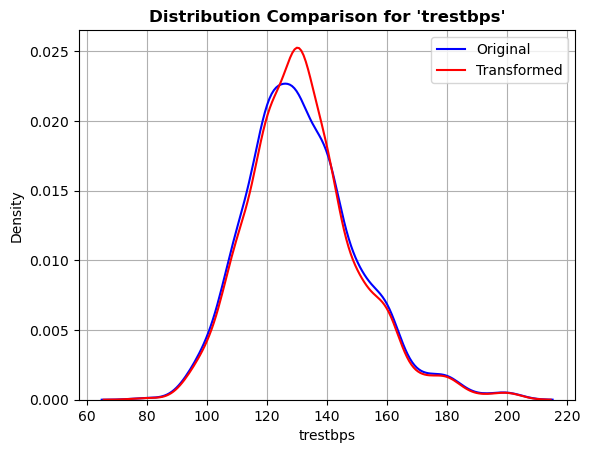

In [133]:
# Plot KDE of original trestbps in blue
sns.kdeplot(X_train['trestbps'], color="blue", label='Original')

# Plot KDE of transformed trestbps in red
sns.kdeplot(X_train_transformed['trestbps'], color="red", label='Transformed')
plt.title("Distribution Comparison for 'trestbps'", fontweight='bold')

plt.legend()
plt.grid(True)
plt.show()

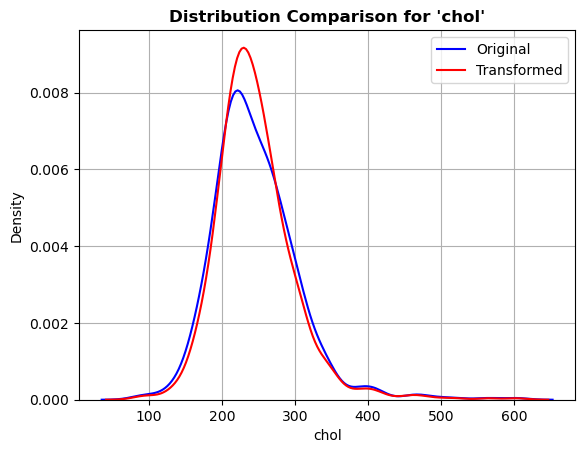

In [134]:
# Plot KDE of original cholesterol in blue
sns.kdeplot(X_train['chol'], color="blue", label='Original')

# Plot KDE of encoded/transformed cholesterol in red
sns.kdeplot(X_train_transformed['chol'], color="red", label='Transformed')

plt.title("Distribution Comparison for 'chol'", fontweight='bold')
plt.legend()
plt.grid(True)
plt.show()


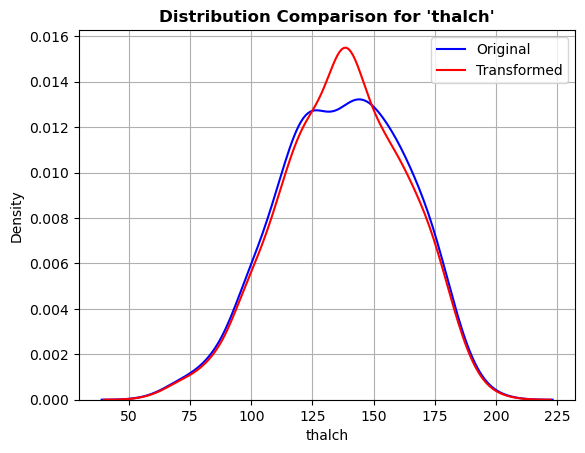

In [135]:
# Plot KDE of original thalch in blue
sns.kdeplot(X_train['thalch'], color="blue", label='Original')

# Plot KDE of transformed thalch in red
sns.kdeplot(X_train_transformed['thalch'], color="red", label='Transformed')

plt.title("Distribution Comparison for 'thalch'", fontweight='bold')
plt.legend()
plt.grid(True)
plt.show()

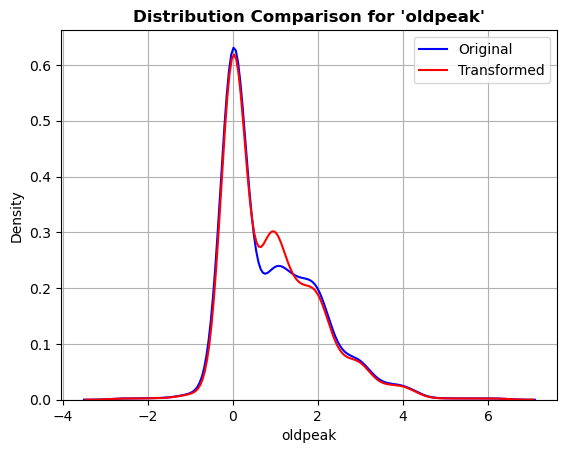

In [136]:
# Plot KDE of original oldpeak in blue
sns.kdeplot(X_train['oldpeak'], color="blue", label='Original')

# Plot KDE of transformed oldpeak in red
sns.kdeplot(X_train_transformed['oldpeak'], color="red", label='Transformed')

plt.title("Distribution Comparison for 'oldpeak'", fontweight='bold')
plt.legend()
plt.grid(True)
plt.show()


# 1. Logistic Regression

### Baseline Logistic Regression

In [137]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

simplelog = LogisticRegression()
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
print(cv)
score = cross_val_score(simplelog , X_train_transformed , y_train , cv = cv , scoring='accuracy')

print(score)

print(np.mean(score))



StratifiedKFold(n_splits=5, random_state=42, shuffle=True)
[0.76351351 0.79591837 0.82993197 0.78231293 0.79591837]
0.793519029233315


C:\Users\saini\AppData\Roaming\Python\Python312\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning:

lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression

C:\Users\saini\AppData\Roaming\Python\Python312\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning:

lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression

C:\U

## Tuned Logistic Regression

In [297]:

categorical_features = ['cp', 'restecg', 'exang', 'slope']
numerical_features = ['trestbps', 'age', 'thalch', 'chol', 'oldpeak']

numeric_transformer = Pipeline([
    ('scaler', StandardScaler()),
    ('imputer', KNNImputer(n_neighbors=5))
])

preprocessor = ColumnTransformer([
    ('num', numeric_transformer, numerical_features),
    ('cat', OneHotEncoder(handle_unknown='ignore', drop='first'), categorical_features)
], remainder='passthrough')

pipeline = Pipeline([
    ('pre', preprocessor),
    ('clf', LogisticRegression(max_iter=1000, C=0.1,solver='lbfgs',penalty='l2'))
])

# CV setup
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Arrays to store best thresholds and scores
gmean_scores = []
thresholds_list = []
accuracy = []
threshold_90_scores =[]
accuracy_thresh = []

for train_idx, val_idx in cv.split(X_train_transformed, y_train):
    X_train_fold, X_val_fold = X_train_transformed.iloc[train_idx], X_train_transformed.iloc[val_idx]
    y_train_fold, y_val_fold = y_train.iloc[train_idx], y_train.iloc[val_idx]

    # Fit model on train fold
    pipeline.fit(X_train_fold, y_train_fold)
    accuracy.append(pipeline.score(X_val_fold ,y_val_fold))

    
    # Predict probabilities on validation fold
    y_probs_val = pipeline.predict_proba(X_val_fold)[:, 1]


    fpr, tpr, thresholds = roc_curve(y_val_fold, y_probs_val)
    desired_tpr = 0.90
    

    for i, t in enumerate(thresholds):
        if tpr[i] >= desired_tpr:
            thresholds_list.append(thresholds[i])
            print(f" Threshold achieving TPR ≥ {desired_tpr}: {thresholds[i]:.3f}")
            break

    y_val_prob  = pipeline.predict_proba(X_val_fold)[:, 1]
    y_val_pred = (y_val_prob >= thresholds[i]).astype(int)
    accuracy_thresh.append(accuracy_score(y_val_pred , y_val_fold))


print(accuracy_thresh)
print(np.mean(accuracy_thresh))

print("threshold mean ",np.mean(thresholds_list))
log_final_threshold = np.mean(thresholds_list)



 Threshold achieving TPR ≥ 0.9: 0.407
 Threshold achieving TPR ≥ 0.9: 0.425
 Threshold achieving TPR ≥ 0.9: 0.347
 Threshold achieving TPR ≥ 0.9: 0.450
 Threshold achieving TPR ≥ 0.9: 0.331
[0.7905405405405406, 0.8095238095238095, 0.7891156462585034, 0.8503401360544217, 0.8163265306122449]
0.811169332597904
threshold mean  0.3921757825543857


0.8478260869565217

In [327]:

categorical_features = ['cp', 'restecg', 'exang', 'slope']
numerical_features = ['trestbps', 'age', 'thalch', 'chol', 'oldpeak']

numeric_transformer = Pipeline([
    ('scaler', StandardScaler()),
    ('imputer', KNNImputer(n_neighbors=5))
])

preprocessor = ColumnTransformer([
    ('num', numeric_transformer, numerical_features),
    ('cat', OneHotEncoder(handle_unknown='ignore', drop='first'), categorical_features)
], remainder='passthrough')

pipeline = Pipeline([
    ('pre', preprocessor),
    ('clf', LogisticRegression(max_iter=1000, C=0.1,solver='lbfgs',penalty='l2'))
])

# CV setup
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Arrays to store best thresholds and scores
gmean_scores = []
thresholds_list = []
accuracy = []
threshold_90_scores =[]
accuracy_thresh = []

for train_idx, val_idx in cv.split(X_train_transformed, y_train):
    X_train_fold, X_val_fold = X_train_transformed.iloc[train_idx], X_train_transformed.iloc[val_idx]
    y_train_fold, y_val_fold = y_train.iloc[train_idx], y_train.iloc[val_idx]

    # Fit model on train fold
    pipeline.fit(X_train_fold, y_train_fold)
    accuracy.append(pipeline.score(X_val_fold ,y_val_fold))

    
    # Predict probabilities on validation fold
    y_probs_val = pipeline.predict_proba(X_val_fold)[:, 1]


    fpr, tpr, thresholds = roc_curve(y_val_fold, y_probs_val)
    desired_tpr = 0.90
    

    for i, t in enumerate(thresholds):
        if tpr[i] >= desired_tpr:
            thresholds_list.append(thresholds[i])
            print(f" Threshold achieving TPR ≥ {desired_tpr}: {thresholds[i]:.3f}")
            break

    y_val_prob  = pipeline.predict_proba(X_val_fold)[:, 1]
    y_val_pred = (y_val_prob >= thresholds[i]).astype(int)
    accuracy_thresh.append(accuracy_score(y_val_pred , y_val_fold))


print(accuracy_thresh)
print(np.mean(accuracy_thresh))

print("threshold mean ",np.mean(thresholds_list))
log_final_threshold = np.mean(thresholds_list)




 Threshold achieving TPR ≥ 0.9: 0.407
 Threshold achieving TPR ≥ 0.9: 0.425
 Threshold achieving TPR ≥ 0.9: 0.347
 Threshold achieving TPR ≥ 0.9: 0.450
 Threshold achieving TPR ≥ 0.9: 0.331
[0.7905405405405406, 0.8095238095238095, 0.7891156462585034, 0.8503401360544217, 0.8163265306122449]
0.811169332597904
threshold mean  0.3921757825543857


### Logistic Regression (With Polynomial of degree 2)


 Final Best Threshold (Avg of CV folds): 0.443

 Train Accuracy (using tuned threshold): 0.8383

 Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.76      0.81       336
           1       0.82      0.91      0.86       400

    accuracy                           0.84       736
   macro avg       0.84      0.83      0.83       736
weighted avg       0.84      0.84      0.84       736



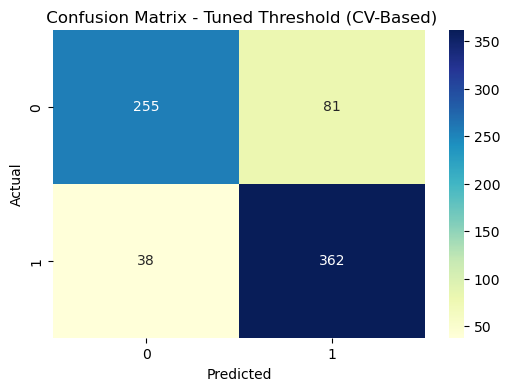


 Final Best Threshold (Avg of CV folds): 0.443

 Test Accuracy (using tuned threshold): 0.8261

 Classification Report:
              precision    recall  f1-score   support

           0       0.79      0.79      0.79        75
           1       0.85      0.85      0.85       109

    accuracy                           0.83       184
   macro avg       0.82      0.82      0.82       184
weighted avg       0.83      0.83      0.83       184



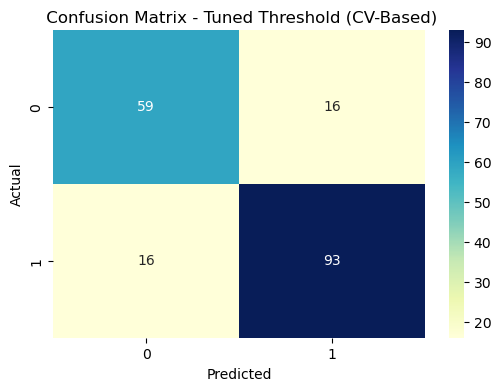

In [141]:

categorical_features = ['cp', 'restecg', 'exang', 'slope']
numerical_features = ['trestbps', 'age', 'thalch', 'chol', 'oldpeak']

numeric_transformer = Pipeline([
    ('scaler', StandardScaler()),
    ('imputer', KNNImputer(n_neighbors=5))
])

preprocessor = ColumnTransformer([
    ('num', numeric_transformer, numerical_features),
    ('cat', OneHotEncoder(handle_unknown='ignore', drop='first'), categorical_features)
], remainder='passthrough')

# Full pipeline
pipeline = Pipeline([
    ('pre', preprocessor),
    ('poly', PolynomialFeatures(degree=2, include_bias=False)),
    ('clf', LogisticRegression(max_iter=1000, C=0.1,solver='lbfgs',penalty='l2'))
])


# CV setup
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Arrays to store best thresholds and scores
gmean_scores = []
thresholds_list = []
accuracy = []
threshold_90_scores =[]
accuracy_thresh = []

for train_idx, val_idx in cv.split(X_train_transformed, y_train):
    X_train_fold, X_val_fold = X_train_transformed.iloc[train_idx], X_train_transformed.iloc[val_idx]
    y_train_fold, y_val_fold = y_train.iloc[train_idx], y_train.iloc[val_idx]

    # Fit model on train fold
    pipeline.fit(X_train_fold, y_train_fold)
    accuracy.append(pipeline.score(X_val_fold ,y_val_fold))

    
    # Predict probabilities on validation fold
    y_probs_val = pipeline.predict_proba(X_val_fold)[:, 1]

    # Compute ROC & G-Mean
    fpr, tpr, thresholds = roc_curve(y_val_fold, y_probs_val)
    desired_tpr = 0.90
    
    
    optimal_idx = np.argmax(tpr - fpr)
    optimal_threshold = thresholds[optimal_idx]
    thresholds_list.append(thresholds[optimal_idx])
    
    y_val_prob  = pipeline.predict_proba(X_val_fold)[:, 1]
    y_val_pred = (y_val_prob >= optimal_threshold).astype(int)
    accuracy_thresh.append(accuracy_score(y_val_pred , y_val_fold))
    


# Final best threshold: average of best thresholds from CV folds
final_best_threshold = np.mean(thresholds_list)
print(f"\n Final Best Threshold (Avg of CV folds): {final_best_threshold:.3f}")


### Hyperparameter Tuning 

In [156]:

# Step 1: Pipeline with scaling + logistic regression
categorical_features = ['cp', 'restecg', 'exang', 'slope']
numerical_features = ['trestbps', 'age', 'thalch', 'chol', 'oldpeak']

numeric_transformer = Pipeline([
    ('scaler', StandardScaler()),
    ('imputer', KNNImputer(n_neighbors=5))
])

preprocessor = ColumnTransformer([
    ('num', numeric_transformer, numerical_features),
    ('cat', OneHotEncoder(handle_unknown='ignore', drop='first'), categorical_features)
], remainder='passthrough')

pipeline = Pipeline([
    ('pre', preprocessor),
    ('clf', LogisticRegression(max_iter=1000, C=0.1,solver='lbfgs',penalty='l2'))
])


# Step 2: Hyperparameter grid
param_grid = {
    'clf__penalty': ['l1', 'l2'],
    'clf__C': [0.01, 0.1, 1, 10],
    'clf__solver': ['liblinear'],  # 'liblinear' supports both l1 and l2
    'clf__class_weight': [None, 'balanced']
}

# Step 3: GridSearchCV with recall scoring
grid = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',   # <<< changed here
    n_jobs=-1,
    verbose=1
)

# Step 4: Fit on training set only (no testing yet)
grid.fit(X_train_transformed, y_train)

# Step 5: Best model and best score (CV recall)
print(f"Best Parameters: {grid.best_params_}")
print(f"Best Mean CV Accuracy: {grid.best_score_:.4f}")


Fitting 5 folds for each of 16 candidates, totalling 80 fits
Best Parameters: {'clf__C': 1, 'clf__class_weight': None, 'clf__penalty': 'l1', 'clf__solver': 'liblinear'}
Best Mean CV Accuracy: 0.7962


In [159]:
# Step 1: Pipeline with scaling + logistic regression
categorical_features = ['cp', 'restecg', 'exang', 'slope']
numerical_features = ['trestbps', 'age', 'thalch', 'chol', 'oldpeak']
param = {
    "C": 1,
    "class_weight": None,
    "penalty": "l1",
    "solver": "liblinear",
    "max_iter": 1000,    
    "random_state": 42    
}

numeric_transformer = Pipeline([
    ('scaler', StandardScaler()),
    ('imputer', KNNImputer(n_neighbors=5))
])

preprocessor = ColumnTransformer([
    ('num', numeric_transformer, numerical_features),
    ('cat', OneHotEncoder(handle_unknown='ignore', drop='first'), categorical_features)
], remainder='passthrough')

pipeline = Pipeline([
    ('pre', preprocessor),
    ('clf', LogisticRegression(**param))
])


cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
print(cv)
score = cross_val_score(pipeline , X_train_transformed , y_train , cv = cv , scoring='accuracy')
print(score)

print(np.mean(score))


StratifiedKFold(n_splits=5, random_state=42, shuffle=True)
[0.76351351 0.79591837 0.80952381 0.81632653 0.7755102 ]
0.7921584850156278


### Why I Chose the Baseline Logistic Regression with Tuned Threshold

I chose to go with the baseline logistic regression model with only the decision threshold tuned because it showed better and more consistent performance during validation compared to the model that also included hyperparameter tuning.

Tuning the decision threshold directly optimizes the model’s predictions to the business or evaluation metric that matters most, such as maximizing recall or balancing precision and recall. This is especially useful in cases where the default threshold of 0.5 does not suit the problem’s context, such as with imbalanced classes. Adjusting the threshold allows us to make the model more sensitive or specific based on requirements without unnecessarily complicating the model.

On the other hand, logistic regression is inherently robust with default hyperparameters, and tuning parameters like regularization strength often yields little improvement. In fact, extensive hyperparameter tuning can sometimes lead to overfitting or instability without meaningful gains in deployment scenarios.

Therefore, by focusing on tuning the threshold, I achieved a good balance of performance metrics with a simpler model that generalizes better and is easier to maintain.

**This approach delivers practical and reliable results with less complexity, which makes it the preferred choice for deployment.**


## 2. Decision Tree

#### 2.1. Baseline Decision Tree

In [263]:
model = DecisionTreeClassifier()
cv = StratifiedKFold(n_splits = 5 , shuffle = True , random_state = 42)
score = cross_val_score(model ,X_train_transformed , y_train , cv = cv , scoring = "accuracy")
print(score)
print(np.mean(score))

[0.64864865 0.71428571 0.76190476 0.65306122 0.71428571]
0.698437212722927


#### 2.2. Hyperparameter Tuning 

In [268]:
# Hyperparameter Tuning Using Bayesian Optimization

# Step 1: Pipeline with scaling + logistic regression
categorical_features = ['cp', 'restecg', 'exang', 'slope']
numerical_features = ['trestbps', 'age', 'thalch', 'chol', 'oldpeak']

numeric_transformer = Pipeline([
    ('scaler', StandardScaler())
])

preprocessor = ColumnTransformer([
    ('num', numeric_transformer, numerical_features),
    ('cat', OneHotEncoder(handle_unknown='ignore', drop='first'), categorical_features)
], remainder='passthrough')



def objective(trial):
    max_depth = trial.suggest_categorical("max_depth", [None] + list(range(2, 20)))
    min_samples_split = trial.suggest_int("min_samples_split", 2, 20)
    min_samples_leaf = trial.suggest_int("min_samples_leaf", 1, 20)
    max_leaf_nodes = trial.suggest_categorical("max_leaf_nodes", [None] + list(range(5, 50)))
    min_impurity_decrease = trial.suggest_float("min_impurity_decrease", 1e-7, 1e-2, log=True)

    
    # Create the model with suggested hyperparameters
    model = DecisionTreeClassifier(
        max_depth=max_depth,
        min_samples_split=min_samples_split,
        min_samples_leaf=min_samples_leaf,
        max_leaf_nodes=max_leaf_nodes,
        min_impurity_decrease=min_impurity_decrease,
        random_state=42
    )
    pipeline = Pipeline([
    ('pre', preprocessor),
    ('clf', model)
    ])

    # Cross-validation
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    score = cross_val_score(pipeline, X_train_transformed, y_train, cv=cv, scoring='accuracy',n_jobs = -1)

    return np.mean(score)

# Start the study
study = optuna.create_study(direction="maximize" , sampler = TPESampler(seed=42) )
study.optimize(objective, n_trials=50)

# Print results
print("Best mean CV accuracy:", study.best_value)
print("Best parameters:", study.best_params)

[I 2025-09-23 20:54:41,870] A new study created in memory with name: no-name-e7196007-374d-438f-8ec6-aa3fa20309eb
[I 2025-09-23 20:54:49,631] Trial 0 finished with value: 0.7256113256113256 and parameters: {'max_depth': 12, 'min_samples_split': 7, 'min_samples_leaf': 13, 'max_leaf_nodes': 33, 'min_impurity_decrease': 0.001025616274847309}. Best is trial 0 with value: 0.7256113256113256.
[I 2025-09-23 20:54:53,458] Trial 1 finished with value: 0.7609578966721824 and parameters: {'max_depth': 2, 'min_samples_split': 14, 'min_samples_leaf': 18, 'max_leaf_nodes': 49, 'min_impurity_decrease': 4.130614451133167e-06}. Best is trial 1 with value: 0.7609578966721824.
[I 2025-09-23 20:54:53,593] Trial 2 finished with value: 0.7282956425813569 and parameters: {'max_depth': 19, 'min_samples_split': 6, 'min_samples_leaf': 14, 'max_leaf_nodes': 25, 'min_impurity_decrease': 0.0031100755757274947}. Best is trial 1 with value: 0.7609578966721824.
[I 2025-09-23 20:54:53,706] Trial 3 finished with value:

Best mean CV accuracy: 0.7690843905129621
Best parameters: {'max_depth': 4, 'min_samples_split': 13, 'min_samples_leaf': 17, 'max_leaf_nodes': 10, 'min_impurity_decrease': 0.00010777626182701887}


In [277]:
categorical_features = ['cp', 'restecg', 'exang', 'slope']
numerical_features = ['trestbps', 'age', 'thalch', 'chol', 'oldpeak']

numeric_transformer = Pipeline([
    ('scaler', StandardScaler())
])

preprocessor = ColumnTransformer([
    ('num', numeric_transformer, numerical_features),
    ('cat', OneHotEncoder(handle_unknown='ignore', drop='first'), categorical_features)
], remainder='passthrough')

pipeline = Pipeline([
    ('pre', preprocessor),
    ('clf', DecisionTreeClassifier(**study.best_params))
    ])

cv = StratifiedKFold(n_splits = 5 , shuffle = True , random_state = 42)
score = cross_val_score(pipeline ,X_train_transformed , y_train , cv = cv , scoring = "accuracy")
print(score)
print(np.mean(score))


[0.72297297 0.78231293 0.80272109 0.76870748 0.76870748]
0.7690843905129621


In [278]:
# Hyperparameter Tuning Using Grid Search CV
categorical_features =  ['cp', 'restecg', 'exang', 'slope']
numerical_features = ['trestbps', 'age', 'thalch', 'chol', 'oldpeak']

numeric_transformer = Pipeline([
    ('scaler', StandardScaler())
])

preprocessor = ColumnTransformer([
    ('num', numeric_transformer, numerical_features),
    ('cat', OneHotEncoder(handle_unknown='ignore', drop='first'), categorical_features)
], remainder='passthrough')

pipeline = Pipeline([
    ('pre', preprocessor),
    ('clf', DecisionTreeClassifier(class_weight = 'balanced',random_state = 42))
])

# Define hyperparameter grid
param_grid = {
    'clf__max_depth': [20,None],
    'clf__min_samples_split': [2,4],
    'clf__min_samples_leaf': [5,10,12,15], 
    'clf__min_impurity_decrease': [0.0,0.02]
}

# Define stratified cross-validation
cv_strategy = StratifiedKFold(n_splits = 5, shuffle = True, random_state = 42)

# GridSearchCV setup
grid_search = GridSearchCV(
    estimator = pipeline,
    param_grid = param_grid,
    scoring = ['recall','accuracy'],
    refit = 'accuracy',
    cv = cv_strategy,                
    n_jobs = -1,
    verbose = 0,
    return_train_score = True
)

# Fit the model
grid_search.fit(X_train_transformed, y_train)

# Best results
print("Best Parameters:", grid_search.best_params_)
print("Best Accuracy on CV:", grid_search.best_score_)
print()

Best Parameters: {'clf__max_depth': 20, 'clf__min_impurity_decrease': 0.02, 'clf__min_samples_leaf': 5, 'clf__min_samples_split': 2}
Best Accuracy on CV: 0.7500919286633573



In [280]:
# Hyperparameter Tuning Using Grid Search CV

dt_hpt =  DecisionTreeClassifier(class_weight = 'balanced',random_state = 42)

# Define hyperparameter grid
param_grid = {
    'max_depth': [20,None],
    'min_samples_split': [2,4],
    'min_samples_leaf': [5,10,12,15], 
    'min_impurity_decrease': [0.0,0.02]
}

# Define stratified cross-validation
cv_strategy = StratifiedKFold(n_splits = 5, shuffle = True, random_state = 42)

# GridSearchCV setup
grid_search = GridSearchCV(
    estimator = dt_hpt,
    param_grid = param_grid,
    scoring = ['recall','accuracy'],
    refit = 'accuracy',
    cv = cv_strategy,                
    n_jobs = -1,
    verbose = 0,
    return_train_score = True
)

# Fit the model
grid_search.fit(X_train_transformed, y_train)

# Best results
print("Best Parameters:", grid_search.best_params_)
print("Best Accuracy on CV:", grid_search.best_score_)
print()

Best Parameters: {'max_depth': 20, 'min_impurity_decrease': 0.02, 'min_samples_leaf': 5, 'min_samples_split': 2}
Best Accuracy on CV: 0.7500919286633573



In [274]:
# Hyperparameter Tuning Using Grid Search CV 
categorical_features = ['cp', 'restecg', 'exang', 'slope']
numerical_features = ['trestbps', 'age', 'thalch', 'chol', 'oldpeak']

numeric_transformer = Pipeline([
    ('scaler', StandardScaler())
])

preprocessor = ColumnTransformer([
    ('num', numeric_transformer, numerical_features),
    ('cat', OneHotEncoder(handle_unknown='ignore', drop='first'), categorical_features)
], remainder='passthrough')

pipeline = Pipeline([
    ('pre', preprocessor),
    ('clf', DecisionTreeClassifier(class_weight = 'balanced',random_state = 42))
])

# Define hyperparameter grid
param_grid = {
    'clf__max_depth': [20,None],
    'clf__min_samples_split': [2,4],
    'clf__min_samples_leaf': [5,10,12,15], 
    'clf__min_impurity_decrease': [0.0,0.02]
}

# Define stratified cross-validation
cv_strategy = StratifiedKFold(n_splits = 5, shuffle = True, random_state = 42)

# GridSearchCV setup
grid_search = GridSearchCV(
    estimator = pipeline,
    param_grid = param_grid,
    scoring = ['recall','accuracy'],
    refit = 'accuracy',
    cv = cv_strategy,                
    n_jobs = -1,
    verbose = 0,
    return_train_score = True
)

# Fit the model
grid_search.fit(X_train_transformed, y_train)

# Best results
print("Best Parameters:", grid_search.best_params_)
print("Best Accuracy on CV:", grid_search.best_score_)
print()

Best Parameters: {'clf__max_depth': 20, 'clf__min_impurity_decrease': 0.02, 'clf__min_samples_leaf': 5, 'clf__min_samples_split': 2}
Best Accuracy on CV: 0.7500919286633573



##### Tuning Threshold Value

In [281]:
# Tuning THreshold for the model with parameters from Bayesian Optimization
categorical_features = ['cp', 'restecg', 'exang', 'slope']
numerical_features = ['trestbps', 'age', 'thalch', 'chol', 'oldpeak']

numeric_transformer = Pipeline([
    ('scaler', StandardScaler())
])

preprocessor = ColumnTransformer([
    ('num', numeric_transformer, numerical_features),
    ('cat', OneHotEncoder(handle_unknown='ignore', drop='first'), categorical_features)
], remainder='passthrough')


pipeline = Pipeline([
    ('preprocessing', preprocessor),
    ('model',  DecisionTreeClassifier(**study.best_params,random_state = 42))
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
thresholds = []
cv_acc_scores = []
cv_recall_scores = []

desired_tpr = 0.90

print("\nFinding Best Thresholds using CV:")

for fold, (train_idx, val_idx) in enumerate(cv.split(X_train_transformed, y_train), 1):
    X_tr, X_val = X_train_transformed.iloc[train_idx], X_train_transformed.iloc[val_idx]
    y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]

    # Train pipeline on current fold
    pipeline.fit(X_tr, y_tr)

    # Predict probabilities on validation fold
    val_probs = pipeline.predict_proba(X_val)[:, 1]

    # ROC curve
    fpr, tpr, thresh = roc_curve(y_val, val_probs)

    # Find first threshold where TPR >= desired_tpr
    thresh_for_tpr = None
    actual_tpr = None
    for t, tp in zip(thresh, tpr):
        if tp >= desired_tpr:
            thresh_for_tpr = t
            actual_tpr = tp
            break

    if thresh_for_tpr is None:
        thresh_for_tpr = 0.5
        actual_tpr = tpr[-1]  # last available TPR

    thresholds.append(thresh_for_tpr)

    # Predictions using chosen threshold
    y_val_pred = (val_probs >= thresh_for_tpr).astype(int)

    # Scores
    acc = accuracy_score(y_val, y_val_pred)
    rec = recall_score(y_val, y_val_pred)

    cv_acc_scores.append(acc)
    cv_recall_scores.append(rec)

    print(f"Fold {fold} → Threshold: {thresh_for_tpr:.3f}, "
          f"CV Accuracy: {acc:.4f}, Recall: {rec:.4f}")

# Averages
final_thresh = mean(thresholds)
mean_cv_acc = mean(cv_acc_scores)
mean_cv_recall = mean(cv_recall_scores)

print(f"\nFinal Averaged Threshold for TPR ≥ {desired_tpr*100:.0f}%: {final_thresh:.3f}")
print(f"Mean CV Accuracy Across Folds: {mean_cv_acc:.4f}")
print(f"Mean CV Recall Across Folds:   {mean_cv_recall:.4f}")



Finding Best Thresholds using CV:
Fold 1 → Threshold: 0.279, TPR from ROC: 0.912, CV Accuracy: 0.6959, Recall: 0.9125
Fold 2 → Threshold: 0.176, TPR from ROC: 0.900, CV Accuracy: 0.6939, Recall: 0.9000
Fold 3 → Threshold: 0.483, TPR from ROC: 0.925, CV Accuracy: 0.7687, Recall: 0.9250
Fold 4 → Threshold: 0.367, TPR from ROC: 0.963, CV Accuracy: 0.7415, Recall: 0.9625
Fold 5 → Threshold: 0.324, TPR from ROC: 0.938, CV Accuracy: 0.7211, Recall: 0.9375

Final Averaged Threshold for TPR ≥ 90%: 0.326
Mean CV Accuracy Across Folds: 0.7242
Mean CV Recall Across Folds:   0.9275


In [282]:
dt_grid_best_params =  {'max_depth': 20, 'min_impurity_decrease': 0.02, 'min_samples_leaf': 5, 'min_samples_split': 2}

In [284]:
# Tuning Threshold for model with parameters from Grid Search CV 
categorical_features = ['cp', 'restecg', 'exang', 'slope']
numerical_features = ['trestbps', 'age', 'thalch', 'chol', 'oldpeak']

numeric_transformer = Pipeline([
    ('scaler', StandardScaler())
])

preprocessor = ColumnTransformer([
    ('num', numeric_transformer, numerical_features),
    ('cat', OneHotEncoder(handle_unknown='ignore', drop='first'), categorical_features)
], remainder='passthrough')


pipeline = Pipeline([
    ('preprocessing', preprocessor),
    ('model',  DecisionTreeClassifier(**dt_grid_best_params,random_state = 42))
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
thresholds = []
cv_acc_scores = []
cv_recall_scores = []

desired_tpr = 0.90

print("\nFinding Best Thresholds using CV:")

for fold, (train_idx, val_idx) in enumerate(cv.split(X_train_transformed, y_train), 1):
    X_tr, X_val = X_train_transformed.iloc[train_idx], X_train_transformed.iloc[val_idx]
    y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]

    # Train pipeline on current fold
    pipeline.fit(X_tr, y_tr)

    # Predict probabilities on validation fold
    val_probs = pipeline.predict_proba(X_val)[:, 1]

    # ROC curve
    fpr, tpr, thresh = roc_curve(y_val, val_probs)

    # Find first threshold where TPR >= desired_tpr
    thresh_for_tpr = None
    actual_tpr = None
    for t, tp in zip(thresh, tpr):
        if tp >= desired_tpr:
            thresh_for_tpr = t
            actual_tpr = tp
            break

    if thresh_for_tpr is None:
        thresh_for_tpr = 0.5
        actual_tpr = tpr[-1]  # last available TPR

    thresholds.append(thresh_for_tpr)

    # Predictions using chosen threshold
    y_val_pred = (val_probs >= thresh_for_tpr).astype(int)

    # Scores
    acc = accuracy_score(y_val, y_val_pred)
    rec = recall_score(y_val, y_val_pred)

    cv_acc_scores.append(acc)
    cv_recall_scores.append(rec)

    print(f"Fold {fold} → Threshold: {thresh_for_tpr:.3f}, "
          f"CV Accuracy: {acc:.4f}, Recall: {rec:.4f}")

# Averages
final_thresh = mean(thresholds)
mean_cv_acc = mean(cv_acc_scores)
mean_cv_recall = mean(cv_recall_scores)

print(f"\nFinal Averaged Threshold for TPR ≥ {desired_tpr*100:.0f}%: {final_thresh:.3f}")
print(f"Mean CV Accuracy Across Folds: {mean_cv_acc:.4f}")
print(f"Mean CV Recall Across Folds:   {mean_cv_recall:.4f}")



Finding Best Thresholds using CV:
Fold 1 → Threshold: 0.258, CV Accuracy: 0.5405, Recall: 1.0000
Fold 2 → Threshold: 0.438, CV Accuracy: 0.6463, Recall: 0.9000
Fold 3 → Threshold: 0.490, CV Accuracy: 0.7143, Recall: 0.9250
Fold 4 → Threshold: 0.261, CV Accuracy: 0.5442, Recall: 1.0000
Fold 5 → Threshold: 0.272, CV Accuracy: 0.5442, Recall: 1.0000

Final Averaged Threshold for TPR ≥ 90%: 0.344
Mean CV Accuracy Across Folds: 0.5979
Mean CV Recall Across Folds:   0.9650


In [291]:
# Tuning Threshold for model with parameters from Grid Search CV 
categorical_features = ['cp', 'restecg', 'exang', 'slope']
numerical_features = ['trestbps', 'age', 'thalch', 'chol', 'oldpeak']

numeric_transformer = Pipeline([
    ('scaler', StandardScaler())
])

preprocessor = ColumnTransformer([
    ('num', numeric_transformer, numerical_features),
    ('cat', OneHotEncoder(handle_unknown='ignore', drop='first'), categorical_features)
], remainder='passthrough')


pipeline = Pipeline([
    ('preprocessing', preprocessor),
    ('model',  DecisionTreeClassifier(random_state = 42))
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
thresholds = []
cv_acc_scores = []
cv_recall_scores = []

desired_tpr = 0.80

print("\nFinding Best Thresholds using CV:")

for fold, (train_idx, val_idx) in enumerate(cv.split(X_train_transformed, y_train), 1):
    X_tr, X_val = X_train_transformed.iloc[train_idx], X_train_transformed.iloc[val_idx]
    y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]

    # Train pipeline on current fold
    pipeline.fit(X_tr, y_tr)

    # Predict probabilities on validation fold
    val_probs = pipeline.predict_proba(X_val)[:, 1]

    # ROC curve
    fpr, tpr, thresh = roc_curve(y_val, val_probs)

    # Find first threshold where TPR >= desired_tpr
    thresh_for_tpr = None
    actual_tpr = None
    for t, tp in zip(thresh, tpr):
        if tp >= desired_tpr:
            thresh_for_tpr = t
            actual_tpr = tp
            break

    if thresh_for_tpr is None:
        thresh_for_tpr = 0.5
        actual_tpr = tpr[-1]  # last available TPR

    thresholds.append(thresh_for_tpr)

    # Predictions using chosen threshold
    y_val_pred = (val_probs >= thresh_for_tpr).astype(int)

    # Scores
    acc = accuracy_score(y_val, y_val_pred)
    rec = recall_score(y_val, y_val_pred)

    cv_acc_scores.append(acc)
    cv_recall_scores.append(rec)

    print(f"Fold {fold} → Threshold: {thresh_for_tpr:.3f}, "
          f"CV Accuracy: {acc:.4f}, Recall: {rec:.4f}")

# Averages
final_thresh = mean(thresholds)
mean_cv_acc = mean(cv_acc_scores)
mean_cv_recall = mean(cv_recall_scores)

print(f"\nFinal Averaged Threshold for TPR ≥ {desired_tpr*100:.0f}%: {final_thresh:.3f}")
print(f"Mean CV Accuracy Across Folds: {mean_cv_acc:.4f}")
print(f"Mean CV Recall Across Folds:   {mean_cv_recall:.4f}")



Finding Best Thresholds using CV:
Fold 1 → Threshold: 0.000, CV Accuracy: 0.5405, Recall: 1.0000
Fold 2 → Threshold: 0.000, CV Accuracy: 0.5442, Recall: 1.0000
Fold 3 → Threshold: 1.000, CV Accuracy: 0.7687, Recall: 0.8375
Fold 4 → Threshold: 0.000, CV Accuracy: 0.5442, Recall: 1.0000
Fold 5 → Threshold: 0.000, CV Accuracy: 0.5442, Recall: 1.0000

Final Averaged Threshold for TPR ≥ 80%: 0.200
Mean CV Accuracy Across Folds: 0.5884
Mean CV Recall Across Folds:   0.9675


---
### Model Performance Comparison and Selection
---
Our baseline Decision Tree model achieved an accuracy of **69.8%** on the dataset.  


#### Hyperparameter Tuning Results

- **Grid Search CV** → Accuracy: **%**  
- **Bayesian Optimization (refined)** → Accuracy: **72.4%**, Recall: **92.75%**  
- **Bayesian Optimization (initial)** → Accuracy: **76.9%**  
- **Grid Search CV + Threshold Tuning** → Accuracy: **59.79%**, Recall: **96.5%**  
- **Baseline SVM + Threshold Tuning** → Accuracy: **58.8%**, Recall: **96.75%**  



# 3. RANDOM FOREST

#### 3.1. Baseline Random Forest

In [161]:
model = RandomForestClassifier()
cv = StratifiedKFold(n_splits = 5 , shuffle = True , random_state = 42)
score = cross_val_score(model , X_train_transformed , y_train ,cv = cv , scoring = "accuracy")
print(score)
print(np.mean(score))


[0.77027027 0.76870748 0.80952381 0.7755102  0.7755102 ]
0.7799043941901085


In [ ]:
max_depth = 10, max_features ='sqrt', min_samples_leaf =  4, min_samples_split = 10, n_estimators =  100

In [195]:
# one hot encoding categorical columns and  adding some hyperparameter to check accuracy 
categorical_cols = ['restecg','cp']

preprocessor = ColumnTransformer([
    ("cat", OneHotEncoder(handle_unknown='ignore'), categorical_cols)
], remainder='passthrough') 


model = RandomForestClassifier()

pipeline = Pipeline([
        ('preprocessing', preprocessor),
        ('model', model)
    ])

cv = StratifiedKFold(n_splits = 5 , shuffle = True , random_state = 42)


score = cross_val_score(model , X_train_transformed , y_train ,cv = cv , scoring = "accuracy")

print(score)

print(np.mean(score))

[0.75675676 0.76190476 0.80272109 0.80272109 0.78231293]
0.781283324140467


In [196]:
# Checking if scaling numerical column and one hot encoding all cat column improves accuracy

categorical_features = ['cp', 'restecg', 'exang', 'slope']
numerical_features = ['trestbps', 'age', 'thalch', 'chol', 'oldpeak']

numeric_transformer = Pipeline([
    ('scaler', StandardScaler()),
    ('imputer', KNNImputer(n_neighbors=5))
])

preprocessor = ColumnTransformer([
    ('num', numeric_transformer, numerical_features),
    ('cat', OneHotEncoder(handle_unknown='ignore', drop='first'), categorical_features)
], remainder='passthrough')

model = RandomForestClassifier()

pipeline = Pipeline([
        ('preprocessing', preprocessor),
        ('model', model)
    ])

cv = StratifiedKFold(n_splits = 5 , shuffle = True , random_state = 42)


score = cross_val_score(model , X_train_transformed , y_train ,cv = cv , scoring = "accuracy")

print(score)

print(np.mean(score))

[0.80405405 0.75510204 0.80272109 0.78231293 0.7755102 ]
0.7839400625114912


### 3.2. Hyperparameter Tuning 

In [167]:
# Checking if scaling numerical column and one hot encoding all categorical column improves accuracy

categorical_features = ['cp', 'restecg', 'exang', 'slope']
numerical_features = ['trestbps', 'age', 'thalch', 'chol', 'oldpeak']

numeric_transformer = Pipeline([
    ('scaler', StandardScaler()),
    ('imputer', KNNImputer(n_neighbors=5))
])

preprocessor = ColumnTransformer([
    ('num', numeric_transformer, numerical_features),
    ('cat', OneHotEncoder(handle_unknown='ignore', drop='first'), categorical_features)
], remainder='passthrough')

model  = RandomForestClassifier(
    max_depth=8, min_samples_split=11, min_samples_leaf=9, max_leaf_nodes=23,
    min_impurity_decrease=0.0003453, n_estimators=250, random_state=42
)


pipeline = Pipeline([
        ('preprocessing', preprocessor),
        ('model', model)
    ])

cv = StratifiedKFold(n_splits = 5 , shuffle = True , random_state = 42)


score = cross_val_score(model , X_train_transformed , y_train ,cv = cv , scoring = "accuracy")

print(score)

print(np.mean(score))

[0.76351351 0.78231293 0.80952381 0.82312925 0.78911565]
0.793519029233315


In [200]:
# Using Grid Search CV 
param_grid = {
    'model__max_depth': [8, 10, 12],
    'model__max_features': ['sqrt', 'log2'],
    'model__min_samples_leaf': [3, 4, 5],
    'model__min_samples_split': [8, 10, 12],
    'model__n_estimators': [80, 100, 120]
}

# Pipeline with preprocessing + RF
pipeline = Pipeline([
    ('preprocessing', preprocessor),
    ('model', RandomForestClassifier(random_state=42, n_jobs=-1))
])

# GridSearchCV setup
grid = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    cv=5,
    scoring='recall',  
    n_jobs=-1,
    verbose=2
)

# Fit on training set
grid.fit(X_train_transformed, y_train)

print("\nBest Parameters:", grid.best_params_)
print("Best Mean CV Recall:", grid.best_score_)

Fitting 5 folds for each of 162 candidates, totalling 810 fits

Best Parameters: {'model__max_depth': 10, 'model__max_features': 'sqrt', 'model__min_samples_leaf': 4, 'model__min_samples_split': 8, 'model__n_estimators': 100}
Best Mean CV Recall: 0.845


In [201]:
grid_best_params = {
    'max_depth': 10,
    'max_features': 'sqrt',
    'min_samples_leaf': 4,
    'min_samples_split': 8,
    'n_estimators': 100
}


In [174]:
# HyperParameter Tuning With Bayesian Optimization

categorical_features = ['cp', 'restecg', 'exang', 'slope']
numerical_features = ['trestbps', 'age', 'thalch', 'chol', 'oldpeak']

numeric_transformer = Pipeline([
    ('scaler', StandardScaler()),
    ('imputer', KNNImputer(n_neighbors=5))
])

preprocessor = ColumnTransformer([
    ('num', numeric_transformer, numerical_features),
    ('cat', OneHotEncoder(handle_unknown='ignore', drop='first'), categorical_features)
], remainder='passthrough')

def objective(trial):
    max_depth = trial.suggest_int("max_depth", 3, 20)
    min_samples_split = trial.suggest_int("min_samples_split", 2, 20)
    min_samples_leaf = trial.suggest_int("min_samples_leaf", 1, 20)
    max_leaf_nodes = trial.suggest_int("max_leaf_nodes", 10, 50)
    min_impurity_decrease = trial.suggest_float("min_impurity_decrease", 1e-7, 1e-2, log=True)
    n_estimators = trial.suggest_int("n_estimators", 100, 500)
    max_features = trial.suggest_categorical("max_features", ["sqrt", "log2", None])
    bootstrap = trial.suggest_categorical("bootstrap", [True, False])
    class_weight = trial.suggest_categorical("class_weight", [None, "balanced", "balanced_subsample"])

    model = RandomForestClassifier(
        max_depth=max_depth,
        min_samples_split=min_samples_split,
        min_samples_leaf=min_samples_leaf,
        max_leaf_nodes=max_leaf_nodes,
        min_impurity_decrease=min_impurity_decrease,
        n_estimators=n_estimators,
        max_features=max_features,
        bootstrap=bootstrap,
        class_weight=class_weight,
        random_state=42,
        n_jobs=-1
    )

    pipeline = Pipeline([
        ('preprocessing', preprocessor),
        ('model', model)
    ])

    score = cross_val_score(pipeline, X_train_transformed, y_train, cv=cv, scoring="accuracy")

    return np.mean(score)


study = optuna.create_study(direction = 'maximize',sampler = TPESampler(seed = 42))
study.optimize(objective , n_trials = 50)

print("Best mean CV accuracy:", study.best_value)
print("Best parameters:", study.best_params)
    

[I 2025-09-23 14:16:28,599] A new study created in memory with name: no-name-e9ce1bac-c6b3-4f8e-b37a-815e363f9ffa
[I 2025-09-23 14:16:33,612] Trial 0 finished with value: 0.7813109027394741 and parameters: {'max_depth': 9, 'min_samples_split': 20, 'min_samples_leaf': 15, 'max_leaf_nodes': 34, 'min_impurity_decrease': 6.026889128682512e-07, 'n_estimators': 162, 'max_features': 'log2', 'bootstrap': True, 'class_weight': None}. Best is trial 0 with value: 0.7813109027394741.
[I 2025-09-23 14:16:38,017] Trial 1 finished with value: 0.7853833425261996 and parameters: {'max_depth': 6, 'min_samples_split': 5, 'min_samples_leaf': 7, 'max_leaf_nodes': 31, 'min_impurity_decrease': 1.4445251022763063e-05, 'n_estimators': 216, 'max_features': 'sqrt', 'bootstrap': False, 'class_weight': None}. Best is trial 1 with value: 0.7853833425261996.
[I 2025-09-23 14:16:47,828] Trial 2 finished with value: 0.777229270086413 and parameters: {'max_depth': 13, 'min_samples_split': 2, 'min_samples_leaf': 13, 'ma

Best mean CV accuracy: 0.7976190476190477
Best parameters: {'max_depth': 6, 'min_samples_split': 9, 'min_samples_leaf': 8, 'max_leaf_nodes': 49, 'min_impurity_decrease': 6.443937058361277e-05, 'n_estimators': 129, 'max_features': 'sqrt', 'bootstrap': True, 'class_weight': None}


In [320]:
rf_best_params = {'max_depth': 6, 'min_samples_split': 9, 'min_samples_leaf': 8, 'max_leaf_nodes': 49, 'min_impurity_decrease': 6.443937058361277e-05, 'n_estimators': 129, 'max_features': 'sqrt', 'bootstrap': True, 'class_weight': None}

In [175]:
# Checking Accuracy With Cross-Validation Using StratifiedKFold
pipeline = Pipeline([
            ('preprocessing', preprocessor),
            ('model', RandomForestClassifier(**rf_best_params ,n_jobs =  -1, random_state=42))
        ])
score = cross_val_score(pipeline ,X_train_transformed , y_train , cv = cv , scoring = "accuracy")
print(score)
print(np.mean(score))

[0.75       0.78911565 0.84353741 0.82993197 0.7755102 ]
0.7976190476190477


In [204]:
from sklearn.metrics import accuracy_score, recall_score, roc_curve
from statistics import mean

pipeline = Pipeline([
    ('preprocessing', preprocessor),
    ('model', RandomForestClassifier(**rf_best_params, n_jobs=-1, random_state=42))
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
thresholds = []
cv_acc_scores = []
cv_recall_scores = []

desired_tpr = 0.90

print("\nFinding Best Thresholds using CV:")

for fold, (train_idx, val_idx) in enumerate(cv.split(X_train_transformed, y_train), 1):
    X_tr, X_val = X_train_transformed.iloc[train_idx], X_train_transformed.iloc[val_idx]
    y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]

    # Train pipeline on current fold
    pipeline.fit(X_tr, y_tr)

    # Predict probabilities on validation fold
    val_probs = pipeline.predict_proba(X_val)[:, 1]

    # ROC curve
    fpr, tpr, thresh = roc_curve(y_val, val_probs)

    # Find first threshold where TPR >= desired_tpr
    thresh_for_tpr = None
    actual_tpr = None
    for t, tp in zip(thresh, tpr):
        if tp >= desired_tpr:
            thresh_for_tpr = t
            actual_tpr = tp
            break

    if thresh_for_tpr is None:
        thresh_for_tpr = 0.5
        actual_tpr = tpr[-1]  # last available TPR

    thresholds.append(thresh_for_tpr)

    # Predictions using chosen threshold
    y_val_pred = (val_probs >= thresh_for_tpr).astype(int)

    # Scores
    acc = accuracy_score(y_val, y_val_pred)
    rec = recall_score(y_val, y_val_pred)

    cv_acc_scores.append(acc)
    cv_recall_scores.append(rec)

    print(f"Fold {fold} → Threshold: {thresh_for_tpr:.3f}, "
          f"TPR from ROC: {actual_tpr:.3f}, "
          f"CV Accuracy: {acc:.4f}, Recall: {rec:.4f}")

# Averages
final_thresh = mean(thresholds)
mean_cv_acc = mean(cv_acc_scores)
mean_cv_recall = mean(cv_recall_scores)

print(f"\nFinal Averaged Threshold for TPR ≥ {desired_tpr*100:.0f}%: {final_thresh:.3f}")
print(f"Mean CV Accuracy Across Folds: {mean_cv_acc:.4f}")
print(f"Mean CV Recall Across Folds:   {mean_cv_recall:.4f}")



Finding Best Thresholds using CV:
Fold 1 → Threshold: 0.434, TPR from ROC: 0.900, CV Accuracy: 0.7703, Recall: 0.9000
Fold 2 → Threshold: 0.449, TPR from ROC: 0.900, CV Accuracy: 0.7959, Recall: 0.9000
Fold 3 → Threshold: 0.502, TPR from ROC: 0.900, CV Accuracy: 0.8435, Recall: 0.9000
Fold 4 → Threshold: 0.487, TPR from ROC: 0.925, CV Accuracy: 0.8435, Recall: 0.9250
Fold 5 → Threshold: 0.369, TPR from ROC: 0.938, CV Accuracy: 0.8095, Recall: 0.9375

Final Averaged Threshold for TPR ≥ 90%: 0.448
Mean CV Accuracy Across Folds: 0.8126
Mean CV Recall Across Folds:   0.9125


In [305]:
rf_final_threshold = 0.448

In [207]:
# Checking If Threshold Improve Accuracy , Using the parameters given by Grid Search CV
from sklearn.metrics import accuracy_score, recall_score, roc_curve
from statistics import mean

pipeline = Pipeline([
    ('preprocessing', preprocessor),
    ('model', RandomForestClassifier(**grid_best_params, n_jobs=-1, random_state=42))
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
thresholds = []
cv_acc_scores = []
cv_recall_scores = []

desired_tpr = 0.90

print("\nFinding Best Thresholds using CV:")

for fold, (train_idx, val_idx) in enumerate(cv.split(X_train_transformed, y_train), 1):
    X_tr, X_val = X_train_transformed.iloc[train_idx], X_train_transformed.iloc[val_idx]
    y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]

    # Train pipeline on current fold
    pipeline.fit(X_tr, y_tr)

    # Predict probabilities on validation fold
    val_probs = pipeline.predict_proba(X_val)[:, 1]

    # ROC curve
    fpr, tpr, thresh = roc_curve(y_val, val_probs)

    # Find first threshold where TPR >= desired_tpr
    thresh_for_tpr = None
    actual_tpr = None
    for t, tp in zip(thresh, tpr):
        if tp >= desired_tpr:
            thresh_for_tpr = t
            actual_tpr = tp
            break

    if thresh_for_tpr is None:
        thresh_for_tpr = 0.5
        actual_tpr = tpr[-1]  # last available TPR

    thresholds.append(thresh_for_tpr)

    # Predictions using chosen threshold
    y_val_pred = (val_probs >= thresh_for_tpr).astype(int)

    # Scores
    acc = accuracy_score(y_val, y_val_pred)
    rec = recall_score(y_val, y_val_pred)

    cv_acc_scores.append(acc)
    cv_recall_scores.append(rec)

    print(f"Fold {fold} → Threshold: {thresh_for_tpr:.3f}, "
          f"TPR from ROC: {actual_tpr:.3f}, "
          f"CV Accuracy: {acc:.4f}, Recall: {rec:.4f}")

# Averages
final_thresh = mean(thresholds)
mean_cv_acc = mean(cv_acc_scores)
mean_cv_recall = mean(cv_recall_scores)

print(f"\nFinal Averaged Threshold for TPR ≥ {desired_tpr*100:.0f}%: {final_thresh:.3f}")
print(f"Mean CV Accuracy Across Folds: {mean_cv_acc:.4f}")
print(f"Mean CV Recall Across Folds:   {mean_cv_recall:.4f}")



Finding Best Thresholds using CV:
Fold 1 → Threshold: 0.401, TPR from ROC: 0.900, CV Accuracy: 0.7770, Recall: 0.9000
Fold 2 → Threshold: 0.344, TPR from ROC: 0.900, CV Accuracy: 0.7551, Recall: 0.9000
Fold 3 → Threshold: 0.448, TPR from ROC: 0.925, CV Accuracy: 0.8231, Recall: 0.9250
Fold 4 → Threshold: 0.483, TPR from ROC: 0.900, CV Accuracy: 0.8231, Recall: 0.9000
Fold 5 → Threshold: 0.375, TPR from ROC: 0.912, CV Accuracy: 0.8027, Recall: 0.9125

Final Averaged Threshold for TPR ≥ 90%: 0.410
Mean CV Accuracy Across Folds: 0.7962
Mean CV Recall Across Folds:   0.9075


In [208]:
# Doing Threshold Tuning With Baseline Random Forest
categorical_features = ['cp', 'restecg', 'exang', 'slope']
numerical_features = ['trestbps', 'age', 'thalch', 'chol', 'oldpeak']

numeric_transformer = Pipeline([
    ('scaler', StandardScaler()),
    ('imputer', KNNImputer(n_neighbors=5))
])

preprocessor = ColumnTransformer([
    ('num', numeric_transformer, numerical_features),
    ('cat', OneHotEncoder(handle_unknown='ignore', drop='first'), categorical_features)
], remainder='passthrough')

model = RandomForestClassifier(random_state = 42)

pipeline = Pipeline([
        ('preprocessing', preprocessor),
        ('model', model)
    ])

thresholds = []
cv_acc_scores = []
cv_recall_scores = []

desired_tpr = 0.90

print("\nFinding Best Thresholds using CV:")

for fold, (train_idx, val_idx) in enumerate(cv.split(X_train_transformed, y_train), 1):
    X_tr, X_val = X_train_transformed.iloc[train_idx], X_train_transformed.iloc[val_idx]
    y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]

    # Train pipeline on current fold
    pipeline.fit(X_tr, y_tr)

    # Predict probabilities on validation fold
    val_probs = pipeline.predict_proba(X_val)[:, 1]

    # ROC curve
    fpr, tpr, thresh = roc_curve(y_val, val_probs)

    # Find first threshold where TPR >= desired_tpr
    thresh_for_tpr = None
    actual_tpr = None
    for t, tp in zip(thresh, tpr):
        if tp >= desired_tpr:
            thresh_for_tpr = t
            actual_tpr = tp
            break

    if thresh_for_tpr is None:
        thresh_for_tpr = 0.5
        actual_tpr = tpr[-1]  # last available TPR

    thresholds.append(thresh_for_tpr)

    # Predictions using chosen threshold
    y_val_pred = (val_probs >= thresh_for_tpr).astype(int)

    # Scores
    acc = accuracy_score(y_val, y_val_pred)
    rec = recall_score(y_val, y_val_pred)

    cv_acc_scores.append(acc)
    cv_recall_scores.append(rec)

    print(f"Fold {fold} → Threshold: {thresh_for_tpr:.3f}, "
          f"TPR from ROC: {actual_tpr:.3f}, "
          f"CV Accuracy: {acc:.4f}, Recall: {rec:.4f}")

# Averages
final_thresh = mean(thresholds)
mean_cv_acc = mean(cv_acc_scores)
mean_cv_recall = mean(cv_recall_scores)

print(f"\nFinal Averaged Threshold for TPR ≥ {desired_tpr*100:.0f}%: {final_thresh:.3f}")
print(f"Mean CV Accuracy Across Folds: {mean_cv_acc:.4f}")
print(f"Mean CV Recall Across Folds:   {mean_cv_recall:.4f}")



Finding Best Thresholds using CV:
Fold 1 → Threshold: 0.350, TPR from ROC: 0.900, CV Accuracy: 0.7703, Recall: 0.9000
Fold 2 → Threshold: 0.380, TPR from ROC: 0.900, CV Accuracy: 0.7755, Recall: 0.9000
Fold 3 → Threshold: 0.450, TPR from ROC: 0.900, CV Accuracy: 0.8163, Recall: 0.9000
Fold 4 → Threshold: 0.490, TPR from ROC: 0.900, CV Accuracy: 0.8231, Recall: 0.9000
Fold 5 → Threshold: 0.330, TPR from ROC: 0.912, CV Accuracy: 0.7891, Recall: 0.9125

Final Averaged Threshold for TPR ≥ 90%: 0.400
Mean CV Accuracy Across Folds: 0.7949
Mean CV Recall Across Folds:   0.9025


--- 
### Model Performance Summary
---
The Random Forest model, after hyperparameter tuning via Bayesian optimization and decision threshold tuning, achieved a robust accuracy of **81.26%** and an impressive recall of **91.25%** on validation data. These metrics are the averages derived from cross-validation folds, demonstrating consistent performance.

The recall target of 90% was explicitly enforced through threshold tuning to prioritize identifying positive cases, which is often critical in domains where missing positive instances carries higher risk.

This combined approach ensured a well-balanced model that not only performs accurately but also maintains high sensitivity, making it suitable for practical deployment where reliable detection is essential.

Overall, the tuning strategy effectively optimized both model parameters and decision criteria to meet the specific goals of the project.


# 4.XG BOOST

#### 4.1 Baseline XGBOOST

In [213]:
model = XGBClassifier(random_state = 42)
score = cross_val_score(model ,X_train_transformed , y_train , cv=  cv ,scoring = "accuracy")
print(score)
print(np.mean(score))

[0.75675676 0.76190476 0.80272109 0.7755102  0.75510204]
0.7703989703989704


In [228]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.model_selection import GridSearchCV
from xgboost import XGBClassifier

# Step 1: Preprocessor
categorical_features = ['cp', 'restecg', 'exang', 'slope']
numerical_features = ['trestbps', 'age', 'thalch', 'chol', 'oldpeak']

numeric_transformer = Pipeline([
    ('scaler', StandardScaler())
])

preprocessor = ColumnTransformer([
    ('num', numeric_transformer, numerical_features),
    ('cat', OneHotEncoder(handle_unknown='ignore', drop='first'), categorical_features)
], remainder='passthrough')

# Step 2: Model pipeline
model = XGBClassifier(random_state=42, eval_metric='logloss')

pipeline = Pipeline([
    ('preprocessing', preprocessor),
    ('model', model)
])

# Step 3: Expanded param grid (but not too large)
param_grid = {
    'model__n_estimators': [100,200,500],
    'model__max_depth': [3, 4, 5, 6],
    'model__learning_rate': [0.01, 0.05, 0.1, 0.2],
    'model__subsample': [0.7, 0.8, 1.0],
    'model__colsample_bytree': [0.7, 0.8, 1.0]
}

# Step 4: GridSearchCV with accuracy scoring
grid = GridSearchCV(
    pipeline,
    param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=2
)

grid.fit(X_train_transformed, y_train)   #

# Step 5: Report best results
print("\nBest CV accuracy:", grid.best_score_)
print("Best Parameters:", grid.best_params_)


Fitting 5 folds for each of 432 candidates, totalling 2160 fits

Best mean CV accuracy: 0.7989336275050561
Best Parameters: {'model__colsample_bytree': 0.7, 'model__learning_rate': 0.05, 'model__max_depth': 6, 'model__n_estimators': 100, 'model__subsample': 0.7}


In [229]:
xgboost_grid_best_params = {
    'colsample_bytree': 0.7,
    'learning_rate': 0.05,
    'max_depth': 6,
    'n_estimators': 100,
    'subsample': 0.7,
    'n_jobs' :-1,
    'random_state' : 42
}


In [218]:
categorical_features = ['cp', 'restecg', 'exang', 'slope']
numerical_features = ['trestbps', 'age', 'thalch', 'chol', 'oldpeak']

numeric_transformer = Pipeline([
    ('scaler', StandardScaler())
])

preprocessor = ColumnTransformer([
    ('num', numeric_transformer, numerical_features),
    ('cat', OneHotEncoder(handle_unknown='ignore', drop='first'), categorical_features)
], remainder='passthrough')

def objective_simpler(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 200, 500, step=50),
        "max_depth": trial.suggest_int("max_depth", 4, 8),   # not too deep
        "learning_rate": trial.suggest_float("learning_rate", 0.05, 0.2, log=True),
        "subsample": trial.suggest_float("subsample", 0.8, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.8, 1.0),
        "gamma": trial.suggest_float("gamma", 0, 2),
        "min_child_weight": trial.suggest_int("min_child_weight", 1, 6),
        "reg_alpha": trial.suggest_float("reg_alpha", 0.0, 2.0),
        "reg_lambda": trial.suggest_float("reg_lambda", 0.0, 2.0),
        "scale_pos_weight": trial.suggest_float("scale_pos_weight", 0.8, 1.5),  # closer to balanced
        "random_state": 42,
        "n_jobs": -1,
        "eval_metric": "logloss"
    }

    model = XGBClassifier(**params)

    pipeline = Pipeline([
        ("preprocessing", preprocessor),
        ("model", model)
    ])

    score = cross_val_score(
        pipeline, X_train_transformed, y_train,
        cv=cv, scoring="accuracy"
    )

    return np.mean(score)

study_simpler = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=42))
study_simpler.optimize(objective_simpler, n_trials=40)

print("Best mean CV accuracy :", study_simpler.best_value)
print("Best parameters (simpler model):", study_simpler.best_params)


[I 2025-09-23 16:17:37,188] A new study created in memory with name: no-name-dc4c1c56-2969-4f41-a5e7-8996b28604c7
[I 2025-09-23 16:17:38,411] Trial 0 finished with value: 0.7866795366795367 and parameters: {'n_estimators': 300, 'max_depth': 8, 'learning_rate': 0.13793493374058524, 'subsample': 0.9197316968394074, 'colsample_bytree': 0.8312037280884873, 'gamma': 0.3119890406724053, 'min_child_weight': 1, 'reg_alpha': 1.7323522915498704, 'reg_lambda': 1.2022300234864176, 'scale_pos_weight': 1.295650804457232}. Best is trial 0 with value: 0.7866795366795367.
[I 2025-09-23 16:17:39,365] Trial 1 finished with value: 0.7799043941901085 and parameters: {'n_estimators': 200, 'max_depth': 8, 'learning_rate': 0.15854421990210388, 'subsample': 0.8424678221356553, 'colsample_bytree': 0.8363649934414201, 'gamma': 0.36680901970686763, 'min_child_weight': 2, 'reg_alpha': 1.0495128632644757, 'reg_lambda': 0.8638900372842315, 'scale_pos_weight': 1.0038603981386294}. Best is trial 0 with value: 0.786679

Best mean CV accuracy (simpler model): 0.7975638904210334
Best parameters (simpler model): {'n_estimators': 400, 'max_depth': 4, 'learning_rate': 0.12010897865418653, 'subsample': 0.9827300016796129, 'colsample_bytree': 0.9809258676729333, 'gamma': 1.3794779670373685, 'min_child_weight': 3, 'reg_alpha': 0.7836792399882313, 'reg_lambda': 0.3770291661460621, 'scale_pos_weight': 0.9647565661562605}


In [298]:
xgboost_best_params = {'n_estimators': 400, 'max_depth': 4, 'learning_rate': 0.12010897865418653, 'subsample': 0.9827300016796129, 'colsample_bytree': 0.9809258676729333, 'gamma': 1.3794779670373685, 'min_child_weight': 3, 'reg_alpha': 0.7836792399882313, 'reg_lambda': 0.3770291661460621, 'scale_pos_weight': 0.9647565661562605}

In [301]:
# Checking Accuracy With Cross-Validation Using StratifiedKFold
categorical_features = ['cp', 'restecg', 'exang', 'slope']
numerical_features = ['trestbps', 'age', 'thalch', 'chol', 'oldpeak']

numeric_transformer = Pipeline([
    ('scaler', StandardScaler())
])

preprocessor = ColumnTransformer([
    ('num', numeric_transformer, numerical_features),
    ('cat', OneHotEncoder(handle_unknown='ignore', drop='first'), categorical_features)
], remainder='passthrough')
pipeline = Pipeline([
            ('preprocessing', preprocessor),
            ('model', XGBClassifier(**xgboost_best_params ,n_jobs =  -1, random_state=42))
        ])
score = cross_val_score(pipeline ,X_train_transformed , y_train , cv = cv , scoring = "accuracy")
print(score)
print(np.mean(score))

[0.79054054 0.76870748 0.83673469 0.82312925 0.76870748]
0.7975638904210334


In [302]:
# Checking Accuracy With Cross-Validation Using StratifiedKFold
categorical_features = ['cp', 'restecg', 'exang', 'slope']
numerical_features = ['trestbps', 'age', 'thalch', 'chol', 'oldpeak']

numeric_transformer = Pipeline([
    ('scaler', StandardScaler())
])

preprocessor = ColumnTransformer([
    ('num', numeric_transformer, numerical_features),
    ('cat', OneHotEncoder(handle_unknown='ignore', drop='first'), categorical_features)
], remainder='passthrough')
pipeline = Pipeline([
            ('preprocessing', preprocessor),
            ('model', XGBClassifier(**xgboost_grid_best_params))
        ])
score = cross_val_score(pipeline ,X_train_transformed , y_train , cv = cv , scoring = "accuracy")
print(score)
print(np.mean(score))

[0.76351351 0.76190476 0.79591837 0.79591837 0.78231293]
0.7799135870564442


In [321]:
# Checking If Threshold Improves Accuracy , Using the parameters given by Bayesian Optimization
categorical_features = ['cp', 'restecg', 'exang', 'slope']
numerical_features = ['trestbps', 'age', 'thalch', 'chol', 'oldpeak']

numeric_transformer = Pipeline([
    ('scaler', StandardScaler())
])

preprocessor = ColumnTransformer([
    ('num', numeric_transformer, numerical_features),
    ('cat', OneHotEncoder(handle_unknown='ignore', drop='first'), categorical_features)
], remainder='passthrough')

pipeline = Pipeline([
    ('preprocessing', preprocessor),
    ('model', XGBClassifier(**xgboost_best_params, n_jobs=-1, random_state=42))
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
thresholds = []
cv_acc_scores = []
cv_recall_scores = []

desired_tpr = 0.90

print("\nFinding Best Thresholds using CV:")

for fold, (train_idx, val_idx) in enumerate(cv.split(X_train_transformed, y_train), 1):
    X_tr, X_val = X_train_transformed.iloc[train_idx], X_train_transformed.iloc[val_idx]
    y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]

    # Train pipeline on current fold
    pipeline.fit(X_tr, y_tr)

    # Predict probabilities on validation fold
    val_probs = pipeline.predict_proba(X_val)[:, 1]

    # ROC curve
    fpr, tpr, thresh = roc_curve(y_val, val_probs)

    # Find first threshold where TPR >= desired_tpr
    thresh_for_tpr = None
    actual_tpr = None
    for t, tp in zip(thresh, tpr):
        if tp >= desired_tpr:
            thresh_for_tpr = t
            actual_tpr = tp
            break

    if thresh_for_tpr is None:
        thresh_for_tpr = 0.5
        actual_tpr = tpr[-1]  # last available TPR

    thresholds.append(thresh_for_tpr)

    # Predictions using chosen threshold
    y_val_pred = (val_probs >= thresh_for_tpr).astype(int)

    # Scores
    acc = accuracy_score(y_val, y_val_pred)
    rec = recall_score(y_val, y_val_pred)

    cv_acc_scores.append(acc)
    cv_recall_scores.append(rec)

    print(f"Fold {fold} → Threshold: {thresh_for_tpr:.3f}, "
          f"TPR from ROC: {actual_tpr:.3f}, "
          f"CV Accuracy: {acc:.4f}, Recall: {rec:.4f}")

# Averages
xg_final_thresh = mean(thresholds)
mean_cv_acc = mean(cv_acc_scores)
mean_cv_recall = mean(cv_recall_scores)

print(f"\nFinal Averaged Threshold for TPR ≥ {desired_tpr*100:.0f}%: {xg_final_thresh:.3f}")
print(f"Mean CV Accuracy Across Folds: {mean_cv_acc:.4f}")
print(f"Mean CV Recall Across Folds:   {mean_cv_recall:.4f}")



Finding Best Thresholds using CV:
Fold 1 → Threshold: 0.348, TPR from ROC: 0.912, CV Accuracy: 0.7568, Recall: 0.9125
Fold 2 → Threshold: 0.320, TPR from ROC: 0.912, CV Accuracy: 0.7619, Recall: 0.9125
Fold 3 → Threshold: 0.432, TPR from ROC: 0.900, CV Accuracy: 0.8163, Recall: 0.9000
Fold 4 → Threshold: 0.403, TPR from ROC: 0.925, CV Accuracy: 0.8299, Recall: 0.9250
Fold 5 → Threshold: 0.326, TPR from ROC: 0.912, CV Accuracy: 0.8027, Recall: 0.9125

Final Averaged Threshold for TPR ≥ 90%: 0.366
Mean CV Accuracy Across Folds: 0.7935
Mean CV Recall Across Folds:   0.9125


In [306]:
xgboost_final_threshold = xg_final_thresh

In [234]:
# Checking If Threshold Improves Accuracy , Using the parameters given by Grid Search CV
from sklearn.metrics import accuracy_score, recall_score, roc_curve
from statistics import mean

pipeline = Pipeline([
    ('preprocessing', preprocessor),
    ('model', XGBClassifier(**xgboost_grid_best_params))
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
thresholds = []
cv_acc_scores = []
cv_recall_scores = []

desired_tpr = 0.90

print("\nFinding Best Thresholds using CV:")

for fold, (train_idx, val_idx) in enumerate(cv.split(X_train_transformed, y_train), 1):
    X_tr, X_val = X_train_transformed.iloc[train_idx], X_train_transformed.iloc[val_idx]
    y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]

    # Train pipeline on current fold
    pipeline.fit(X_tr, y_tr)

    # Predict probabilities on validation fold
    val_probs = pipeline.predict_proba(X_val)[:, 1]

    # ROC curve
    fpr, tpr, thresh = roc_curve(y_val, val_probs)

    # Find first threshold where TPR >= desired_tpr
    thresh_for_tpr = None
    actual_tpr = None
    for t, tp in zip(thresh, tpr):
        if tp >= desired_tpr:
            thresh_for_tpr = t
            actual_tpr = tp
            break

    if thresh_for_tpr is None:
        thresh_for_tpr = 0.5
        actual_tpr = tpr[-1]  # last available TPR

    thresholds.append(thresh_for_tpr)

    # Predictions using chosen threshold
    y_val_pred = (val_probs >= thresh_for_tpr).astype(int)

    # Scores
    acc = accuracy_score(y_val, y_val_pred)
    rec = recall_score(y_val, y_val_pred)

    cv_acc_scores.append(acc)
    cv_recall_scores.append(rec)

    print(f"Fold {fold} → Threshold: {thresh_for_tpr:.3f}, "
          f"TPR from ROC: {actual_tpr:.3f}, "
          f"CV Accuracy: {acc:.4f}, Recall: {rec:.4f}")

# Averages
final_thresh = mean(thresholds)
mean_cv_acc = mean(cv_acc_scores)
mean_cv_recall = mean(cv_recall_scores)

print(f"\nFinal Averaged Threshold for TPR ≥ {desired_tpr*100:.0f}%: {final_thresh:.3f}")
print(f"Mean CV Accuracy Across Folds: {mean_cv_acc:.4f}")
print(f"Mean CV Recall Across Folds:   {mean_cv_recall:.4f}")



Finding Best Thresholds using CV:
Fold 1 → Threshold: 0.309, TPR from ROC: 0.900, CV Accuracy: 0.7568, Recall: 0.9000
Fold 2 → Threshold: 0.337, TPR from ROC: 0.900, CV Accuracy: 0.7755, Recall: 0.9000
Fold 3 → Threshold: 0.461, TPR from ROC: 0.912, CV Accuracy: 0.8299, Recall: 0.9125
Fold 4 → Threshold: 0.388, TPR from ROC: 0.900, CV Accuracy: 0.7959, Recall: 0.9000
Fold 5 → Threshold: 0.365, TPR from ROC: 0.900, CV Accuracy: 0.8027, Recall: 0.9000

Final Averaged Threshold for TPR ≥ 90%: 0.372
Mean CV Accuracy Across Folds: 0.7922
Mean CV Recall Across Folds:   0.9025


In [223]:
# Doing Threshold Tuning With Baseline XGBoost Classifier
categorical_features = ['cp', 'restecg', 'exang', 'slope']
numerical_features = ['trestbps', 'age', 'thalch', 'chol', 'oldpeak']

numeric_transformer = Pipeline([
    ('scaler', StandardScaler())
])

preprocessor = ColumnTransformer([
    ('num', numeric_transformer, numerical_features),
    ('cat', OneHotEncoder(handle_unknown='ignore', drop='first'), categorical_features)
], remainder='passthrough')

model = XGBClassifier(random_state = 42)

pipeline = Pipeline([
        ('preprocessing', preprocessor),
        ('model', model)
    ])

thresholds = []
cv_acc_scores = []
cv_recall_scores = []

desired_tpr = 0.90

print("\nFinding Best Thresholds using CV:")

for fold, (train_idx, val_idx) in enumerate(cv.split(X_train_transformed, y_train), 1):
    X_tr, X_val = X_train_transformed.iloc[train_idx], X_train_transformed.iloc[val_idx]
    y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]

    # Train pipeline on current fold
    pipeline.fit(X_tr, y_tr)

    # Predict probabilities on validation fold
    val_probs = pipeline.predict_proba(X_val)[:, 1]

    # ROC curve
    fpr, tpr, thresh = roc_curve(y_val, val_probs)

    # Find first threshold where TPR >= desired_tpr
    thresh_for_tpr = None
    actual_tpr = None
    for t, tp in zip(thresh, tpr):
        if tp >= desired_tpr:
            thresh_for_tpr = t
            actual_tpr = tp
            break

    if thresh_for_tpr is None:
        thresh_for_tpr = 0.5
        actual_tpr = tpr[-1]  # last available TPR

    thresholds.append(thresh_for_tpr)

    # Predictions using chosen threshold
    y_val_pred = (val_probs >= thresh_for_tpr).astype(int)

    # Scores
    acc = accuracy_score(y_val, y_val_pred)
    rec = recall_score(y_val, y_val_pred)

    cv_acc_scores.append(acc)
    cv_recall_scores.append(rec)

    print(f"Fold {fold} → Threshold: {thresh_for_tpr:.3f}, "
          f"TPR from ROC: {actual_tpr:.3f}, "
          f"CV Accuracy: {acc:.4f}, Recall: {rec:.4f}")

# Averages
final_thresh = mean(thresholds)
mean_cv_acc = mean(cv_acc_scores)
mean_cv_recall = mean(cv_recall_scores)

print(f"\nFinal Averaged Threshold for TPR ≥ {desired_tpr*100:.0f}%: {final_thresh:.3f}")
print(f"Mean CV Accuracy Across Folds: {mean_cv_acc:.4f}")
print(f"Mean CV Recall Across Folds:   {mean_cv_recall:.4f}")



Finding Best Thresholds using CV:
Fold 1 → Threshold: 0.130, TPR from ROC: 0.900, CV Accuracy: 0.7297, Recall: 0.9000
Fold 2 → Threshold: 0.134, TPR from ROC: 0.900, CV Accuracy: 0.7483, Recall: 0.9000
Fold 3 → Threshold: 0.329, TPR from ROC: 0.912, CV Accuracy: 0.8231, Recall: 0.9125
Fold 4 → Threshold: 0.306, TPR from ROC: 0.912, CV Accuracy: 0.7891, Recall: 0.9125
Fold 5 → Threshold: 0.217, TPR from ROC: 0.900, CV Accuracy: 0.7755, Recall: 0.9000

Final Averaged Threshold for TPR ≥ 90%: 0.223
Mean CV Accuracy Across Folds: 0.7732
Mean CV Recall Across Folds:   0.9050


---
### Model Performance Comparison and Selection
---
The baseline XGBoost model achieved an accuracy of approximately **77.04%** on the validation set, as measured by cross-validation scores.

After applying hyperparameter tuning combined with decision threshold adjustment, we observed measurable improvements:

- **Bayesian Optimization hyperparameter tuning** led to the best performance, reaching a mean cross-validated accuracy of **~79.35%** and recall of **91.25%** across folds.
- **Grid Search CV tuning** improved performance too, achieving a mean accuracy of **79.22%** and recall of **90.25%**.
- **Threshold tuning** on the baseline model alone increased accuracy moderately to **77.32%** and recall to **90.50%**.

Given this, the model trained with Bayesian Optimization is selected as the final model since it delivers the highest accuracy and maintains strong recall rates, balancing both precision and sensitivity effectively.

This approach ensures that the model not only fits the data well but also meets critical sensitivity requirements, which is particularly important in contexts where minimizing false negatives is essential.

Overall, Bayesian Optimization provided a more efficient and effective exploration of the hyperparameter space compared to grid search, delivering a model better suited for deployment.


# 5. SVM

#### 5.1. Baseline SVM

In [235]:
svm_simple = SVC()
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)


cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
score = cross_val_score(svm_simple, X_train_transformed , y_train , cv = cv , scoring='accuracy')
print(score)
print(np.mean(score))



[0.68243243 0.65306122 0.70748299 0.70068027 0.68027211]
0.6847858062143776


#### 5.2. Tuned SVM

In [236]:
categorical_features = ['cp', 'restecg', 'exang', 'slope']
numerical_features = ['trestbps', 'age', 'thalch', 'chol', 'oldpeak']

numeric_transformer = Pipeline([
    ('scaler', StandardScaler())
])

preprocessor = ColumnTransformer([
    ('num', numeric_transformer, numerical_features),
    ('cat', OneHotEncoder(handle_unknown='ignore', drop='first'), categorical_features)
], remainder='passthrough')

# Full pipeline
pipeline = Pipeline([
    ('pre', preprocessor),
    ('clf', SVC(C= 1 ,kernel = 'rbf'))
])


# CV setup
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
score = cross_val_score(pipeline, X_train_transformed , y_train , cv = cv , scoring='accuracy')
print(score)
print(np.mean(score))


[0.77702703 0.76190476 0.80952381 0.80272109 0.78231293]
0.7866979224122082


In [237]:
# Hyperparameter Tuning With Bayesian Optimization 
categorical_features = ['cp', 'restecg', 'exang', 'slope']
numerical_features = ['trestbps', 'age', 'thalch', 'chol', 'oldpeak']

numeric_transformer = Pipeline([
    ('scaler', StandardScaler())
])

preprocessor = ColumnTransformer([
    ('num', numeric_transformer, numerical_features),
    ('cat', OneHotEncoder(handle_unknown='ignore', drop='first'), categorical_features)
], remainder='passthrough')

def objective(trial):
    # Suggest C
    C = trial.suggest_float('C', 1e-5, 100, log=True)
    kernel = trial.suggest_categorical('kernel',['rbf'])

    # Choose between fixed gamma or float gamma
    gamma_type = trial.suggest_categorical('gamma_type', ['scale', 'auto', 'float'])

    if gamma_type == 'float':
        gamma = trial.suggest_float('gamma', 1e-5, 5.0, log=True)
    else:
        gamma = gamma_type  # 'scale' or 'auto'

    svm_model = SVC(C = C , kernel = kernel , gamma = gamma , random_state = 42 )

    # Full pipeline
    pipeline = Pipeline([
        ('preprocessing', preprocessor),
        ('clf', svm_model)
    ])

    # Cross-validation
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    scores = cross_val_score(pipeline, X_train_transformed, y_train, cv=cv, scoring='accuracy')
    return np.mean(scores)

# Run Optuna study
study = optuna.create_study(direction = 'maximize',sampler = TPESampler(seed = 42))
study.optimize(objective, n_trials=50)

# Show results
print(" Best Accuracy:", study.best_value)
print(" Best Hyperparameters:", study.best_params)


[I 2025-09-23 18:28:12,206] A new study created in memory with name: no-name-a5bfc056-327a-41b5-a0fa-9695c2630771
[I 2025-09-23 18:28:12,837] Trial 0 finished with value: 0.5434822577679721 and parameters: {'C': 0.00016930512724163977, 'kernel': 'rbf', 'gamma_type': 'float', 'gamma': 0.00023966951198670875}. Best is trial 0 with value: 0.5434822577679721.
[I 2025-09-23 18:28:13,249] Trial 1 finished with value: 0.8002574002574002 and parameters: {'C': 1.215006088032068, 'kernel': 'rbf', 'gamma_type': 'auto'}. Best is trial 1 with value: 0.8002574002574002.
[I 2025-09-23 18:28:13,790] Trial 2 finished with value: 0.5434822577679721 and parameters: {'C': 0.01073669561029123, 'kernel': 'rbf', 'gamma_type': 'float', 'gamma': 0.00019431158544534654}. Best is trial 1 with value: 0.8002574002574002.
[I 2025-09-23 18:28:14,330] Trial 3 finished with value: 0.5434822577679721 and parameters: {'C': 0.11642639455624064, 'kernel': 'rbf', 'gamma_type': 'float', 'gamma': 0.0008443532045968974}. Best

 Best Accuracy: 0.8029784886927743
 Best Hyperparameters: {'C': 1.1677934621866217, 'kernel': 'rbf', 'gamma_type': 'auto'}


In [322]:
svm_best_params =  {'C': 1.1677934621866217, 'kernel': 'rbf', 'gamma': 'auto'}

In [242]:
categorical_features = ['cp', 'restecg', 'exang', 'slope']
numerical_features = ['trestbps', 'age', 'thalch', 'chol', 'oldpeak']

numeric_transformer = Pipeline([
    ('scaler', StandardScaler())
])

preprocessor = ColumnTransformer([
    ('num', numeric_transformer, numerical_features),
    ('cat', OneHotEncoder(handle_unknown='ignore', drop='first'), categorical_features)
], remainder='passthrough')

# Full pipeline
pipeline = Pipeline([
    ('preprocessing', preprocessor),
    ('clf', SVC(kernel = 'rbf' ,C = 1.1677934621866217 ,gamma = 'auto' ,random_state = 42) )
])

# CV setup
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
score = cross_val_score(pipeline, X_train_transformed , y_train , cv = cv , scoring='accuracy')
print(score)
print(np.mean(score))


[0.81081081 0.79591837 0.81632653 0.80952381 0.78231293]
0.8029784886927743


In [258]:
categorical_features = ['cp', 'restecg', 'exang', 'slope']
numerical_features = ['trestbps', 'age', 'thalch', 'chol', 'oldpeak']

numeric_transformer = Pipeline([
    ('scaler', StandardScaler())
])

preprocessor = ColumnTransformer([
    ('num', numeric_transformer, numerical_features),
    ('cat', OneHotEncoder(handle_unknown='ignore', drop='first'), categorical_features)
], remainder='passthrough')

pipeline = Pipeline([
    ('preprocessing', preprocessor),
    ('clf', SVC(random_state=42))
])

param_grid = {         
    'clf__C': [0.0001, 0.001, 0.5, 1],                    
    'clf__kernel': ['rbf', 'sigmoid'],          
    'clf__gamma': ['scale', 'auto'],  
}

cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid_search = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    scoring=['recall', 'accuracy'],
    refit='accuracy',
    cv=cv_strategy,                
    n_jobs=-1,
    verbose=1,
    return_train_score=True
)

grid_search.fit(X_train_transformed, y_train)

print("Best Parameters:", grid_search.best_params_)
print("Best CV Accuracy:", grid_search.best_score_)



Fitting 5 folds for each of 16 candidates, totalling 80 fits
Best Parameters: {'clf__C': 1, 'clf__gamma': 'auto', 'clf__kernel': 'rbf'}
Best CV Accuracy: 0.8002574002574002


In [254]:
svm_grid_best_params = {'C':1 , 'gamma' : 'auto','kernel':'rbf'}

In [255]:
categorical_features = ['cp', 'restecg', 'exang', 'slope']
numerical_features = ['trestbps', 'age', 'thalch', 'chol', 'oldpeak']

numeric_transformer = Pipeline([
    ('scaler', StandardScaler())
])

preprocessor = ColumnTransformer([
    ('num', numeric_transformer, numerical_features),
    ('cat', OneHotEncoder(handle_unknown='ignore', drop='first'), categorical_features)
], remainder='passthrough')

# Full pipeline
pipeline = Pipeline([
    ('preprocessing', preprocessor),
    ('clf', SVC(**svm_grid_best_params , random_state = 42) )
])

# CV setup
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
score = cross_val_score(pipeline, X_train_transformed , y_train , cv = cv , scoring='accuracy')
print(score)
print(np.mean(score))


[0.81081081 0.79591837 0.80272109 0.80952381 0.78231293]
0.8002574002574002


In [260]:
#Threshold Tuning of model using hyperparameters given by Bayesin Optimization 
categorical_features = ['cp', 'restecg', 'exang', 'slope']
numerical_features = ['trestbps', 'age', 'thalch', 'chol', 'oldpeak']

numeric_transformer = Pipeline([
    ('scaler', StandardScaler())
])

preprocessor = ColumnTransformer([
    ('num', numeric_transformer, numerical_features),
    ('cat', OneHotEncoder(handle_unknown='ignore', drop='first'), categorical_features)
], remainder='passthrough')

pipeline = Pipeline([
    ('preprocessing', preprocessor),
    ('model', SVC(kernel = 'rbf' ,C = 1.1677934621866217 ,gamma = 'auto' ,random_state = 42 , probability = True))
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
thresholds = []
cv_acc_scores = []
cv_recall_scores = []

desired_tpr = 0.90

print("\nFinding Best Thresholds using CV:")

for fold, (train_idx, val_idx) in enumerate(cv.split(X_train_transformed, y_train), 1):
    X_tr, X_val = X_train_transformed.iloc[train_idx], X_train_transformed.iloc[val_idx]
    y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]

    # Train pipeline on current fold
    pipeline.fit(X_tr, y_tr)

    # Predict probabilities on validation fold
    val_probs = pipeline.predict_proba(X_val)[:, 1]

    # ROC curve
    fpr, tpr, thresh = roc_curve(y_val, val_probs)

    # Find first threshold where TPR >= desired_tpr
    thresh_for_tpr = None
    actual_tpr = None
    for t, tp in zip(thresh, tpr):
        if tp >= desired_tpr:
            thresh_for_tpr = t
            actual_tpr = tp
            break

    if thresh_for_tpr is None:
        thresh_for_tpr = 0.5
        actual_tpr = tpr[-1]  # last available TPR

    thresholds.append(thresh_for_tpr)

    # Predictions using chosen threshold
    y_val_pred = (val_probs >= thresh_for_tpr).astype(int)

    # Scores
    acc = accuracy_score(y_val, y_val_pred)
    rec = recall_score(y_val, y_val_pred)

    cv_acc_scores.append(acc)
    cv_recall_scores.append(rec)

    print(f"Fold {fold} → Threshold: {thresh_for_tpr:.3f}, "
          f"TPR from ROC: {actual_tpr:.3f}, "
          f"CV Accuracy: {acc:.4f}, Recall: {rec:.4f}")

# Averages
svm_final_thresh = mean(thresholds)
mean_cv_acc = mean(cv_acc_scores)
mean_cv_recall = mean(cv_recall_scores)

print(f"\nFinal Averaged Threshold for TPR ≥ {desired_tpr*100:.0f}%: {svm_final_thresh:.3f}")
print(f"Mean CV Accuracy Across Folds: {mean_cv_acc:.4f}")
print(f"Mean CV Recall Across Folds:   {mean_cv_recall:.4f}")



Finding Best Thresholds using CV:
Fold 1 → Threshold: 0.397, TPR from ROC: 0.900, CV Accuracy: 0.7770, Recall: 0.9000
Fold 2 → Threshold: 0.368, TPR from ROC: 0.938, CV Accuracy: 0.8163, Recall: 0.9375
Fold 3 → Threshold: 0.461, TPR from ROC: 0.900, CV Accuracy: 0.8231, Recall: 0.9000
Fold 4 → Threshold: 0.480, TPR from ROC: 0.925, CV Accuracy: 0.8231, Recall: 0.9250
Fold 5 → Threshold: 0.344, TPR from ROC: 0.900, CV Accuracy: 0.8095, Recall: 0.9000

Final Averaged Threshold for TPR ≥ 90%: 0.410
Mean CV Accuracy Across Folds: 0.8098
Mean CV Recall Across Folds:   0.9125


In [308]:
svm_final_threshold = 0.410

In [261]:
#Threshold Tuning of model using hyperparameters given by Grid Search CV
categorical_features = ['cp', 'restecg', 'exang', 'slope']
numerical_features = ['trestbps', 'age', 'thalch', 'chol', 'oldpeak']

numeric_transformer = Pipeline([
    ('scaler', StandardScaler())
])

preprocessor = ColumnTransformer([
    ('num', numeric_transformer, numerical_features),
    ('cat', OneHotEncoder(handle_unknown='ignore', drop='first'), categorical_features)
], remainder='passthrough')

pipeline = Pipeline([
    ('preprocessing', preprocessor),
    ('model', SVC(**svm_grid_best_params,random_state = 42 , probability = True))
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
thresholds = []
cv_acc_scores = []
cv_recall_scores = []

desired_tpr = 0.90

print("\nFinding Best Thresholds using CV:")

for fold, (train_idx, val_idx) in enumerate(cv.split(X_train_transformed, y_train), 1):
    X_tr, X_val = X_train_transformed.iloc[train_idx], X_train_transformed.iloc[val_idx]
    y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]

    # Train pipeline on current fold
    pipeline.fit(X_tr, y_tr)

    # Predict probabilities on validation fold
    val_probs = pipeline.predict_proba(X_val)[:, 1]

    # ROC curve
    fpr, tpr, thresh = roc_curve(y_val, val_probs)

    # Find first threshold where TPR >= desired_tpr
    thresh_for_tpr = None
    actual_tpr = None
    for t, tp in zip(thresh, tpr):
        if tp >= desired_tpr:
            thresh_for_tpr = t
            actual_tpr = tp
            break

    if thresh_for_tpr is None:
        thresh_for_tpr = 0.5
        actual_tpr = tpr[-1]  # last available TPR

    thresholds.append(thresh_for_tpr)

    # Predictions using chosen threshold
    y_val_pred = (val_probs >= thresh_for_tpr).astype(int)

    # Scores
    acc = accuracy_score(y_val, y_val_pred)
    rec = recall_score(y_val, y_val_pred)

    cv_acc_scores.append(acc)
    cv_recall_scores.append(rec)

    print(f"Fold {fold} → Threshold: {thresh_for_tpr:.3f}, "
          f"TPR from ROC: {actual_tpr:.3f}, "
          f"CV Accuracy: {acc:.4f}, Recall: {rec:.4f}")

# Averages
final_thresh = mean(thresholds)
mean_cv_acc = mean(cv_acc_scores)
mean_cv_recall = mean(cv_recall_scores)

print(f"\nFinal Averaged Threshold for TPR ≥ {desired_tpr*100:.0f}%: {final_thresh:.3f}")
print(f"Mean CV Accuracy Across Folds: {mean_cv_acc:.4f}")
print(f"Mean CV Recall Across Folds:   {mean_cv_recall:.4f}")



Finding Best Thresholds using CV:
Fold 1 → Threshold: 0.347, TPR from ROC: 0.912, CV Accuracy: 0.7770, Recall: 0.9125
Fold 2 → Threshold: 0.395, TPR from ROC: 0.912, CV Accuracy: 0.8027, Recall: 0.9125
Fold 3 → Threshold: 0.440, TPR from ROC: 0.900, CV Accuracy: 0.8231, Recall: 0.9000
Fold 4 → Threshold: 0.479, TPR from ROC: 0.900, CV Accuracy: 0.8095, Recall: 0.9000
Fold 5 → Threshold: 0.352, TPR from ROC: 0.912, CV Accuracy: 0.8231, Recall: 0.9125

Final Averaged Threshold for TPR ≥ 90%: 0.402
Mean CV Accuracy Across Folds: 0.8071
Mean CV Recall Across Folds:   0.9075


In [262]:
#Threshold Tuning of model(Baseline SVM)
categorical_features = ['cp', 'restecg', 'exang', 'slope']
numerical_features = ['trestbps', 'age', 'thalch', 'chol', 'oldpeak']

numeric_transformer = Pipeline([
    ('scaler', StandardScaler())
])

preprocessor = ColumnTransformer([
    ('num', numeric_transformer, numerical_features),
    ('cat', OneHotEncoder(handle_unknown='ignore', drop='first'), categorical_features)
], remainder='passthrough')

pipeline = Pipeline([
    ('preprocessing', preprocessor),
    ('model', SVC(random_state = 42 , probability = True))
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
thresholds = []
cv_acc_scores = []
cv_recall_scores = []

desired_tpr = 0.90

print("\nFinding Best Thresholds using CV:")

for fold, (train_idx, val_idx) in enumerate(cv.split(X_train_transformed, y_train), 1):
    X_tr, X_val = X_train_transformed.iloc[train_idx], X_train_transformed.iloc[val_idx]
    y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]

    # Train pipeline on current fold
    pipeline.fit(X_tr, y_tr)

    # Predict probabilities on validation fold
    val_probs = pipeline.predict_proba(X_val)[:, 1]

    # ROC curve
    fpr, tpr, thresh = roc_curve(y_val, val_probs)

    # Find first threshold where TPR >= desired_tpr
    thresh_for_tpr = None
    actual_tpr = None
    for t, tp in zip(thresh, tpr):
        if tp >= desired_tpr:
            thresh_for_tpr = t
            actual_tpr = tp
            break

    if thresh_for_tpr is None:
        thresh_for_tpr = 0.5
        actual_tpr = tpr[-1]  # last available TPR

    thresholds.append(thresh_for_tpr)

    # Predictions using chosen threshold
    y_val_pred = (val_probs >= thresh_for_tpr).astype(int)

    # Scores
    acc = accuracy_score(y_val, y_val_pred)
    rec = recall_score(y_val, y_val_pred)

    cv_acc_scores.append(acc)
    cv_recall_scores.append(rec)

    print(f"Fold {fold} → Threshold: {thresh_for_tpr:.3f}, "
          f"TPR from ROC: {actual_tpr:.3f}, "
          f"CV Accuracy: {acc:.4f}, Recall: {rec:.4f}")

# Averages
final_thresh = mean(thresholds)
mean_cv_acc = mean(cv_acc_scores)
mean_cv_recall = mean(cv_recall_scores)

print(f"\nFinal Averaged Threshold for TPR ≥ {desired_tpr*100:.0f}%: {final_thresh:.3f}")
print(f"Mean CV Accuracy Across Folds: {mean_cv_acc:.4f}")
print(f"Mean CV Recall Across Folds:   {mean_cv_recall:.4f}")



Finding Best Thresholds using CV:
Fold 1 → Threshold: 0.415, TPR from ROC: 0.900, CV Accuracy: 0.7905, Recall: 0.9000
Fold 2 → Threshold: 0.418, TPR from ROC: 0.912, CV Accuracy: 0.8027, Recall: 0.9125
Fold 3 → Threshold: 0.430, TPR from ROC: 0.900, CV Accuracy: 0.7959, Recall: 0.9000
Fold 4 → Threshold: 0.475, TPR from ROC: 0.912, CV Accuracy: 0.8095, Recall: 0.9125
Fold 5 → Threshold: 0.342, TPR from ROC: 0.900, CV Accuracy: 0.7891, Recall: 0.9000

Final Averaged Threshold for TPR ≥ 90%: 0.416
Mean CV Accuracy Across Folds: 0.7976
Mean CV Recall Across Folds:   0.9050


---
### Model Performance Comparison and Selection
---
Our baseline Support Vector Machine (SVM) model achieved an accuracy of **68.4%** on the dataset.  

To improve model performance, we applied preprocessing using a scikit-learn pipeline:

- **Numeric features**: scaled using `StandardScaler` inside a `Pipeline`.  
- **Categorical features**: encoded with `OneHotEncoder` (`drop='first'`, `handle_unknown='ignore'`).  
- These transformations were combined with a `ColumnTransformer` to correctly process numerical and categorical variables.  

After preprocessing, the model’s accuracy increased to **78.6%**.  

#### Hyperparameter Tuning Results
- **Bayesian Optimization (initial)** → Accuracy: **80.29%**  
- **Grid Search CV** → Accuracy: **80.02%**  
- **Bayesian Optimization (refined)** → Accuracy: **80.98%**, Recall: **91.25%**  
- **Grid Search CV + Threshold Tuning** → Accuracy: **80.71%**, Recall: **90.75%**  
- **Baseline SVM + Threshold Tuning** → Accuracy: **79.76%**, Recall: **90.50%**  

#### Final Model Selection
The **SVM with Bayesian Optimization and threshold tuning** is selected as the final model because:  
- It achieved the *highest accuracy (80.98%) and recall (91.25%)* across all experiments.  
- Recall is a key metric in this problem, and the model provides the best balance of accuracy and recall.  
- Bayesian Optimization proved more effective and consistent than Grid Search in finding optimal hyperparameters.  

 **Final Model:** SVM + Bayesian Optimization + Threshold Tuning


## Final Model 

# SVM

In [7]:
X_test_transformed

,age,sex,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope
319,36.0,1.0,1.0,120.0,166.000,0.0,0.0,180.0,0.0,0.0,1.0
377,45.0,1.0,1.0,140.0,224.000,1.0,0.0,122.0,0.0,0.0,1.0
538,48.0,1.0,3.0,160.0,329.000,0.0,0.0,92.0,1.0,1.5,1.0
296,59.0,1.0,3.0,164.0,176.000,1.0,2.0,90.0,0.0,1.0,1.0
531,40.0,0.0,3.0,150.0,392.000,0.0,0.0,130.0,0.0,2.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...
382,46.0,1.0,1.0,140.0,275.000,0.0,0.0,165.0,1.0,0.0,1.0
97,60.0,0.0,3.0,150.0,258.000,0.0,2.0,157.0,0.0,2.6,1.0
906,61.0,1.0,2.0,120.0,337.000,0.0,0.0,98.0,1.0,0.0,1.0
467,55.0,1.0,3.0,120.0,270.000,0.0,0.0,140.0,0.0,0.0,1.0


In [311]:
categorical_features = ['cp', 'restecg', 'exang', 'slope']
numerical_features = ['trestbps', 'age', 'thalch', 'chol', 'oldpeak']

numeric_transformer = Pipeline([
    ('scaler', StandardScaler())
])

preprocessor = ColumnTransformer([
    ('num', numeric_transformer, numerical_features),
    ('cat', OneHotEncoder(handle_unknown='ignore', drop='first'), categorical_features)
], remainder='passthrough')

svm_pipeline = Pipeline([
    ('preprocessing', preprocessor),
    ('model', SVC(kernel = 'rbf' ,C = 1.1677934621866217 ,gamma = 'auto' ,random_state = 42 , probability = True))
])

# Train SVM pipeline
svm_pipeline.fit(X_train_transformed, y_train)

# Get probabilities for positive class
y_prob = svm_pipeline.predict_proba(X_test_transformed)[:, 1]

# Apply tuned threshold (e.g., from CV)
y_pred = (y_prob >= svm_final_threshold).astype(int)

# Accuracy
print("Test Accuracy with tuned threshold:",
      accuracy_score(y_test, y_pred))


Test Accuracy with tuned threshold: 0.8478260869565217


# Logistic Regression


Test Accuracy (using tuned threshold): 0.8533

Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.75      0.81        75
           1       0.84      0.93      0.88       109

    accuracy                           0.85       184
   macro avg       0.86      0.84      0.84       184
weighted avg       0.86      0.85      0.85       184



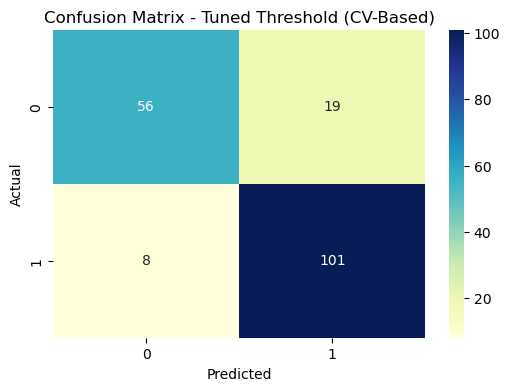

In [328]:

# ---------------- Model ----------------
lg_model = LogisticRegression(max_iter=1000, C=0.1,solver='lbfgs',penalty='l2' ,random_state=42)

categorical_features = ['cp', 'restecg', 'exang', 'slope']
numerical_features = ['trestbps', 'age', 'thalch', 'chol', 'oldpeak']

numeric_transformer = Pipeline([
    ('scaler', StandardScaler())
])

preprocessor = ColumnTransformer([
    ('num', numeric_transformer, numerical_features),
    ('cat', OneHotEncoder(handle_unknown='ignore', drop='first'), categorical_features)
], remainder='passthrough')

log_pipeline = Pipeline([
    ('pre', preprocessor),
    ('clf', lg_model)
])

# ---------------- Train ----------------
log_pipeline.fit(X_train_transformed, y_train)

# ---------------- Predict with tuned threshold ----------------
y_prob = log_pipeline.predict_proba(X_test_transformed)[:, 1]
y_pred = (y_prob >= log_final_threshold).astype(int)   # use tuned threshold

# ---------------- Metrics ----------------
cm_best = confusion_matrix(y_test, y_pred)
acc_best = accuracy_score(y_test, y_pred)

print(f"\nTest Accuracy (using tuned threshold): {acc_best:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# ---------------- Confusion Matrix Plot ----------------
plt.figure(figsize=(6, 4))
sns.heatmap(cm_best, annot=True, fmt='d', cmap='YlGnBu')
plt.title("Confusion Matrix - Tuned Threshold (CV-Based)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


# Random Forests


Random Forest Test Accuracy (using tuned threshold): 0.8478

Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.76      0.80        75
           1       0.85      0.91      0.88       109

    accuracy                           0.85       184
   macro avg       0.85      0.83      0.84       184
weighted avg       0.85      0.85      0.85       184



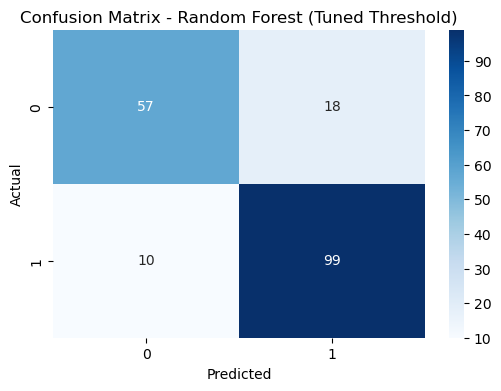

In [323]:
# ---------------- Model ----------------
rf_model = RandomForestClassifier( **rf_best_params , random_state = 42 , n_jobs = -1
)

rf_pipeline = Pipeline([
    ('pre', preprocessor),
    ('clf', rf_model)
])

# ---------------- Train ----------------
rf_pipeline.fit(X_train_transformed, y_train)

# ---------------- Predict with tuned threshold ----------------
y_prob = rf_pipeline.predict_proba(X_test_transformed)[:, 1]
y_pred = (y_prob >= rf_final_threshold).astype(int)   # use tuned threshold

# ---------------- Metrics ----------------
cm_rf = confusion_matrix(y_test, y_pred)
acc_rf = accuracy_score(y_test, y_pred)

print(f"\nRandom Forest Test Accuracy (using tuned threshold): {acc_rf:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# ---------------- Confusion Matrix Plot ----------------
plt.figure(figsize=(6, 4))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix - Random Forest (Tuned Threshold)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# XBBOOST


XGBoost Test Accuracy (using tuned threshold): 0.8370

Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.77      0.79        75
           1       0.85      0.88      0.86       109

    accuracy                           0.84       184
   macro avg       0.83      0.83      0.83       184
weighted avg       0.84      0.84      0.84       184



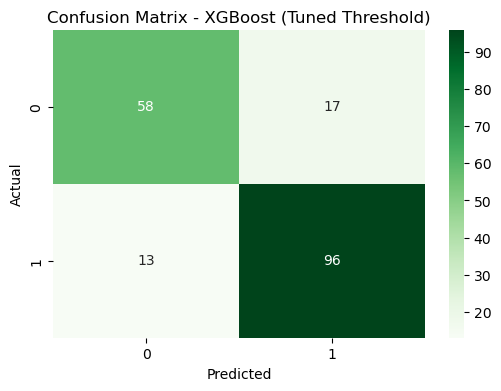

In [326]:
from xgboost import XGBClassifier

# ---------------- Model ----------------
xgb_model = XGBClassifier(
    **xgboost_best_params , random_state = 42
)

xgb_pipeline = Pipeline([
    ('pre', preprocessor),
    ('clf', xgb_model)
])

# ---------------- Train ----------------
xgb_pipeline.fit(X_train_transformed, y_train)

# ---------------- Predict with tuned threshold ----------------
y_prob = xgb_pipeline.predict_proba(X_test_transformed)[:, 1]
y_pred = (y_prob >= xgboost_final_threshold).astype(int)   # use tuned threshold

# ---------------- Metrics ----------------
cm_xgb = confusion_matrix(y_test, y_pred)
acc_xgb = accuracy_score(y_test, y_pred)

print(f"\nXGBoost Test Accuracy (using tuned threshold): {acc_xgb:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# ---------------- Confusion Matrix Plot ----------------
plt.figure(figsize=(6, 4))
sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Greens')
plt.title("Confusion Matrix - XGBoost (Tuned Threshold)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


# Voting Classifier

Ensemble Accuracy: 0.8533


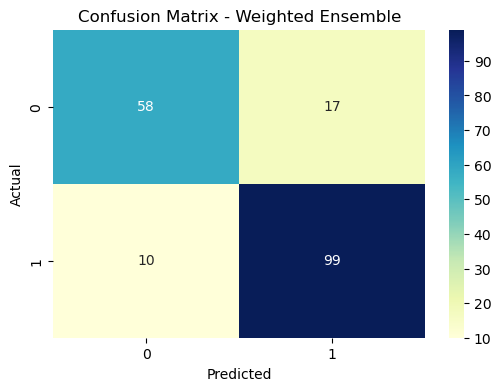

In [336]:
import numpy as np
from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.metrics import accuracy_score

class HardVotingWithThresholds(BaseEstimator, ClassifierMixin):
    def __init__(self, models, thresholds):
        """
        models: dict of models, e.g., {'log': log_pipeline, 'rf': rf_pipeline, ...}
        thresholds: dict of thresholds, e.g., {'log': 0.45, 'rf': 0.5, ...}
        """
        self.models = models
        self.thresholds = thresholds
    
    def fit(self, X, y):
        # Fit each model individually
        for name, model in self.models.items():
            model.fit(X, y)
        return self
    
    def predict(self, X):
        # Get predictions with tuned thresholds
        all_preds = []
        for name, model in self.models.items():
            probs = model.predict_proba(X)[:, 1]
            thresh = self.thresholds[name]
            preds = (probs >= thresh).astype(int)
            all_preds.append(preds)
        
        all_preds = np.vstack(all_preds)  # shape = (n_models, n_samples)
        final_preds = np.round(np.mean(all_preds, axis=0)).astype(int)  # majority vote
        return final_preds
        
# Define models and thresholds
models_dict = {
    'log': log_pipeline,
    'rf': rf_pipeline,
    'svm': svm_pipeline,
    'xgb': xgb_pipeline
}

thresholds_dict = {
    'log': log_final_threshold,
    'rf': rf_final_threshold,
    'svm': svm_final_threshold,
    'xgb': xgboost_final_threshold
}

# Create ensemble
ensemble_model = HardVotingWithThresholds(models=models_dict, thresholds=thresholds_dict)

# Fit on training data
ensemble_model.fit(X_train_transformed, y_train)

# Predict on test data
y_pred_ensemble = ensemble_model.predict(X_test_transformed)

# Metrics
acc_ensemble = accuracy_score(y_test, y_pred_ensemble)
print(f"Ensemble Accuracy: {acc_ensemble:.4f}")

cm = confusion_matrix(y_test, y_pred_ensemble)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='YlGnBu')
plt.title("Confusion Matrix - Weighted Ensemble")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

with open("ensemble_model.pkl", "wb") as f:
    pickle.dump(ensemble_model, f)



In [25]:
# Step 1: Define class

import numpy as np

class HardVotingClassifier(BaseEstimator, ClassifierMixin):
    def __init__(self, pipeline_dict):
        self.pipeline_dict = pipeline_dict
        self.fitted_pipelines = {}

    def fit(self, X, y):
        self.fitted_pipelines = {}
        for name, pipeline in self.pipeline_dict.items():
            self.fitted_pipelines[name] = pipeline.fit(X, y)
        return self

    def predict(self, X):
        model_preds = []
        for name, pipeline in self.fitted_pipelines.items():
            preds = pipeline.predict(X)
            model_preds.append(preds)

        y_pred, _ = mode(model_preds, axis=0)
        return y_pred.ravel()



# Step 2: Create, train, and save the model
voting_model = HardVotingClassifier(pipeline_dict)
voting_model.fit(X_train_transformed, y_train)
y_pred = voting_model.predict(X_test_transformed)
print("Hard Voting Accuracy:", accuracy_score(y_test, y_pred))


with open("voting_model.pkl", "wb") as f:
    pickle.dump(voting_model, f)


Hard Voting Accuracy: 0.8478260869565217


In [26]:
with open('df.pkl', 'wb') as file:
    pickle.dump(X, file)

In [27]:
with open('preprocessor.pkl', 'wb') as file:
    pickle.dump(full_pipeline, file)

In [28]:
import os
os.getcwd()


'C:\\Users\\saini'

In [29]:
X_train_transformed

,age,sex,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope
880,62.0,1.0,3.0,132.000000,170.0000,0.0,1.0,120.000000,1.0,3.000000,1.0
457,54.0,1.0,2.0,150.000000,224.4875,0.0,0.0,122.000000,0.0,0.000000,1.0
797,51.0,1.0,2.0,131.876812,339.0000,0.0,0.0,137.456023,0.0,0.881783,1.0
25,50.0,0.0,2.0,120.000000,219.0000,0.0,0.0,158.000000,0.0,1.600000,1.0
84,52.0,1.0,1.0,120.000000,325.0000,0.0,0.0,172.000000,0.0,0.200000,0.0
...,...,...,...,...,...,...,...,...,...,...,...
106,59.0,1.0,3.0,140.000000,177.0000,0.0,0.0,162.000000,1.0,0.000000,0.0
270,61.0,1.0,3.0,140.000000,207.0000,0.0,2.0,138.000000,1.0,1.900000,0.0
860,75.0,1.0,3.0,160.000000,310.0000,1.0,0.0,112.000000,1.0,2.000000,2.0
435,53.0,0.0,1.0,140.000000,216.0000,0.0,0.0,142.000000,1.0,2.000000,1.0


In [30]:
X_test_transformed

,age,sex,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope
319,36.0,1.0,1.0,120.0,166.000,0.0,0.0,180.0,0.0,0.0,1.0
377,45.0,1.0,1.0,140.0,224.000,1.0,0.0,122.0,0.0,0.0,1.0
538,48.0,1.0,3.0,160.0,329.000,0.0,0.0,92.0,1.0,1.5,1.0
296,59.0,1.0,3.0,164.0,176.000,1.0,2.0,90.0,0.0,1.0,1.0
531,40.0,0.0,3.0,150.0,392.000,0.0,0.0,130.0,0.0,2.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...
382,46.0,1.0,1.0,140.0,275.000,0.0,0.0,165.0,1.0,0.0,1.0
97,60.0,0.0,3.0,150.0,258.000,0.0,2.0,157.0,0.0,2.6,1.0
906,61.0,1.0,2.0,120.0,337.000,0.0,0.0,98.0,1.0,0.0,1.0
467,55.0,1.0,3.0,120.0,270.000,0.0,0.0,140.0,0.0,0.0,1.0


In [31]:
X_test

,age,sex,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope
319,36,Male,atypical angina,120.0,166.0,False,normal,180.0,False,0.0,NaN
377,45,Male,atypical angina,140.0,224.0,True,normal,122.0,False,0.0,NaN
538,48,Male,asymptomatic,160.0,329.0,False,normal,92.0,True,1.5,flat
296,59,Male,asymptomatic,164.0,176.0,True,lv hypertrophy,90.0,False,1.0,flat
531,40,Female,asymptomatic,150.0,392.0,False,normal,130.0,False,2.0,flat
...,...,...,...,...,...,...,...,...,...,...,...
382,46,Male,atypical angina,140.0,275.0,False,normal,165.0,True,0.0,NaN
97,60,Female,asymptomatic,150.0,258.0,False,lv hypertrophy,157.0,False,2.6,flat
906,61,Male,non-anginal,120.0,337.0,False,normal,98.0,True,0.0,NaN
467,55,Male,asymptomatic,120.0,270.0,False,normal,140.0,False,0.0,NaN


In [32]:
test_data = pd.DataFrame({
    'age': [58],
    'sex': ['male'],
    'cp': ['typical angina'],
    'trestbps': [130],
    'chol': [230],
    'fbs': [False],
    'restecg': ['normal'],
    'thalch': [150],
    'exang': [False],
    'oldpeak': [1.5],
    'slope': ['upsloping']
})


In [33]:
y_test 

319    0
377    0
538    1
296    1
531    1
      ..
382    0
97     1
906    1
467    0
732    1
Name: num, Length: 184, dtype: int64

In [34]:
test_data = full_pipeline.transform(test_data)

In [35]:
test_data = test_data[order]

In [36]:
test_data

,age,sex,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope
0,58.0,1.0,0.0,130.0,230.0,0.0,0.0,150.0,0.0,1.5,0.0


In [37]:
voting_model.predict(test_data) 

array([0], dtype=int64)